# Paper figures -- *Learning Gaia*

Every figure that appears in the draft, and nothing else. Figure 1 is hand-made
and is not reproduced here.

| Fig. | What | Section |
| --- | --- | --- |
| 2 | Sky positions colored by $\mu_b$: data vs the unconditional model | A |
| 3 | $\varpi$ over the sky, model-generated positions, four conditioning patterns | A |
| 4 | $\varpi$ over the sky, true positions supplied, four conditioning patterns | A |
| 5 | Marginal distributions of all nine parameters, data vs unconditional model | A |
| 6 | $\omega$ Cen: data \| model \| field triptych, colored by $\mu_b$ | B |
| 7 | $\omega$ Cen vs field vs model, marginal in $\mu_{\ell*}$ | B |
| 8 | Per-source imputed $v_r$ posteriors, `have` and `missing` | C |
| 9 | $v_r$ skill vs number of conditioning features | C |
| 10 | Corner plot, sources with and without a measured $v_r$ | C |
| 11 | TARP, unconditional | D |
| 12 | TARP, conditioned on $\ell, b$ | D |
| 13 | TARP, conditioned on everything but $v_r$ | D |
| 14 | TARP, the three drop-photometry patterns | D |
| 15 | Skill and RMSE vs conditioning, $\varpi$ | D |
| 16 | Skill and RMSE vs conditioning, $G_{BP}$ | D |
| 17 | Skill and RMSE vs conditioning, $\mu_b$ | D |

Four independent data sources feed these, and each section loads its own:

* **A** -- `Gen_Samples` all-sky sampling run + its `Pure_Sample` (Figs 2-5)
* **B** -- the same, plus the $\omega$ Cen sampling run and its aux file (Figs 6-7)
* **C** -- `imputation_samples/...` and its JSON manifest (Figs 8-10)
* **D** -- `tarp_rmse_results/*.h5` (Figs 11-17)

Sections are independent: run the config cell and the shared-conventions cell,
then whichever section you want.

### Symbol convention

Galactic longitude is $\ell$ everywhere, so the proper motion in longitude is
$\mu_{\ell*} \equiv \mu_\ell \cos b$. This differs from three of the source
notebooks, which wrote $\mu_{l*}$; `SYMBOL` below is now the single place that
decides, and every figure reads from it.

In [1]:
# =====================================================================
# Imports
# =====================================================================
import gc
import json
import re
from contextlib import contextmanager
from functools import wraps
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import h5py
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from scipy.stats import binned_statistic_2d

from gaia_feature_normalizer_020926 import feature_denormer

In [2]:
# =====================================================================
#                      C O N F I G U R A T I O N
#         The only cell that should need editing. Grouped by figure.
# =====================================================================

# ---------------------------------------------------------------------
# 0.  Paths shared by everything
# ---------------------------------------------------------------------
BASE_DIR   = Path('/Users/John/Desktop/Gaia Diffusion Model Work')
FIG_DIR    = BASE_DIR / 'paper_figs_w_classes'     # None -> display only, write nothing
FIG_DPI    = 400
FIG_FORMAT = 'png'                       # 'pdf' for the paper, 'png' to eyeball

# The trained model every figure refers to.
MODEL_NAME = ('POS_PM_mask_set_setA_CUSTOM_2026-07-10_15-01-16_mask_train_mask_val_'
              'MSE_vHD512_SIGMA1_0e-08_GELU_lr1_0e-04_wd0_0e+00_layers8_MP85_'
              'ADD_SET_VALACUMVAL_10')

# =====================================================================
# SECTION A  --  Figures 2, 3, 4, 5   (all-sky sampling run)
# =====================================================================
GEN_SAMPLE_DIR   = BASE_DIR / 'Gen_Samples'
PURE_SAMPLES_DIR = BASE_DIR / 'pure_samples'
PARAM_DICT_DIR   = BASE_DIR / 'model_param_dict'

STATS_FILE          = BASE_DIR / 'P_Z_Norm_Dict_Sample_Ests_062326.npy'
BOOL_STR_STATS_FILE = BASE_DIR / 'training_stats_bool_string_features.json'
PARAM_DICT_PATH     = PARAM_DICT_DIR / (MODEL_NAME + '_model_param_dict.npy')

# The all-sky run the paper's Figures 2-5 were drawn from.
ALLSKY_SAMPLE_NAME = 'Full_Sky_UNCOND_N1_COND_N1_TEST_FRACTION_1pct_'
ALLSKY_TIMESTAMP   = '2026-09-05_10-38'
ALLSKY_PURE_PATH   = (PURE_SAMPLES_DIR /
                      'Pure_Sample_9feat_771f68a4_val_fraction_1pct_10.pt')

SAMPLE_INDEX = 0          # which draw per source (the runs above have one)
SET_LABEL    = 'Model'    # the word printed over the model panel in Figure 2

# How the conditional-pattern list (the index j in *_cond_sam_{j}*.pt) is
# rebuilt. It MUST match the sampling script that wrote the files.
#   'sampling_script'  the MASK_SETS-aware construction used by
#                      CFM_Sampling_hdf5_070726_patched_v2.py
#   'simple'           drop-one and keep-one appended without the MASK_SETS
#                      branch (what OmegaCen_Field_Model_v2 used)
PERMUTATION_BUILDER = 'sampling_script'
DROP_ONE_SETS = True
KEEP_ONE_SETS = True
MASK_SETS_INDICES_ARE_MODEL_SPACE = True

# --- drawing ---------------------------------------------------------
MAX_POINTS    = 1000000    # seeded subsample, so every panel shows the same stars
PANEL_WIDTH   = 4.6
PANEL_HEIGHT  = 3.6
COLOR_SCALE_SCOPE = 'global'   # one vmin/vmax per feature, reused by every panel
COLOR_SCALE_MAX_N = 200000     # rows sampled when estimating those percentiles
SET_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9']

# Galactic longitude for PLOTTING only. True -> l is wrapped to (-180, 180] so
# the x axis runs -180 ... 0 ... 180 and the bulge sits in the middle of the
# frame; False -> the catalogue's own 0 ... 360, with the bulge split across
# both edges. Affects Figures 2, 3 and 4. Stored values are never modified.
WRAP_L_TO_CENTER_ZERO = True
# True also flips the x axis so l increases to the LEFT, the usual convention
# for an all-sky map looking outward from the Sun.
INVERT_L_AXIS = True
CBAR_WIDTH = 0.05        # colorbar column width, as a fraction of a panel

# --- Figure 2: unconditional sky map ---------------------------------
FIG2_COLOR    = 'pmb'          # the feature shown in color
FIG2_XLIM     = None           # None -> the window set by WRAP_L_TO_CENTER_ZERO
FIG2_YLIM     = (-90, 90)

# --- Figure 3: model-generated positions -----------------------------
# Columns after the Data panel, left to right. 'uncond' is the string; every
# other entry is a list of conditioning features resolved to a pattern index.
FIG3_COLOR    = 'parallax'
FIG3_PATTERNS = ['uncond',
                 ['G', 'BP', 'RP'],
                 ['pml', 'pmb'],
                 ['G', 'BP', 'RP', 'pml', 'pmb']]
FIG3_DIFF_SCALE = 'all'        # residual colorbar pooled over every panel drawn

# --- Figure 3b: Figure 3 with the residuals binned on the sky --------
FIG3B_BIN_DEG   = 1        # bin side length, degrees (same on both axes)
FIG3B_STAT      = 'median'   # per-bin statistic: 'median' or 'mean'
FIG3B_MIN_COUNT = 3          # bins with fewer sources are left blank

# --- Figure 4: true positions supplied -------------------------------
FIG4_COLOR    = 'parallax'
FIG4_PATTERNS = [['l', 'b'],
                 ['l', 'b', 'G', 'BP', 'RP'],
                 ['l', 'b', 'pml', 'pmb'],
                 'drop:parallax']       # 'drop:<feature>' = the drop-one pattern
FIG4_DIFF_SCALE = 'all'

# --- Figure 5: marginals ---------------------------------------------
FIG5_BINS  = 120
FIG5_NCOLS = 3
FIG5_LOGY  = True
FIG5_CLIP_PERCENTILES = (0.1, 99.9)

# =====================================================================
# SECTION B  --  Figures 6, 7   (omega Cen)
# =====================================================================
# The cluster sampling run. Note this is a DIFFERENT stem and timestamp from
# the all-sky run above.
CLUSTER_SAMPLE_NAME = 'Omega_Cen_UNCOND_N1_COND_N1_TEST_FRACTION_1pct_'
CLUSTER_TIMESTAMP   = '2026-08-10_14-54'
CLUSTER_PURE_PATH   = (PURE_SAMPLES_DIR / 'Pure_Sample_9feat_771f68a4_'
                       'Omega_Centauri_eDR3_data_010521__1__2026-07-08_06-18.pt')
CLUSTER_AUX_PATH    = (PURE_SAMPLES_DIR / 'Aux_Omega_Centauri_eDR3_data_010521'
                       '__1__9feat_771f68a4_2026-07-08_06-18.npy')

# The field in Figure 7 is cut out of an all-sky Pure_Sample. Only the TRUTH is
# used -- the field traces are data, never model output -- so this file does not
# have to match any sampling run and no sample name or timestamp is needed.
FIELD_PURE_PATH = ALLSKY_PURE_PATH

# --- omega Cen, Soltis et al. (2021) Sec. 2 --------------------------
#Note that I never actually use this information for plotting. I have removed the annulus plot
OC_L, OC_B    = 309.10, 14.97
OC_CONE_DEG   = 45.0 / 60.0     # Soltis extraction cone
OC_G_WINDOW   = (11.5, 19.5)    # Soltis magnitude window
FIELD_ANNULUS = (1.5, 5.0)      # clears the tidal tails
PM_BALL_MASYR = 1.5             # PM membership ball for field samples
MIN_TRACE_N   = 100             # a histogram of 8 stars is not a distribution

PANEL_W, PANEL_H = 5.0, 3.6
TICKS_MAJOR, TICKS_MINOR = 5, 5
USE_TRUTH_FOR_CONDITIONED_AXES = True

# --- Figure 6: cluster data vs model ---------------------------------
FIG6_PROJECTION = 'position'
FIG6_COLOR      = 'pmb'
FIG6_PATTERN    = ['l', 'b']      # the conditioning pattern of the model panel
# The color scale is LINEAR and spans both panels together, so the gap between
# the cluster's true proper motion and the model's is visible as a gap rather
# than normalised away. 'full' = min/max over data and model; a (lo, hi) tuple
# forces it; 'data' uses the cluster data alone.
FIG6_COLOR_LIMITS = (-10,10)
FIG6_MAX_POINTS   = 80000
FIG6_MARKER_S     = 1.2

# --- Figure 7: the pml marginal --------------------------------------
FIG7_FEATURE = 'pml'
FIG7_TRACES  = ['cluster', 'global']#, 'field_ang']   # data traces, then the
FIG7_BINS    = 70                                   # rubric's three model traces
FIG7_FIGSIZE = (9.5, 5.4)

# =====================================================================
# SECTION C  --  Figures 8, 9, 10   (imputation samples)
# =====================================================================
IMP_SAMPLE_DIR = BASE_DIR / 'imputation_samples' / 'POS_PM_setA_0710_RK50_test'
IMP_MANIFEST   = None     # None -> newest imputation_manifest_*.json in that dir

# All three figures are about radial velocity.
IMP_TARGET = 'radial_velocity'

# Rows with a non-finite draw are dropped (the sampler saves integrator output
# verbatim, so a few cells can be inf or NaN).
DROP_NONFINITE = True
HIST_COUNTS    = True     # histograms in raw counts, not density

# --- Figure 8: per-source posteriors ---------------------------------
# The paper shows the pattern that conditions on all eight other parameters.
FIG8_PATTERN     = 'drop:radial_velocity'
FIG8_N_EXAMPLES  = 6
FIG8_BINS        = 40
FIG8_SEED        = 0

# --- Figure 9: skill vs conditioning ---------------------------------
FIG9_METRIC     = 'skill_mean'   # point estimate = mean over draws (RMS-optimal)
FIG9_N_EXPECTED = None           # None -> n_per_subset from the manifest
FIG9_ANNOTATE   = True
FIG9_DECLUTTER  = True
FIG9_X_SPREAD   = 'even'         # 'even' | 'jitter' | 'none'
FIG9_FIGSIZE    = (8.6, 5.6)
FIG9_COLOR_FULL  = '#238A8D'
FIG9_COLOR_SHORT = '#D55E00'
FIG9_RNG_SEED    = 20260811
FIG9_N_BOOT = 1000       # bootstrap resamples; 0 turns the error bars off
FIG9_CI     = 68         # central interval, percent (68 ~ 1 sigma)

# l is circular; it is not a panel in the paper but the sweep machinery still
# needs the switch, and leaving it on keeps the numbers honest if you widen it.
CIRCULAR_FEATURES = {'l'}
WRAP_CIRCULAR = True

# --- Figure 10: have vs missing corner -------------------------------
# The least-conditioned pattern: its eligibility cut is the weakest, so the
# population it selects is the closest available to the split as a whole.
FIG10_PATTERN = 'unconditional'   # 'unconditional', or a list of features
FIG10_BINS    = 60
FIG10_SCALE   = 1.9               # inches per corner panel
FIG10_COLORS  = ['#0072B2', '#D55E00']    # have, missing

# --- Figure 10b: imputed v_r, have vs missing, all draws -----------
# The question Section 4.3 poses: how does the model's v_r for sources
# WITHOUT a Gaia measurement differ from its v_r for sources WITH one, and
# from those measurements? Every draw of every source is histogrammed, and
# the model counts are divided by n_draws so all three curves are on the
# same 'number of sources' scale.
FIG10B_PATTERN = 'drop:radial_velocity'
FIG10B_BINS    = 60
# One set of bin edges for all three curves: the union of each sample's own
# (lo, hi) percentile range, so neither the data's tails nor the missing
# draws' tails are cut by the other sample's range.
FIG10B_CLIP_PERCENTILES = (0.1, 99.9)
FIG10B_FIGSIZE = (6.4, 4.4)
FIG10B_LW      = 1.6
FIG10B_COLORS  = {'data': '0.75', 'have': '#0072B2', 'missing': '#D55E00'}
FIG10B_LABELS  = {'data':    r'"have" data $v_r$',
                  'have':    r'"have" model $v_r$',
                  'missing': r'"missing" model $v_r$'}
FIG10B_XLABEL  = r'$v_r$'
FIG10B_YLABEL  = 'Number of Sources'

# =====================================================================
# SECTION D  --  Figures 11, 12, 13, 14, 15, 16, 17   (TARP and RMSE)
# =====================================================================
RESULT_DIR     = '/Users/John/Documents/Gaia_CFM_Code/tarp_rmse_results'
TARP_TIMESTAMP = None      # pin a run, e.g. '2026-09-12_10-58'; None -> newest
TARP_RUN_TAG   = 'RMSE_ON_CLASSES'      # e.g. 'RMSE_ON_CLASSES'; None -> any run tag. Set
                           # it when old and new runs share RESULT_DIR, so
                           # the three datasets come from the same run.

DATASETS = ['test', 'omega_cen_all', 'omega_cen_not_A']
DS_LABEL = {'test': 'Test Set',
            'omega_cen_all': r'$\omega$ Cen, All Members',
            'omega_cen_not_A': r'$\omega$ Cen, Outside Train/Val'}
DS_COLOR = {'test': '#238A8D',
            'omega_cen_all': '#D55E00',
            'omega_cen_not_A': '#7B3294'}

# Measurement classes, in plot order. Color-blind-safe, dark to light.
CLASS_COLOR = {'a_pos_G': '#332288',
               'b_pos_G_BP_RP': '#117733',
               'c_pos_phot_astro': '#CC6677',
               'd_all_with_RV': '#DDCC77'}

# Section D is the only part of the paper drawn on a grid, so its rcParams are
# applied with a context manager rather than globally -- Figures 2-10 have no
# grid and a framed legend.
TARP_RC = {'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
           'grid.alpha': 0.25, 'axes.axisbelow': True, 'legend.frameon': False}

# --- Figures 11, 12, 13: one TARP figure each -------------------------
FIG11_PATTERN = 'unconditional'
FIG12_PATTERN = 'sky_position_only'
FIG13_PATTERN = 'drop_radial_velocity'
TARP_FIGSIZE  = (13.5, 7.2)
SHOW_BAND     = True       # +-3 sigma binomial band on the deviation row
BAND_ALPHA    = 0.1
BAND_N        = None       # n the band is drawn for. None -> each panel's
                           # own n (the smallest n among the curves drawn
                           # there, i.e. the widest band). omega Cen class
                           # pools can hold fewer than 1000 sources.

# --- Figure 14: three drop-photometry patterns side by side -----------
FIG14_PATTERNS   = ['drop_phot_g_mean_mag',
                    'drop_phot_bp_mean_mag',
                    'drop_phot_rp_mean_mag']
FIG14_DATASET    = 'test'
FIG14_FIGSIZE    = (13.5, 7.2)
FIG14_SHARE_DEV  = True

# --- Figures 15, 16, 17: skill and RMSE vs conditioning ---------------
FIG15_FEATURE = 'parallax'
FIG16_FEATURE = 'phot_bp_mean_mag'
FIG17_FEATURE = 'pmb'
# Which measurement-class pool the RMSE comes from: the same sources and
# draws as that class's TARP curve, as in the appendix skill tables.
# Class (d) is the only class every one of the 47 patterns applies to
# (including the v_r-conditioned ones), and one of the two classes the
# omega Cen datasets have, so it keeps one point per pattern per dataset.
# 'c_pos_phot_astro' gives the 29 patterns that do not condition on v_r.
# None -> the older pattern-pool RMSE (rmse_table), for pre-update runs.
RMSE_CLASSES  = ['a_pos_G', 'b_pos_G_BP_RP', 'c_pos_phot_astro', 'd_all_with_RV']
RMSE_LABEL_CLASS = 'd_all_with_RV'   # pattern labels go on this class's points
DS_MARKER     = {'test': 'o', 'omega_cen_all': 'o', 'omega_cen_not_A': '^'}
RMSE_FIGSIZE     = (16.0, 8.6)
ANNOTATE         = True
ANNOTATE_COLUMNS = ('skill', 'rmse', 'baseline')
MAX_LABELS       = 12      # the same patterns are labelled in all three columns
LABEL_BY         = 'skill'
DECLUTTER_LABELS = True
X_SPREAD         = 'even'
DS_OFFSET        = 0.12    # x offset between the two omega Cen datasets
LOG_RMSE         = False
RMSE_RNG_SEED    = 20260912


# =====================================================================
# FONT SIZES  --  Figures 3, 4, 8, 10, 11, 12, 13, 14, 15, 16, 17
# =====================================================================
# One table per figure, and every figure is independent of every other.
# Within a table every knob is independent too, so the legend can grow
# without the axis labels moving.
#
#   axis_label      x and y axis labels
#   tick_label      the numbers along the axes
#   panel_title     per-axes title (ax.set_title)
#   suptitle        figure-level title (mostly off -- see SHOW_SUPTITLES)
#   legend          legend entries
#   annotation      text attached to data points (the pattern labels in 15-17)
#   note            in-axes explanatory text where a panel has no curves
#   colorbar_label  the colorbar's own label
#   colorbar_tick   the numbers along the colorbar
#
# A number is a size in points. None means "inherit", which is exactly what
# the notebook did before this table existed: matplotlib's own defaults in
# Figures 3 and 4, TARP_RC's font.size = 9 in Section D. The values below
# are the sizes those figures were already drawn at, so leaving this table
# alone changes nothing. Figures 2, 5, 6, 7 and 9 do not read it.
#
# A knob that does not apply to a figure (a legend size for a figure with no
# legend) is harmless; it is listed so every table has the same shape.
FONT_SIZES = {
    # -- Section A: the sky grids. Everything was inherited. -----------
    'fig3':  dict(axis_label=11, tick_label=11, panel_title=11,
                  suptitle=11, legend=11, annotation=11, note=11,
                  colorbar_label=None, colorbar_tick=None),
    'fig4':  dict(axis_label=11, tick_label=11, panel_title=11,
                  suptitle=11, legend=11, annotation=11, note=11,
                  colorbar_label=11, colorbar_tick=11),

    # -- Section C: per-source posteriors, and the corner plot ---------
    'fig8':  dict(axis_label=10, tick_label=8, panel_title=10,
                  suptitle=None, legend=None, annotation=None, note=None,
                  colorbar_label=None, colorbar_tick=None),
    'fig10': dict(axis_label=10, tick_label=8, panel_title=None,
                  suptitle=None, legend=8.5, annotation=None, note=None,
                  colorbar_label=None, colorbar_tick=None),
    'fig10b': dict(axis_label=None, tick_label=None, panel_title=None,
                   suptitle=None, legend=None, annotation=None, note=None,
                   colorbar_label=None, colorbar_tick=None),

    # -- Section D: TARP. 11, 12 and 13 are the same figure three times,
    #    so they start equal; they do not have to stay that way. -------
    'fig11': dict(axis_label=None, tick_label=None, panel_title=11.5,
                  suptitle=14, legend=10.5, annotation=None, note=10,
                  colorbar_label=None, colorbar_tick=None),
    'fig12': dict(axis_label=None, tick_label=None, panel_title=11.5,
                  suptitle=14, legend=10.5, annotation=None, note=10,
                  colorbar_label=None, colorbar_tick=None),
    'fig13': dict(axis_label=None, tick_label=None, panel_title=11.5,
                  suptitle=14, legend=10.5, annotation=None, note=10,
                  colorbar_label=None, colorbar_tick=None),
    # Figure 14's titles carry a pattern as well as a name, hence 10 not 9.5,
    # and its suptitle is commented out in plot_tarp_compare.
    'fig14': dict(axis_label=None, tick_label=None, panel_title=12,
                  suptitle=None, legend=10.5, annotation=None, note=10,
                  colorbar_label=None, colorbar_tick=None),

    # -- Section D: RMSE. 'annotation' is the per-point pattern label; the
    #    label placer reserves room for a box that scales with it, and any
    #    label it cannot fit is dropped, so raising this drops more of them
    #    (MAX_LABELS decides how many are attempted in the first place). --
    'fig15': dict(axis_label=11, tick_label=None, panel_title=None,
                  suptitle=14.5, legend=9.5, annotation=8, note=11,
                  colorbar_label=None, colorbar_tick=None),
    'fig16': dict(axis_label=11, tick_label=None, panel_title=None,
                  suptitle=14.5, legend=9.5, annotation=8, note=11,
                  colorbar_label=None, colorbar_tick=None),
    'fig17': dict(axis_label=11, tick_label=None, panel_title=None,
                  suptitle=14.5, legend=9.5, annotation=8, note=11,
                  colorbar_label=None, colorbar_tick=None),
}


## Shared conventions

One symbol table, one unit table, one file-name table, used by every figure in
every section. Changing `SYMBOL['pml']` here changes it in Figures 6, 7, 8, 9,
10, 15, 16 and 17 at once.

`SYMBOL` holds the *body* of each symbol with no `$` delimiters, so a list of
features can be joined into one math expression -- `$\ell,\,b,\,\varpi$` rather
than three separate groups, which matplotlib spaces badly.

In [3]:
# =====================================================================
# Symbols, units, file names -- edit here for anything cosmetic
# =====================================================================
# Galactic longitude is \ell, so its proper motion is \mu_{\ell*}.
SYMBOL = {
    'l':                r'\ell',
    'b':                r'b',
    'parallax':         r'\varpi',
    'pml':              r'\mu_{\ell*}',      # = mu_l cos(b)
    'pmb':              r'\mu_b',
    'phot_g_mean_mag':  r'G',
    'phot_bp_mean_mag': r'G_{BP}',
    'phot_rp_mean_mag': r'G_{RP}',
    'radial_velocity':  r'v_r',
    'cos_l':            r'\cos\ell',
    'sin_l':            r'\sin\ell',
}

# Units as LaTeX, for axis and colorbar labels.
TEX_UNITS = {
    'l': 'deg', 'b': 'deg', 'parallax': 'mas',
    'pml': 'mas yr$^{-1}$', 'pmb': 'mas yr$^{-1}$',
    'phot_g_mean_mag': 'mag', 'phot_bp_mean_mag': 'mag',
    'phot_rp_mean_mag': 'mag', 'radial_velocity': 'km s$^{-1}$',
}

# Units as plain text, for printed tables and the RMSE panel labels.
PLAIN_UNITS = {
    'l': 'deg', 'b': 'deg', 'parallax': 'mas', 'pml': 'mas/yr', 'pmb': 'mas/yr',
    'phot_g_mean_mag': 'mag', 'phot_bp_mean_mag': 'mag',
    'phot_rp_mean_mag': 'mag', 'radial_velocity': 'km/s',
    'cos_l': '', 'sin_l': '',
}

# Short plain-text names, for stdout and legends that must stay ASCII.
SHORT = {'l': 'l', 'b': 'b', 'parallax': 'plx', 'pml': 'pml', 'pmb': 'pmb',
         'phot_g_mean_mag': 'G', 'phot_bp_mean_mag': 'BP',
         'phot_rp_mean_mag': 'RP', 'radial_velocity': 'RV',
         'cos_l': 'cos_l', 'sin_l': 'sin_l'}

# File-name fragments. Short and file-system safe.
FILE_TAG = {'l': 'l', 'b': 'b', 'parallax': 'plx', 'pml': 'pml', 'pmb': 'pmb',
            'phot_g_mean_mag': 'G', 'phot_bp_mean_mag': 'BP',
            'phot_rp_mean_mag': 'RP', 'radial_velocity': 'RV',
            'cos_l': 'cosl', 'sin_l': 'sinl'}

# Shorthands accepted wherever a feature is named in the config cell.
ALIASES = {'G': 'phot_g_mean_mag', 'BP': 'phot_bp_mean_mag',
           'RP': 'phot_rp_mean_mag', 'plx': 'parallax', 'pi': 'parallax',
           'rv': 'radial_velocity', 'vr': 'radial_velocity',
           'mul': 'pml', 'mub': 'pmb'}

SHOW_SUPTITLES    = False   # figure-level titles off; LaTeX supplies captions
SHOW_PANEL_TITLES = True    # per-panel titles ('Data (n = ...)', 'Model') on


def canon(f):
    """'G' -> 'phot_g_mean_mag'. Idempotent."""
    return ALIASES.get(f, f)


def sym(f):
    """Symbol body for one feature, e.g. '\\varpi'. No $ delimiters."""
    return SYMBOL.get(f, f.replace('_', r'\_'))


def math(features):
    """A list of features as ONE math expression: '$\\ell,\\,b,\\,\\varpi$'."""
    if isinstance(features, str):
        features = [features]
    return '$' + r',\,'.join(sym(f) for f in features) + '$'


def short(f):
    return SHORT.get(f, f)


def unit(f):
    """Plain-text unit, for printed tables and the RMSE panel labels."""
    return PLAIN_UNITS.get(f, '')


def file_tag(f):
    return FILE_TAG.get(f, f)


def tex(f, unit=True, with_unit=None):
    """'$\\mu_b$ [mas yr$^{-1}$]'.  Both keyword spellings are accepted,
    because the source notebooks disagreed about which one to use."""
    want_unit = unit if with_unit is None else with_unit
    s = f'${sym(f)}$'
    u = TEX_UNITS.get(f)
    return f'{s} [{u}]' if (want_unit and u) else s


def tex_delta(f, unit=True, with_unit=None):
    """'$\\Delta \\mu_b$ [mas yr$^{-1}$]' -- a model-minus-truth axis."""
    want_unit = unit if with_unit is None else with_unit
    out = rf'$\Delta {sym(f)}$'
    u = TEX_UNITS.get(f)
    return f'{out} [{u}]' if (want_unit and u) else out


def _suptitle(fig, text, **kw):
    """Honour SHOW_SUPTITLES from one place."""
    if SHOW_SUPTITLES:
        fig.suptitle(text, **kw)


def save_fig(fig, name, dpi=None, close=False):
    """Every figure in this notebook is written as FIG_DIR/<name>.<FIG_FORMAT>,
    where <name> starts with the figure number it carries in the draft."""
    if FIG_DIR is not None:
        Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
        path = Path(FIG_DIR) / f'{name}.{FIG_FORMAT}'
        fig.savefig(path, dpi=dpi or FIG_DPI, bbox_inches='tight')
        print(f'  wrote {path}')
    if close:
        plt.close(fig)
    else:
        plt.show()


def tune_ticks(ax, nx=None, ny=None, minor=None):
    """Few labelled major ticks, unlabelled minor ticks between them, and no
    offset text -- the omega Cen position panels span well under a degree and
    the default locator prints '308.50 309.00 309.25 ...' into a 5-inch axis."""
    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=nx or TICKS_MAJOR, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=ny or TICKS_MAJOR, steps=[1, 2, 2.5, 5, 10]))
    ax.xaxis.set_minor_locator(AutoMinorLocator(minor or TICKS_MINOR))
    ax.yaxis.set_minor_locator(AutoMinorLocator(minor or TICKS_MINOR))
    ax.ticklabel_format(useOffset=False, style='plain', axis='both')
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=5)
    ax.tick_params(which='minor', length=2.5)


print('symbols in use:')
for _f, _s in SYMBOL.items():
    print(f'  {_f:<20s} ${_s}$')

symbols in use:
  l                    $\ell$
  b                    $b$
  parallax             $\varpi$
  pml                  $\mu_{\ell*}$
  pmb                  $\mu_b$
  phot_g_mean_mag      $G$
  phot_bp_mean_mag     $G_{BP}$
  phot_rp_mean_mag     $G_{RP}$
  radial_velocity      $v_r$
  cos_l                $\cos\ell$
  sin_l                $\sin\ell$


### Font sizes

`FONT_SIZES` in the configuration cell holds one table per figure. This cell
turns a table into something the drawing code can read: `font_context('fig11')`
makes Figure 11's sizes active, and the `@with_fonts` decorator opens that
context around a figure function, adding a `fonts=` keyword so one engine can
draw several figures at different sizes.

Two ways a size reaches a piece of text:

* **`rcParams`** for anything drawn without an explicit size -- axis labels,
  tick labels, panel titles, the figure title, legends. Set inside the context
  and restored on the way out.
* **`fkw('panel_title')`** for calls that pass a size explicitly, since an
  explicit `fontsize=` beats `rcParams`.

`fkw` returns `{}` when a knob is `None`, which matters more than it looks:
`ax.set_title(t, fontsize=None)` is *not* the same as `ax.set_title(t)`.
Matplotlib reads `None` as `font.size` (10 pt) rather than as `axes.titlesize`
(`'large'`, 12 pt), so passing `None` through would quietly shrink every title
the moment this machinery was added. Omitting the keyword leaves the call
identical to what it was.


In [4]:
# =====================================================================
# Font-size machinery -- reads FONT_SIZES from the configuration cell
# =====================================================================
# Figures 2, 5, 6, 7 and 9 never enter a font context, so fs() and fkw()
# return "unset" for them and every call they make is unchanged.

FONT_KEYS = ('axis_label', 'tick_label', 'panel_title', 'suptitle',
             'legend', 'annotation', 'note',
             'colorbar_label', 'colorbar_tick')

# The knobs that a component picks up on its own, via rcParams, when it is
# drawn without an explicit fontsize=.
_FONT_RC = {'axis_label':  ('axes.labelsize',),
            'tick_label':  ('xtick.labelsize', 'ytick.labelsize'),
            'panel_title': ('axes.titlesize',),
            'suptitle':    ('figure.titlesize',),
            'legend':      ('legend.fontsize',)}

_FONT_UNSET = {k: None for k in FONT_KEYS}
_ACTIVE_FONTS = dict(_FONT_UNSET)      # everything unset outside a context


def font_table(fig_key):
    """The complete, validated table for one figure key. A typo in a knob
    name raises here rather than being silently ignored at draw time."""
    if fig_key is None:
        return dict(_FONT_UNSET)
    if fig_key not in FONT_SIZES:
        raise KeyError(f'{fig_key!r} is not in FONT_SIZES; '
                       f'known: {list(FONT_SIZES)}')
    unknown = sorted(set(FONT_SIZES[fig_key]) - set(FONT_KEYS))
    if unknown:
        raise KeyError(f'FONT_SIZES[{fig_key!r}]: unknown knob(s) {unknown}; '
                       f'known: {list(FONT_KEYS)}')
    return {**_FONT_UNSET, **FONT_SIZES[fig_key]}


@contextmanager
def font_context(fig_key):
    """Make one figure's sizes active, both as rcParams and to fs()/fkw()."""
    global _ACTIVE_FONTS
    table = font_table(fig_key)
    rc = {param: table[knob]
          for knob, params in _FONT_RC.items() if table[knob] is not None
          for param in params}
    previous = _ACTIVE_FONTS
    _ACTIVE_FONTS = table
    try:
        with plt.rc_context(rc):     # nests inside TARP_RC in Section D
            yield table
    finally:
        _ACTIVE_FONTS = previous


def with_fonts(default_key):
    """Draw inside font_context(fonts or default_key), and add the `fonts=`
    keyword that lets one engine serve several figures -- plot_tarp_pattern
    is Figures 11, 12 and 13, and each passes its own key."""
    def decorate(fn):
        @wraps(fn)
        def wrapper(*args, fonts=None, **kwargs):
            with font_context(default_key if fonts is None else fonts):
                return fn(*args, **kwargs)
        return wrapper
    return decorate


def fs(knob):
    """The active size for one component, or None when it is unset."""
    if knob not in FONT_KEYS:
        raise KeyError(f'unknown font knob {knob!r}; known: {list(FONT_KEYS)}')
    return _ACTIVE_FONTS[knob]


def fkw(knob):
    """{'fontsize': size} to splat into a drawing call, or {} when the knob
    is unset -- see the markdown above for why None is not passed through."""
    size = fs(knob)
    return {} if size is None else {'fontsize': size}


def tick_fontsize(ax, knob='tick_label'):
    """Tick-label size on one axes (or on a colorbar's axes), leaving the
    rcParams value alone when the knob is unset."""
    size = fs(knob)
    if size is not None:
        ax.tick_params(which='both', labelsize=size)


print('font knobs:', ', '.join(FONT_KEYS))
for _key in FONT_SIZES:
    _set = {k: v for k, v in font_table(_key).items() if v is not None}
    print(f'  {_key:<6s} {_set if _set else "all inherited"}')


font knobs: axis_label, tick_label, panel_title, suptitle, legend, annotation, note, colorbar_label, colorbar_tick
  fig3   {'axis_label': 11, 'tick_label': 11, 'panel_title': 11, 'suptitle': 11, 'legend': 11, 'annotation': 11, 'note': 11}
  fig4   {'axis_label': 11, 'tick_label': 11, 'panel_title': 11, 'suptitle': 11, 'legend': 11, 'annotation': 11, 'note': 11, 'colorbar_label': 11, 'colorbar_tick': 11}
  fig8   {'axis_label': 10, 'tick_label': 8, 'panel_title': 10}
  fig10  {'axis_label': 10, 'tick_label': 8, 'legend': 8.5}
  fig10b all inherited
  fig11  {'panel_title': 11.5, 'suptitle': 14, 'legend': 10.5, 'note': 10}
  fig12  {'panel_title': 11.5, 'suptitle': 14, 'legend': 10.5, 'note': 10}
  fig13  {'panel_title': 11.5, 'suptitle': 14, 'legend': 10.5, 'note': 10}
  fig14  {'panel_title': 12, 'legend': 10.5, 'note': 10}
  fig15  {'axis_label': 11, 'suptitle': 14.5, 'legend': 9.5, 'annotation': 8, 'note': 11}
  fig16  {'axis_label': 11, 'suptitle': 14.5, 'legend': 9.5, 'annotation'

---

# Section A -- the all-sky sampling run

Figures 2, 3, 4 and 5. All four read one `Pure_Sample` (the truth, in physical
units, with a per-feature validity mask) and one sampling run against it: an
unconditional file plus one file per conditioning pattern.

In [5]:
# =====================================================================
# A1. Model metadata, normalization tables, denormalizer
# =====================================================================
MODEL_PARAM_DICT = np.load(PARAM_DICT_PATH, allow_pickle=True).item()

preprocess = np.load(STATS_FILE, allow_pickle=True).item()
with open(BOOL_STR_STATS_FILE) as _fh:
    str_bool_preprocess = json.load(_fh)

# Which block of the normalization tables this model was trained against.
_SET_KEYS = {'M': 'main_train', 'A': 'subsetA_train', 'B': 'subsetB_train'}
if 'SET_TYPE' in MODEL_PARAM_DICT:
    dict_key_set = _SET_KEYS[MODEL_PARAM_DICT['SET_TYPE']]
else:
    dict_key_set = MODEL_PARAM_DICT.get('DICT_KEY_SET', 'subsetA_train')

feature_dict = {}
for _name in MODEL_PARAM_DICT['feature_names']:
    if _name in preprocess.get(dict_key_set, {}):
        feature_dict[_name] = preprocess[dict_key_set][_name]
    elif _name in str_bool_preprocess.get(dict_key_set, {}):
        feature_dict[_name] = str_bool_preprocess[dict_key_set][_name]
    else:
        raise KeyError(f"{_name} missing from stats set '{dict_key_set}'")

feature_names = list(feature_dict.keys())
assert len(feature_names) == len(MODEL_PARAM_DICT['feature_names']), (
    'Normalization tables are missing features; refusing to continue.')

dim_phys = len(feature_names)
F = {name: c for c, name in enumerate(feature_names)}   # physical index lookup
L_CUSTOM = (feature_names[0] == 'l'
            and 'CUSTOM' in str(MODEL_PARAM_DICT['NORM_METHOD']).upper())
dim = dim_phys + (1 if L_CUSTOM else 0)

assert MODEL_PARAM_DICT['NORM_METHOD'] == 'CUSTOM', (
    'This notebook implements the CUSTOM denormalization path only.')

print(f'stats block : {dict_key_set}')
print(f'features    : {feature_names}')
print(f'dim_phys    : {dim_phys}, L_CUSTOM = {L_CUSTOM}, model dim = {dim}')


def denormalize_model_space(samples):
    """(N, dim) model space -> (N, dim_phys) physical units."""
    samples = np.asarray(samples)
    assert samples.shape[1] == dim, (
        f'expected (N, dim={dim}) model-space input, got {samples.shape}')
    out = np.empty((samples.shape[0], dim_phys))
    for c in range(dim_phys):
        if c == 0 and L_CUSTOM:
            out[:, c] = feature_denormer((samples[:, 0], samples[:, 1]),
                                         feature_names[0], feature_dict)
        elif L_CUSTOM:
            out[:, c] = feature_denormer(samples[:, c + 1], feature_names[c],
                                         feature_dict)
        else:
            out[:, c] = feature_denormer(samples[:, c], feature_names[c],
                                         feature_dict)
    return out


def load_sample_file(path):
    x = torch.load(path, map_location='cpu')
    return x.numpy() if torch.is_tensor(x) else np.asarray(x)

stats block : subsetA_train
features    : ['l', 'b', 'parallax', 'pml', 'pmb', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity']
dim_phys    : 9, L_CUSTOM = True, model dim = 10


In [6]:
# =====================================================================
# A2. The conditional-pattern list
# =====================================================================
# This list defines the index j in the *_cond_sam_{j}{timestamp}.pt file names,
# so it must be rebuilt exactly as the sampling script built it. Look patterns
# up by WHAT THEY CONDITION ON, never by a bare integer: a hard-coded index
# breaks silently if the flags or the feature list ever change.
BESPOKE_PERMUTATIONS = [
    ['l', 'b'],
    ['pml', 'pmb'],
    ['l', 'b', 'parallax'],
    ['l', 'b', 'parallax', 'pml', 'pmb'],
    ['phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['l', 'b', 'phot_g_mean_mag'],
    ['l', 'b', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['l', 'b', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['parallax', 'phot_g_mean_mag'],
    ['parallax', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['parallax', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['l', 'b', 'parallax', 'phot_g_mean_mag'],
    ['l', 'b', 'parallax', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['l', 'b', 'parallax', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    ['pml', 'pmb', 'radial_velocity'],
    ['l', 'b', 'pml', 'pmb', 'radial_velocity'],
    ['l', 'b', 'pml', 'pmb'],
    ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'pml', 'pmb'],
    ['parallax', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'pml', 'pmb'],
    ['parallax', 'pml', 'pmb'],
    ['l', 'b', 'parallax', 'pml', 'pmb'],
    ['l', 'b', 'parallax', 'pml', 'pmb', 'radial_velocity'],
    ['l', 'b', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'pml', 'pmb'],
    ['l', 'b', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'pml', 'pmb', 'radial_velocity'],
]


def _mask_sets_to_phys(mask_sets_indices):
    phys_sets = []
    for set_j in mask_sets_indices:
        s = set()
        for idx in set_j:
            if MASK_SETS_INDICES_ARE_MODEL_SPACE and L_CUSTOM:
                s.add(0 if idx <= 1 else idx - 1)
            else:
                s.add(idx)
        phys_sets.append(tuple(sorted(s)))
    return phys_sets


def build_feature_permutations():
    perms = []
    for perm in BESPOKE_PERMUTATIONS:
        missing = [f for f in perm if f not in feature_names]
        if missing:
            print(f'WARNING: dropping {perm}: {missing} not in the feature set.')
        else:
            perms.append(list(perm))

    use_mask_sets = (PERMUTATION_BUILDER == 'sampling_script'
                     and MODEL_PARAM_DICT.get('MASK_SETS') is True)
    if PERMUTATION_BUILDER == 'sampling_script' and not use_mask_sets:
        print("note: MASK_SETS is not set on this model, so 'sampling_script' "
              "and 'simple' produce the same list.")
    if use_mask_sets:
        print('note: MASK_SETS is ON. The drop-one block groups masked features '
              'together, so pattern indices differ from the simple construction. '
              'If a figure comes out conditioned on the wrong thing, try '
              "PERMUTATION_BUILDER = 'simple'.")

    if DROP_ONE_SETS:
        feature_index = np.arange(len(feature_names), dtype=int)
        phys_mask_sets = (_mask_sets_to_phys(MODEL_PARAM_DICT['MASK_SETS_INDICES'])
                          if use_mask_sets else [])
        for i in range(len(feature_names)):
            if use_mask_sets:
                caught = False
                for set_j in phys_mask_sets:
                    if i in set_j:
                        caught = True
                    if set_j[0] == i:
                        sub = np.setdiff1d(feature_index, np.array(set_j))
                        perms.append(list(np.array(feature_names)[sub]))
                if not caught:
                    sub = np.setdiff1d(feature_index, np.array([i]))
                    perms.append(list(np.array(feature_names)[sub]))
            else:
                sub = np.setdiff1d(feature_index, np.array([i]))
                perms.append(list(np.array(feature_names)[sub]))
    if KEEP_ONE_SETS:
        for name in feature_names:
            perms.append([name])
    return perms


feature_permutation_names = build_feature_permutations()


_DUPLICATE_WARNED = set()


def pattern_index(*features, verbose=True):
    """Index of the pattern conditioned on exactly these features, order-free.

    Accepts pattern_index('l', 'b') or pattern_index(['l', 'b']), and the
    shorthands in ALIASES ('G', 'BP', 'plx', ...). Raises rather than returning
    None, so a typo fails loudly instead of silently drawing the wrong panel.

    BESPOKE_PERMUTATIONS overlaps the drop-one block in one place, so two
    indices can name the same conditioning set. They are the same pattern but
    DIFFERENT FILES -- two independent sampling runs of it -- so the choice
    changes the draws, not the meaning. The first is taken, which is what the
    source notebooks did; the alternatives are named once so the other file can
    be used deliberately if you want it.
    """
    if len(features) == 1 and isinstance(features[0], (list, tuple, set)):
        features = tuple(features[0])
    want = {canon(f) for f in features}
    hits = [j for j, p in enumerate(feature_permutation_names) if set(p) == want]
    if not hits:
        raise KeyError(
            f'no pattern conditions on exactly {sorted(want)}.\n'
            f'available: {[sorted(p) for p in feature_permutation_names]}')
    key = frozenset(want)
    if len(hits) > 1 and verbose and key not in _DUPLICATE_WARNED:
        _DUPLICATE_WARNED.add(key)
        print(f'  note: patterns {hits} all condition on '
              f'{[short(f) for f in sorted(want)]} (separate sampling runs of '
              f'the same pattern); using {hits[0]}.')
    return hits[0]


def drop_one_index(feature):
    """Index of the drop-one pattern that withholds `feature`."""
    f = canon(feature)
    return pattern_index([g for g in feature_names if g != f])


drop_pattern = drop_one_index          # the omega Cen notebook's spelling


def resolve_pattern_spec(spec):
    """Turn a config entry into a pattern index or the string 'uncond'.

    Accepted:  'uncond'  |  'drop:<feature>'  |  ['l', 'b', ...]  |  an int
    """
    if spec == 'uncond':
        return 'uncond'
    if isinstance(spec, str) and spec.startswith('drop:'):
        return drop_one_index(spec.split(':', 1)[1])
    if isinstance(spec, (int, np.integer)):
        return int(spec)
    return pattern_index(spec)


def pattern_panel_label(j):
    """'unconditional', 'drop $\\varpi$', '$\\ell$, $b$, $G$' -- panel titles."""
    if j == 'uncond':
        return 'Unconditional'
    p = feature_permutation_names[j]
    if len(p) == dim_phys - 1:
        return 'drop ' + tex((set(feature_names) - set(p)).pop(), unit=False)
    return ', '.join(tex(f, unit=False) for f in p)


def pattern_label_tex(j):
    """Same thing under the name the omega Cen code uses."""
    return pattern_panel_label(j)


def pattern_label(j):
    """Plain-text form, for stdout and file names."""
    if j == 'uncond':
        return 'Unconditional'
    p = feature_permutation_names[j]
    if len(p) == dim_phys - 1:
        return f'drop {short((set(feature_names) - set(p)).pop())}'
    return ', '.join(short(f) for f in p)


def cond_file_tag(j):
    """File-name fragment naming a pattern's conditioning variables."""
    if j is None or j == 'uncond':
        return 'unconditional'
    return 'cond_' + '_'.join(file_tag(f) for f in feature_permutation_names[j])


print(f'{len(feature_permutation_names)} conditional patterns')
for _j, _p in enumerate(feature_permutation_names):
    print(f'  {_j:3d}  {pattern_label(_j):<30} {[short(f) for f in _p]}')

note: MASK_SETS is not set on this model, so 'sampling_script' and 'simple' produce the same list.
43 conditional patterns
    0  l, b                           ['l', 'b']
    1  pml, pmb                       ['pml', 'pmb']
    2  l, b, plx                      ['l', 'b', 'plx']
    3  l, b, plx, pml, pmb            ['l', 'b', 'plx', 'pml', 'pmb']
    4  BP, RP                         ['BP', 'RP']
    5  G, BP, RP                      ['G', 'BP', 'RP']
    6  l, b, G                        ['l', 'b', 'G']
    7  l, b, BP, RP                   ['l', 'b', 'BP', 'RP']
    8  l, b, G, BP, RP                ['l', 'b', 'G', 'BP', 'RP']
    9  plx, G                         ['plx', 'G']
   10  plx, BP, RP                    ['plx', 'BP', 'RP']
   11  plx, G, BP, RP                 ['plx', 'G', 'BP', 'RP']
   12  l, b, plx, G                   ['l', 'b', 'plx', 'G']
   13  l, b, plx, BP, RP              ['l', 'b', 'plx', 'BP', 'RP']
   14  l, b, plx, G, BP, RP           ['l', 'b', 'plx', 'G',

In [7]:
# =====================================================================
# A3. Load one dataset: Pure_Sample truth + unconditional + conditional
# =====================================================================
def load_dataset(pure_path, sample_dir=None, sample_name=None, timestamp=None,
                 model_name=None, sample_index=None, aux_path=None, label='',
                 require_uncond_alignment=False, truth_only=False):
    """
    -> dict(truth (N, dim_phys), valid (N, dim_phys) bool,
            uncond (N, dim_phys) or None, cond {j: (N, dim_phys)}, N, ...)

    Conditional files ARE row-aligned with the Pure_Sample -- each row was
    generated from that source's own values -- so a mismatch is a real error:
    it means the samples were generated against a DIFFERENT Pure_Sample, and
    row i of one is not the same star as row i of the other.

    Unconditional draws are i.i.d. from p(x) with an all-zero input mask, so
    they carry no source identity and the sampling script is free to emit a
    different number of them; that is only enforced when the caller asks for it
    (Figure 2 pairs unconditional rows with true rows by index, so it does).

    truth_only=True reads the Pure_Sample and stops -- no model samples are
    loaded and none are needed. Figure 7 draws the field from truth alone, so
    its Pure_Sample does not have to match any sampling run.
    """
    model_name = model_name or MODEL_NAME
    sample_index = SAMPLE_INDEX if sample_index is None else sample_index

    pure = load_sample_file(pure_path)
    assert pure.ndim == 3 and pure.shape[1] == 2, f'bad Pure_Sample {pure.shape}'
    assert pure.shape[2] == dim_phys, (
        f'{Path(pure_path).name} has {pure.shape[2]} feature columns, the model '
        f'has {dim_phys} -- stale cache from a different feature set.')

    d = dict(truth=np.asarray(pure[:, 0, :], dtype=np.float64),
             valid=np.asarray(pure[:, 1, :]) > 0.5,
             uncond=None, cond={}, label=label)
    d['N'] = d['truth'].shape[0]

    if truth_only:
        print(f"  [{label}] N={d['N']}, truth only (no model samples loaded)")
        return d

    stem = f'{sample_name}{model_name}'
    up = Path(sample_dir) / f'{stem}_uncond_sam_{timestamp}.pt'
    if up.exists():
        u = load_sample_file(up)
        if require_uncond_alignment:
            assert u.shape[0] == d['N'], (
                f"[{label}] unconditional N={u.shape[0]} != Pure_Sample "
                f"N={d['N']}; this figure pairs them by row index.")
        d['uncond'] = denormalize_model_space(u[:, sample_index, :])
        d['N_uncond'] = d['uncond'].shape[0]
        if d['N_uncond'] != d['N']:
            print(f"  [{label}] unconditional N={d['N_uncond']} != Pure_Sample "
                  f"N={d['N']} -- expected: unconditional draws are not "
                  f'row-aligned.')
    else:
        print(f'  [{label}] no unconditional file ({up.name})')

    for j in range(len(feature_permutation_names)):
        p = Path(sample_dir) / f'{stem}_cond_sam_{j}{timestamp}.pt'
        if not p.exists():
            continue
        x = load_sample_file(p)
        assert x.shape[0] == d['N'], (
            f'{p.name}:\n  sample N={x.shape[0]} but Pure_Sample '
            f'N={d["N"]}.\n  These samples were generated against a different '
            f'Pure_Sample, so row i is not the same star in both. Either point '
            f'at the Pure_Sample this run used, pick a sampling run made '
            f'against this one, or -- if you only need the truth -- pass '
            f'truth_only=True.')
        d['cond'][j] = denormalize_model_space(x[:, sample_index, :])

    if aux_path is not None and Path(aux_path).exists():
        d['aux'] = np.load(aux_path, allow_pickle=True).item()
        assert len(d['aux']['source_id']) == d['N'], 'aux not row-aligned'

    print(f"  [{label}] N={d['N']}, uncond="
          f"{'yes' if d['uncond'] is not None else 'no'}, "
          f"{len(d['cond'])}/{len(feature_permutation_names)} conditional patterns")
    return d


# --- the all-sky run behind Figures 2-5 ------------------------------
print('all-sky run (Figures 2-5):')
ALLSKY = load_dataset(ALLSKY_PURE_PATH, GEN_SAMPLE_DIR, ALLSKY_SAMPLE_NAME,
                      ALLSKY_TIMESTAMP, label='all-sky',
                      require_uncond_alignment=True)

# Names the Figure 2-5 plotting code uses.
true_phys = ALLSKY['truth']
true_mask = ALLSKY['valid']
N = ALLSKY['N']
SET_LABELS = [SET_LABEL]
uncond_phys = {SET_LABEL: ALLSKY['uncond']}
cond_phys = {SET_LABEL: ALLSKY['cond']}
patterns_to_plot = sorted(ALLSKY['cond'])

print(f'\nper-feature valid counts:')
for _c, _name in enumerate(feature_names):
    print(f'    {_name:>20s}: {int(true_mask[:, _c].sum()):,}')

all-sky run (Figures 2-5):
  [all-sky] N=723048, uncond=yes, 43/43 conditional patterns

per-feature valid counts:
                       l: 723,048
                       b: 723,048
                parallax: 585,767
                     pml: 585,767
                     pmb: 585,767
         phot_g_mean_mag: 720,880
        phot_bp_mean_mag: 615,541
        phot_rp_mean_mag: 620,638
         radial_velocity: 13,416


In [8]:
# =====================================================================
# A4. Plotting machinery shared by Figures 2, 3 and 4
# =====================================================================
# --- galactic longitude for plotting ---------------------------------
# The catalogue stores l on [0, 360), which puts the bulge at both edges of an
# all-sky frame and splits the disk's most interesting region in two. Wrapping
# to (-180, 180] moves it to the centre. This is a DISPLAY transform only: it
# is applied where an axis value is read, never to true_phys or to any model
# sample, so residuals, color scales and every number in Sections B, C and D
# are untouched.
L_LIMITS = (-180.0, 180.0) if WRAP_L_TO_CENTER_ZERO else (0.0, 360.0)


def l_display(v):
    """Galactic longitude as it should be drawn."""
    if not WRAP_L_TO_CENTER_ZERO:
        return v
    return (np.asarray(v, dtype=float) + 180.0) % 360.0 - 180.0


def l_axis_limits():
    """The x window for a longitude axis; reversed if l should increase left."""
    return (L_LIMITS[1], L_LIMITS[0]) if INVERT_L_AXIS else L_LIMITS


PROJECTIONS = {
    'position': dict(x='l', y='b', xlabel=tex('l'), ylabel=tex('b'),
                     xlim=l_axis_limits(), ylim=(-90, 90), invert_y=False),
}


def axis_values(spec, arr):
    """A tuple spec means the difference of two features (the CMD color axis)."""
    if isinstance(spec, tuple):
        return arr[:, F[spec[0]]] - arr[:, F[spec[1]]]
    v = arr[:, F[spec]]
    return l_display(v) if spec == 'l' else v


def wrap_l_diff(d):
    """Wrap-aware difference on the circle (period 360 deg)."""
    return (d + 180.0) % 360.0 - 180.0


def marker_style(n):
    if n < 2e4:
        return dict(s=4.0, alpha=0.8)
    if n < 2e5:
        return dict(s=1.0, alpha=0.4)
    return dict(s=0.1, alpha=0.1)


def limits_from(vals, fixed):
    """Percentile limits with padding, so a few outliers cannot squash the bulk."""
    if fixed is not None:
        return fixed
    lo, hi = np.percentile(vals, [0.5, 99.5])
    pad = 0.05 * (hi - lo)
    if pad <= 0:
        pad = 1.0
    return (lo - pad, hi + pad)


def feature_color_kwargs(vals, feat):
    """Cyclic for l, diverging and symmetric if sign-mixed, sequential otherwise."""
    if feat == 'l':
        return dict(vmin=L_LIMITS[0], vmax=L_LIMITS[1], cmap='twilight')
    p16, p84 = np.percentile(vals, [16, 84])
    if vals.min() < 0 and vals.max() > 0:
        half = p84 - p16 if p84 > p16 else max(abs(p16), abs(p84), 1e-9)
        return dict(vmin=-half, vmax=half, cmap='seismic_r')
    return dict(vmin=p16, vmax=p84, cmap='viridis')


def diff_color_kwargs(diff):
    half = np.nanpercentile(np.abs(diff), 84)
    if not np.isfinite(half) or half <= 0:
        half = max(np.nanmax(np.abs(diff)), 1e-9)
    return dict(vmin=-half, vmax=half, cmap='seismic_r')


# --- ONE color scale per feature, shared by every figure -------------
# Computed from the data rather than from whatever happens to be on screen, so
# the same physical value maps to the same color in Figure 2 and in every
# panel of Figures 3 and 4.
_CKW_CACHE = {}


def _subsample(idx, seed):
    if COLOR_SCALE_MAX_N is not None and idx.size > COLOR_SCALE_MAX_N:
        return np.random.default_rng(seed).choice(idx, COLOR_SCALE_MAX_N,
                                                  replace=False)
    return idx


def feature_color_kwargs_global(feat):
    """vmin/vmax/cmap for a feature, from ALL of its valid true values."""
    if feat not in _CKW_CACHE:
        c = F[feat]
        idx = _subsample(np.where(true_mask[:, c])[0], 1)
        vals = true_phys[idx, c]
        if feat == 'l':                      # color the wrapped longitude too
            vals = l_display(vals)
        _CKW_CACHE[feat] = feature_color_kwargs(vals[np.isfinite(vals)], feat)
    return _CKW_CACHE[feat]


def _tidy(ax, xlim, ylim, invert_y, show_x, show_y, xlabel, ylabel):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if invert_y:
        ax.invert_yaxis()
    if show_x:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xticklabels([])
    if show_y:
        ax.set_ylabel(ylabel)
    else:
        ax.set_yticklabels([])

### Figure 2

Sky positions colored by $\mu_b$: a subset of the test data on the left, an
unconditionally generated sample on the right. Only sources with a measured
$\mu_b$ are drawn, which is what sets the $n$ in the left panel's title.

The unconditional draws carry no source identity, so the right panel is not the
same stars as the left -- it is the same *number* of stars, taken row by row
from the unconditional file. That is the comparison the figure is making: does
the model's global output look like the survey.

  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig02_sky_unconditional_pmb.png


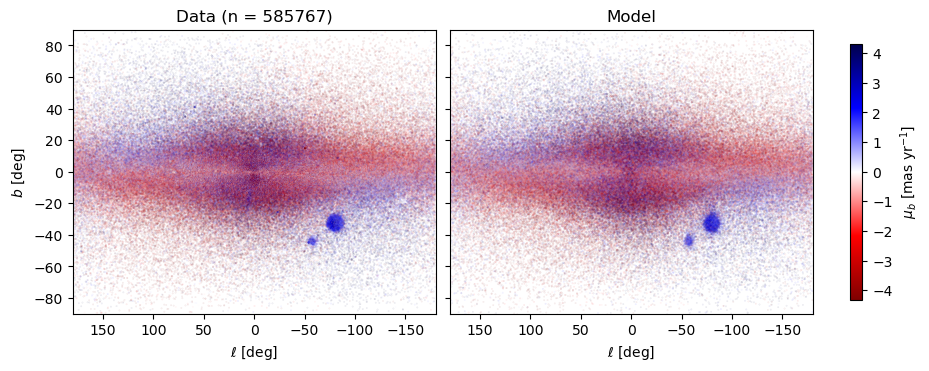

In [9]:
# =====================================================================
# FIGURE 2 -- sky positions, data vs the unconditional model
# =====================================================================
def figure_2(color_feature=None, set_label=None, save=True):
    color_feature = canon(color_feature or FIG2_COLOR)
    set_label = set_label or SET_LABELS[0]
    pred = uncond_phys.get(set_label)
    if pred is None:
        raise RuntimeError('no unconditional sample loaded for '
                           f'{set_label!r}; Figure 2 needs one.')

    proj = PROJECTIONS['position']
    ax_feats = ['l', 'b']
    c = F[color_feature]

    # Sources with a measured color feature AND measured positions.
    m = true_mask[:, c].copy()
    for f in ax_feats:
        m &= true_mask[:, F[f]]
    n_valid = int(m.sum())
    idx = np.where(m)[0]
    if MAX_POINTS is not None and n_valid > MAX_POINTS:
        idx = np.random.default_rng(0).choice(idx, MAX_POINTS, replace=False)

    style = marker_style(len(idx))
    ckw = (feature_color_kwargs_global(color_feature)
           if COLOR_SCALE_SCOPE == 'global'
           else feature_color_kwargs(true_phys[idx, c], color_feature))
    xlim = FIG2_XLIM if FIG2_XLIM is not None else l_axis_limits()

    fig, axs = plt.subplots(1, 2, figsize=(PANEL_WIDTH * 2, PANEL_HEIGHT),
                            squeeze=False, constrained_layout=True)

    im = axs[0, 0].scatter(axis_values(proj['x'], true_phys)[idx],
                           axis_values(proj['y'], true_phys)[idx],
                           c=true_phys[idx, c], **style, **ckw)
    if SHOW_PANEL_TITLES:
        axs[0, 0].set_title(f'Data (n = {n_valid})')
    _tidy(axs[0, 0], xlim, FIG2_YLIM, proj['invert_y'],
          show_x=True, show_y=True,
          xlabel=proj['xlabel'], ylabel=proj['ylabel'])

    im = axs[0, 1].scatter(axis_values(proj['x'], pred)[idx],
                           axis_values(proj['y'], pred)[idx],
                           c=pred[idx, c], **style, **ckw)
    if SHOW_PANEL_TITLES:
        axs[0, 1].set_title(set_label)
    _tidy(axs[0, 1], xlim, FIG2_YLIM, proj['invert_y'],
          show_x=True, show_y=False,
          xlabel=proj['xlabel'], ylabel=proj['ylabel'])

    cb = fig.colorbar(im, ax=axs[0, :].tolist(), label=tex(color_feature),
                      shrink=0.9)
    cb.solids.set(alpha=1)
    _suptitle(fig, f'unconditional  |  color: {color_feature}')

    if save:
        save_fig(fig, f'fig02_sky_unconditional_{file_tag(color_feature)}')
    else:
        plt.show()
    return fig


_ = figure_2()

### Figures 3 and 4

The same machinery draws both: a Data panel, then one panel per conditioning
pattern, with the model-minus-data residual underneath each.

The difference between the two figures is which patterns are shown, and
therefore whether the sky positions in the model panels are generated or
supplied. Figure 3 uses patterns that do **not** condition on $\ell$ and $b$,
so the positions you see are the model's own; Figure 4 uses patterns that do,
so every model panel sits at the true positions and only the color is
predicted.

`diff_scale='all'` pools the residual colorbar over every panel drawn,
including the unconditional one. That is the honest choice and it is what the
draft uses, at the cost of driving the conditional residual panels close to
white.

In [10]:
# =====================================================================
# A5. Pattern-comparison grid -- the engine behind Figures 3 and 4
# =====================================================================
# Row 0:  Data | model sample for pattern A | pattern B | ...
# Row 1:   --  | (model - data) for A       | for B     | ...
#
# x, y and color are each a specification: a bare feature name, a shorthand
# from ALIASES, or an expression in several features ('BP - RP').

# identifiers, but not attribute names: 'hypot' in 'np.hypot(pml, pmb)' is
# skipped, so numpy functions can be used inside a spec.
_IDENT = re.compile(r'(?<![\w.])[A-Za-z_][A-Za-z0-9_]*')
_OP_TAG = {'-': '_minus_', '+': '_plus_', '*': '_times_', '/': '_over_'}


def resolve_spec(spec, label=None):
    """
    -> dict(key, label, dlabel, feats, values, plain)
        key    file-name fragment       'BP_minus_RP'
        label  axis label               '$G_{BP} - G_{RP}$ [mag]'
        dlabel residual label           '$\\Delta(G_{BP} - G_{RP})$ [mag]'
        feats  the features it needs
        values callable (N, dim_phys) -> (N,)
        plain  the feature name if this is a bare feature, else None
    """
    if isinstance(spec, (tuple, list)):
        assert len(spec) == 2, 'tuple specs are (a, b), meaning a - b'
        spec = f'{spec[0]} - {spec[1]}'
    expr = _IDENT.sub(lambda m: ALIASES.get(m.group(0), m.group(0)),
                      str(spec).strip())

    names = [t for t in _IDENT.findall(expr) if t != 'np']
    unknown = [t for t in names if t not in F]
    if unknown:
        raise ValueError(f'unknown feature(s) {unknown} in {spec!r}; '
                         f'known: {list(F)} (aliases: {list(ALIASES)})')
    feats = list(dict.fromkeys(names))
    plain = expr if expr in F else None
    code_obj = compile(expr, '<spec>', 'eval')

    def values(arr):
        # A bare longitude is wrapped for display (see l_display); inside a
        # larger expression it is left alone, since wrapping a term of a sum or
        # difference would change the arithmetic rather than just the frame.
        if plain == 'l':
            return l_display(arr[:, F['l']])
        return eval(code_obj, {'np': np},
                    {f: arr[:, F[f]].astype(float) for f in feats})

    if plain is not None:
        auto, dauto = tex(plain), tex_delta(plain)
    else:
        body = _IDENT.sub(lambda m: sym(m.group(0)) if m.group(0) in F
                          else m.group(0), expr)
        units = {TEX_UNITS.get(f) for f in feats}
        # a sum or difference keeps the unit; anything else is left bare
        u = units.pop() if (len(units) == 1
                            and not set('*/').intersection(expr)) else None
        auto = f'${body}$' + (f' [{u}]' if u else '')
        dauto = rf'$\Delta({body})$' + (f' [{u}]' if u else '')
    if label is not None:
        auto = label

    key = _IDENT.sub(lambda m: file_tag(m.group(0)) if m.group(0) in F
                     else m.group(0), expr)
    for op, tag in _OP_TAG.items():
        key = key.replace(f' {op} ', tag).replace(op, tag)
    key = re.sub(r'[^A-Za-z0-9_]', '', key.replace('np.', '').replace(' ', ''))

    return dict(key=key, label=auto, dlabel=dauto, feats=feats,
                values=values, plain=plain)


def _pattern_array(j, set_label):
    """Model sample for a pattern, with conditioning features replaced by the
    truth -- the model was handed those, so its own copy is not interesting."""
    if j == 'uncond':
        src, cond = uncond_phys.get(set_label), []
    else:
        src, cond = cond_phys.get(set_label, {}).get(j), feature_permutation_names[j]
    if src is None:
        return None, cond
    d = src.copy()
    for f in cond:
        d[:, F[f]] = true_phys[:, F[f]]
    return d, cond

def _bin_edges(lim, width):
    """Edges of width `width` spanning an axis window (either orientation)."""
    lo, hi = sorted(float(v) for v in lim)
    n = max(1, int(np.ceil((hi - lo) / width - 1e-9)))
    return lo + width * np.arange(n + 1)


def _binned_residual(x, y, v, edges, stat='median', min_count=1):
    """(nx, ny) grid of `stat` of v in each (x, y) bin; NaN where a bin holds
    fewer than min_count sources (empty bins are NaN for either statistic)."""
    ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(v)
    x, y, v = x[ok], y[ok], v[ok]
    grid = binned_statistic_2d(x, y, v, statistic=stat, bins=edges).statistic
    if min_count > 1:
        cnt, _, _ = np.histogram2d(x, y, bins=edges)
        grid[cnt < min_count] = np.nan
    return grid

@with_fonts('fig3')          # Figure 4 passes fonts='fig4'
def compare_patterns(x, y, color, patterns, set_label=None, labels=None,
                     xlabel=None, ylabel=None, clabel=None, xlim=None,
                     ylim=None, invert_y=None, max_points=None,
                     diff_scale='all', color_scale=None, error_at='model',
                     show_errors=True, panel_w=None, panel_h=None,
                     save_name=None, title=None, verbose=True,
                     residual_bin=None, residual_stat='median', residual_mode = 'paired',
                     residual_min_count=1):
    """
    Data and a chosen set of patterns side by side, residuals underneath.

    patterns   : ordered list of config specs -- 'uncond', 'drop:<feature>',
                 or a list of conditioning features. Panels appear left to
                 right in the order given.
    diff_scale : 'all'      pooled over every panel drawn, unconditional
                            included -- honest, but the conditional residual
                            panels go nearly white. This is what the draft uses.
                 'figure'   pooled over the conditional panels only
                 (lo, hi)   explicit
    fonts      : key into FONT_SIZES. Supplied by the decorator, so a
                 caller only passes it to override the default 'fig3'.
    error_at   : 'model' -> residuals drawn at the model's own x/y
                 'data'  -> residuals drawn at the true x/y (a residual map)
    residual_bin : None -> residuals drawn as points (Figure 3). A number ->
                 residual row shows the per-bin `residual_stat` of model - data
                 in square bins of that side length, in axis units (degrees
                 for l, b); bins with fewer than `residual_min_count` sources
                 are left blank. The residual colour scale is then set from the
                 binned values, not the per-source ones.

    The unconditional column has no residual panel: an unconditional draw is an
    i.i.d. sample from p(x) with no source identity, so 'model - data' would pair
    row i of one sample with row i of another and measure the width of the
    distribution, not an error. Its cell in the residual row is left blank.
    """
    set_label = set_label or SET_LABELS[0]
    max_points = MAX_POINTS if max_points is None else max_points
    xs_ = resolve_spec(x, xlabel)
    ys_ = resolve_spec(y, ylabel)
    cs_ = resolve_spec(color, clabel)
    pattern_ids = [resolve_pattern_spec(p) for p in patterns]

    # sources where every feature involved is actually observed
    m = np.ones(len(true_phys), bool)
    for f in set(xs_['feats'] + ys_['feats'] + cs_['feats']):
        m &= true_mask[:, F[f]]
    n_valid = int(m.sum())
    if n_valid < 2:
        raise RuntimeError(f'only {n_valid} sources have all of '
                           f'{sorted(set(xs_["feats"] + ys_["feats"] + cs_["feats"]))}')
    idx = np.where(m)[0]
    if max_points is not None and idx.size > max_points:
        idx = np.random.default_rng(0).choice(idx, max_points, replace=False)
    style = marker_style(len(idx))

    x_true = xs_['values'](true_phys[idx])
    y_true = ys_['values'](true_phys[idx])
    c_true = cs_['values'](true_phys[idx])

    panels, skipped = [], []
    for j in pattern_ids:
        arr, cond = _pattern_array(j, set_label)
        if arr is None:
            skipped.append(j)
            continue
        cv = cs_['values'](arr[idx])
        err = cv - c_true
        if cs_['plain'] == 'l':
            err = wrap_l_diff(err)
        panels.append(dict(j=j, x=xs_['values'](arr[idx]),
                           y=ys_['values'](arr[idx]), c=cv, err=err,
                           cond=cond,
                           fully_cond=all(f in cond for f in cs_['feats'])))
    if not panels:
        raise RuntimeError(f'none of {patterns} are loaded for {set_label!r}')
    if skipped and verbose:
        print(f'  not loaded, skipped: {skipped}')

    # --- color scales ------------------------------------------------
    if color_scale is None:
        ckw = (feature_color_kwargs_global(cs_['plain'])
               if (cs_['plain'] is not None and COLOR_SCALE_SCOPE == 'global')
               else feature_color_kwargs(c_true[np.isfinite(c_true)], cs_['plain']))
    elif isinstance(color_scale, dict):
        ckw = color_scale
    else:
        ckw = dict(vmin=color_scale[0], vmax=color_scale[1], cmap='viridis')

    dkw = None
    if show_errors:
        if isinstance(diff_scale, (tuple, list)):
            dkw = dict(vmin=diff_scale[0], vmax=diff_scale[1], cmap='seismic_r')
        else:
            # The unconditional residual is never drawn (an unconditional draw
            # has no source identity, so model - data is not an error), so it
            # must not set the residual colour scale either.
            pool = [p['err'] for p in panels if not p['fully_cond']
                    and p['j'] != 'uncond']
            dkw = diff_color_kwargs(np.concatenate(pool or
                                                   [p['err'] for p in panels]))

    # --- axes ---------------------------------------------------------
    if invert_y is None:
        invert_y = (ys_['plain'] is not None
                    and TEX_UNITS.get(ys_['plain']) == 'mag')
    if xlim is None:
        xlim = (l_axis_limits() if xs_['plain'] == 'l' else
                (-90, 90) if xs_['plain'] == 'b' else limits_from(x_true, None))
    if ylim is None:
        ylim = (l_axis_limits() if ys_['plain'] == 'l' else
                (-90, 90) if ys_['plain'] == 'b' else limits_from(y_true, None))
        
    # --- binned residuals (optional) ------------------------------------
    edges = None
    if show_errors and residual_bin is not None:
        edges = [_bin_edges(xlim, residual_bin), _bin_edges(ylim, residual_bin)]
        for p in panels:
            if p['j'] == 'uncond' and residual_mode != 'distribution':          # no residual panel for this column
                continue
            if residual_mode == 'distribution':
                # median(model in bin) - median(data in bin); no source pairing
                g_model = _binned_residual(p['x'], p['y'], p['c'], edges,
                                           residual_stat, residual_min_count)
                g_data = _binned_residual(x_true, y_true, c_true, edges,
                                          residual_stat, residual_min_count)
                p['grid'] = g_model - g_data
            else:
                # 'paired': median over sources of (model - data)
                ex = x_true if error_at == 'data' else p['x']
                ey = y_true if error_at == 'data' else p['y']
                p['grid'] = _binned_residual(ex, ey, p['err'], edges,
                                             residual_stat, residual_min_count)
        # Per-bin medians are far narrower than per-source residuals, so the
        # scale is re-derived from what is actually drawn.
        if not isinstance(diff_scale, (tuple, list)):
            pool = [p['grid'][np.isfinite(p['grid'])] for p in panels
                    if 'grid' in p and not p['fully_cond']]
            pool = [g for g in pool if g.size]
            if pool:
                dkw = diff_color_kwargs(np.concatenate(pool))

    # --- layout -------------------------------------------------------
    # The colorbars live in a dedicated gridspec COLUMN rather than being
    # attached to their row's axes. Attached bars are sized and placed from the
    # axes they belong to, and the residual row holds one panel fewer than the
    # value row, so the two bars came out at different x and different heights.
    # A column gives them the same x, the same width, and one row of height
    # each: vertically aligned by construction.
    K = len(panels)
    nrows = 2 if show_errors else 1
    fig = plt.figure(constrained_layout=True,
                     figsize=((panel_w or PANEL_WIDTH) * (K + 1 + CBAR_WIDTH),
                              (panel_h or PANEL_HEIGHT) * nrows))
    gs = fig.add_gridspec(nrows, K + 2,
                          width_ratios=[1] * (K + 1) + [CBAR_WIDTH])
    axs = np.empty((nrows, K + 1), dtype=object)
    for _r in range(nrows):
        for _c in range(K + 1):
            axs[_r, _c] = fig.add_subplot(gs[_r, _c])
    caxes = [fig.add_subplot(gs[_r, -1]) for _r in range(nrows)]

    ax = axs[0, 0]
    im_c = ax.scatter(x_true, y_true, c=c_true, **style, **ckw)
    if SHOW_PANEL_TITLES:
        ax.set_title(f'Data (n = {len(idx):,})')
    _tidy(ax, xlim, ylim, invert_y, show_x=True, show_y=True,
          xlabel=xs_['label'], ylabel=ys_['label'])

    im_d = None
    first_residual = True
    for k, p in enumerate(panels):
        ax = axs[0, 1 + k]
        im_c = ax.scatter(p['x'], p['y'], c=p['c'], **style, **ckw)
        if SHOW_PANEL_TITLES:
            t = labels[k] if labels else pattern_panel_label(p['j'])
            if p['fully_cond'] and not labels:
                t += '\n(color was conditioned)'
            ax.set_title(t)
        no_residual = (p['j'] == 'uncond' and not (edges is not None and residual_mode == 'distribution'))
        # With no residual beneath it, this column's x axis goes on the top panel.
        _tidy(ax, xlim, ylim, invert_y,
              show_x=True, show_y=False,
              xlabel=xs_['label'], ylabel=ys_['label'])
        if show_errors:
            axe = axs[1, 1 + k]
            if no_residual:
                axe.axis('off')
                continue
            ex = x_true if error_at == 'data' else p['x']
            ey = y_true if error_at == 'data' else p['y']
            if edges is not None:
                im_d = axe.pcolormesh(edges[0], edges[1], p['grid'].T,
                                      shading='flat', rasterized=True, **dkw)
            else:
                im_d = axe.scatter(ex, ey, c=p['err'], **style, **dkw)
            _tidy(axe, xlim, ylim, invert_y, show_x=True,
                  show_y=first_residual,
                  xlabel=xs_['label'], ylabel=ys_['label'])
            if first_residual:
                # Leftmost residual panel gets y labels, but they are kept out
                # of the layout so they spill into the blank cell to the left
                # rather than widening this column (which would also open a
                # gap between Unconditional and the next panel in the top row).
                axe.yaxis.set_in_layout(False)
                first_residual = False
            if p['fully_cond'] and verbose:
                print(f'  note: {pattern_label(p["j"])} conditions on '
                      f'{cs_["key"]}; its residual is identically zero.')
    if show_errors:
        axs[1, 0].axis('off')

    cb = fig.colorbar(im_c, cax=caxes[0])
    cb.set_label(cs_['label'], **fkw('colorbar_label'))
    cb.solids.set(alpha=1)
    tick_fontsize(caxes[0], 'colorbar_tick')
    if show_errors:
        if im_d is not None:
            cb2 = fig.colorbar(im_d, cax=caxes[1])
            dlab = (cs_['dlabel'] if edges is None
                else f"{residual_stat.capitalize()} {cs_['dlabel']}")
            cb2.set_label(dlab, **fkw('colorbar_label'))
            cb2.solids.set(alpha=1)
            tick_fontsize(caxes[1], 'colorbar_tick')
        else:
            caxes[1].axis('off')

    if title is not None:
        fig.suptitle(title)
    else:
        _suptitle(fig, f'{ys_["key"]} vs {xs_["key"]}  |  color: {cs_["key"]}')

    if save_name:
        save_fig(fig, save_name)
    else:
        plt.show()
    return fig

  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig03_sky_generated_positions_plx.png


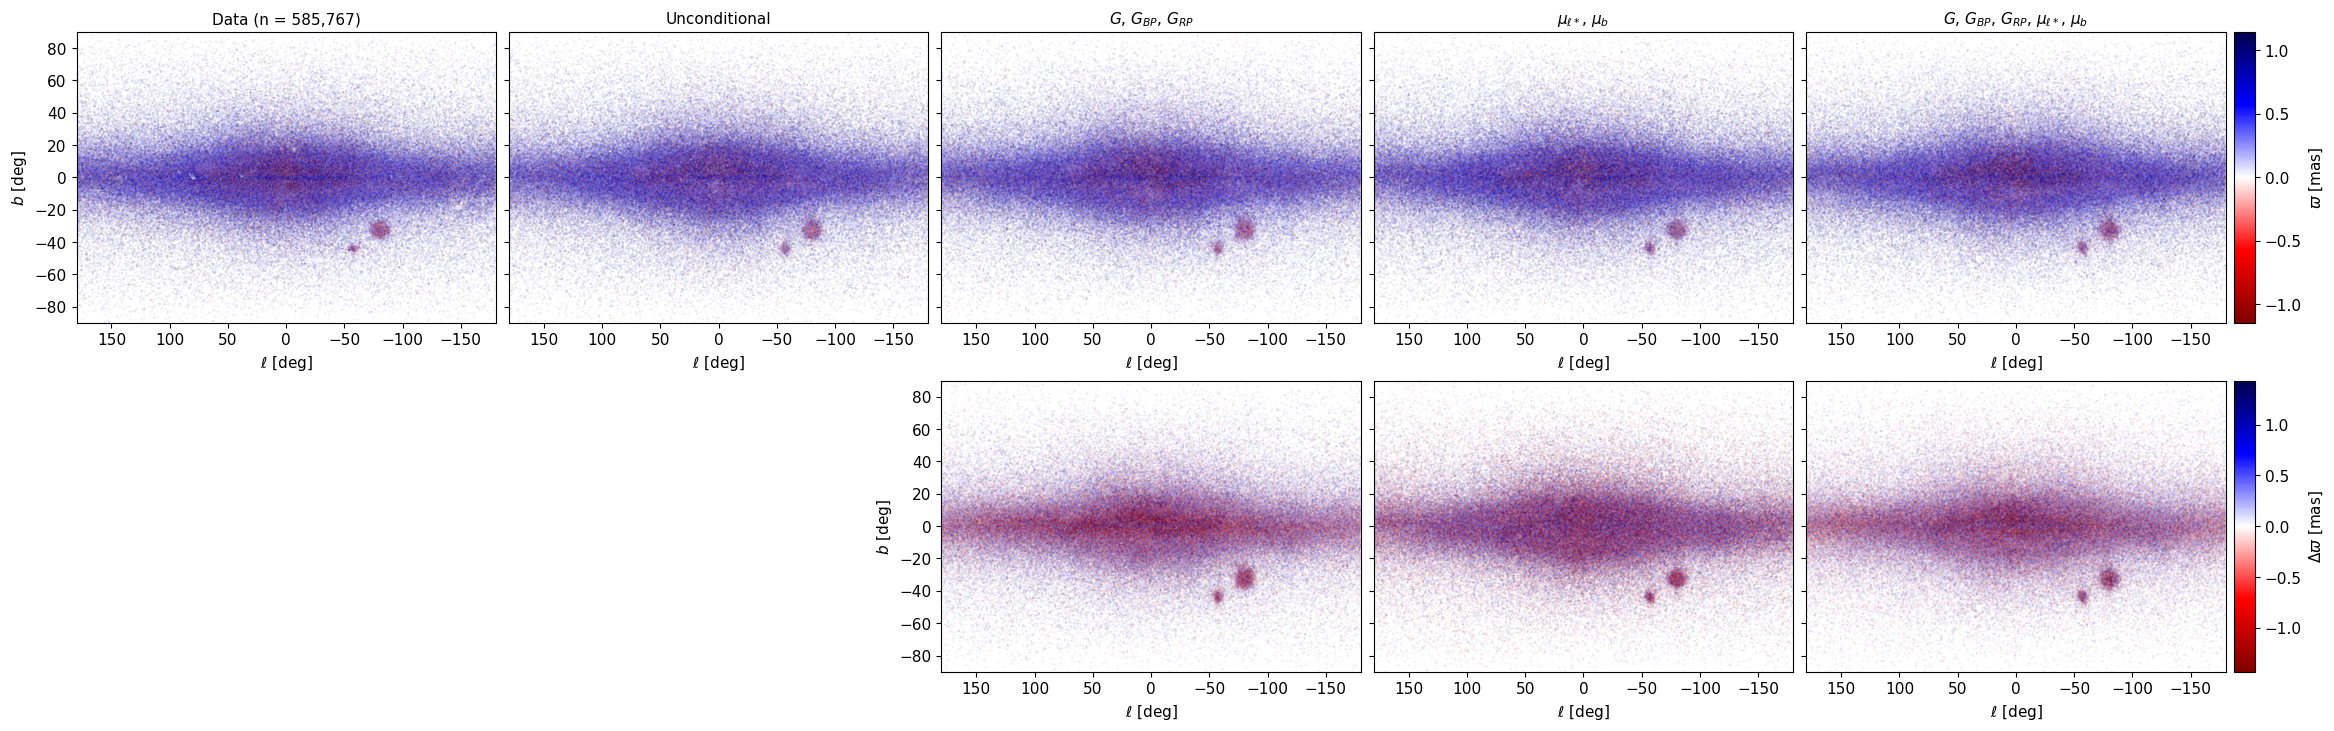

In [11]:
# =====================================================================
# FIGURE 3 -- parallax over the sky, model-generated positions
# =====================================================================
# None of these patterns condition on (l, b), so the sky positions in the model
# panels are the model's own.
_ = compare_patterns('l', 'b', FIG3_COLOR, patterns=FIG3_PATTERNS,
                     diff_scale=FIG3_DIFF_SCALE, fonts='fig3',
                     save_name='fig03_sky_generated_positions_'
                               f'{file_tag(canon(FIG3_COLOR))}')

### Figure 5

One panel per parameter: the true marginal filled in grey, the unconditional
model overlaid as a step histogram on identical bins, over the sources where
that parameter is observed. Data and model are histogrammed under the same
validity mask, so both curves hold the same number of sources and the counts
are directly comparable.

  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig05_marginals_unconditional.png


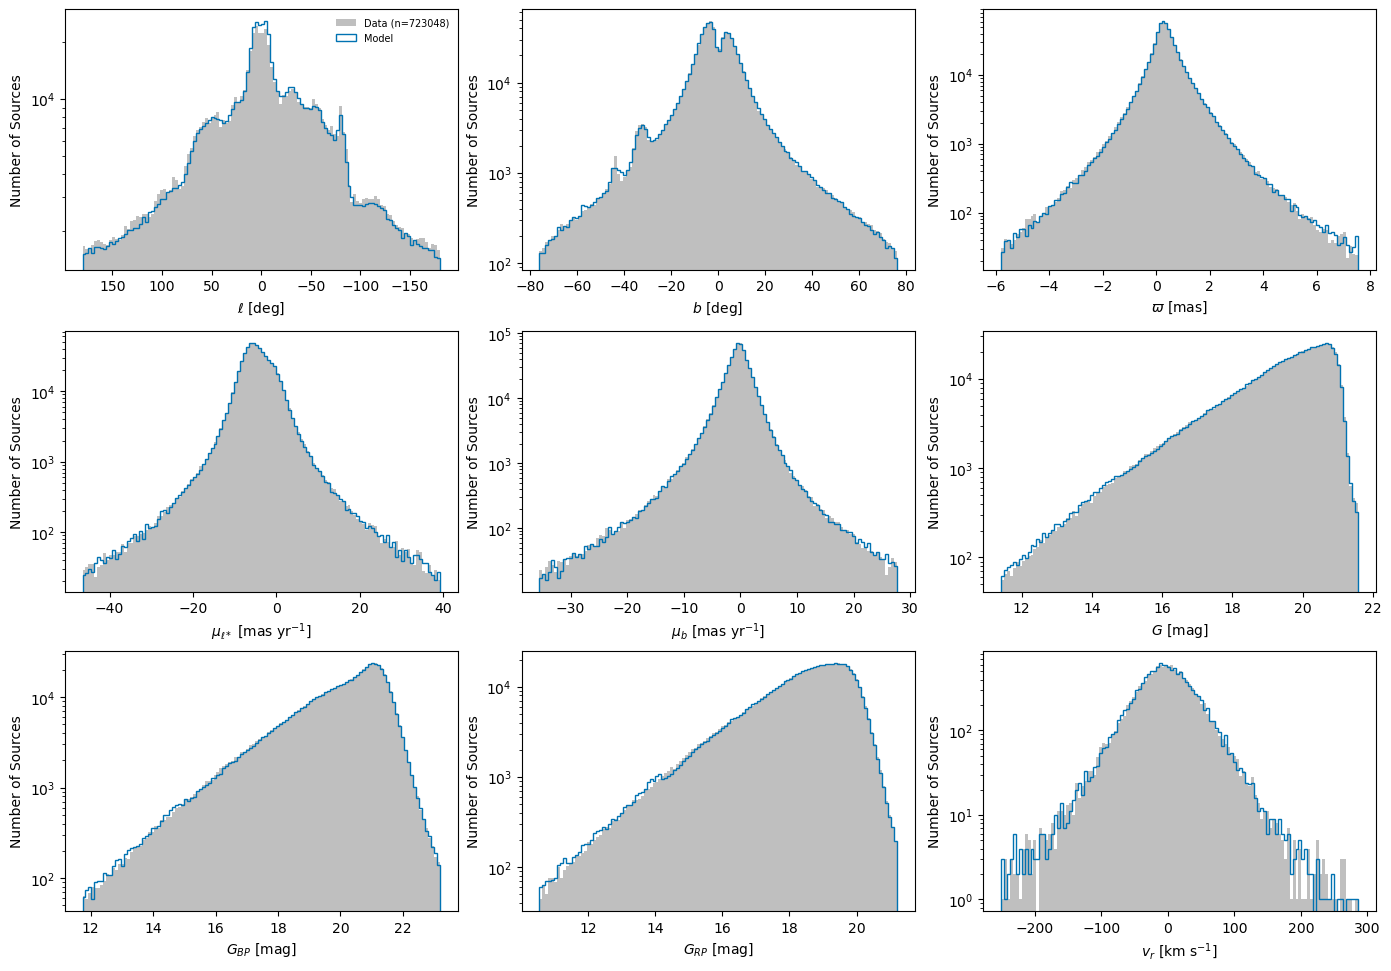

In [12]:
# =====================================================================
# FIGURE 5 -- marginal distributions, data vs the unconditional model
# =====================================================================
def figure_5(bins=None, ncols=None, logy=None, clip_percentiles=None,
             set_label=None, save=True):
    bins = FIG5_BINS if bins is None else bins
    ncols = FIG5_NCOLS if ncols is None else ncols
    logy = FIG5_LOGY if logy is None else logy
    clip_percentiles = (FIG5_CLIP_PERCENTILES if clip_percentiles is None
                        else clip_percentiles)
    set_label = set_label or SET_LABELS[0]

    arr = uncond_phys.get(set_label)
    if arr is None:
        raise RuntimeError('no unconditional sample loaded; Figure 5 needs one.')

    feats = list(range(dim_phys))
    nrows = int(np.ceil(len(feats) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.2 * nrows),
                            squeeze=False, constrained_layout=True)
    for ax in axs.ravel()[len(feats):]:
        ax.axis('off')

    for pos, c in enumerate(feats):
        ax = axs.ravel()[pos]
        feat = feature_names[c]
        m = true_mask[:, c]
        t = true_phys[m, c]
        v = arr[m, c]
        if feat == 'l':
            # Wrap to (-180, 180] to match Figures 2-4, and bin the FULL circle
            # rather than the 0.1-99.9 percentile. For a periodic variable the
            # extreme percentiles sit either side of the seam, so clipping
            # would drop sources from exactly the region the wrap exists to
            # show -- and they are not outliers, they are the bulge.
            t, v = l_display(t), l_display(v)
            lo, hi = L_LIMITS
        else:
            lo, hi = np.percentile(t, clip_percentiles)
            if hi <= lo:
                lo, hi = float(np.min(t)), float(np.max(t)) + 1e-9
        edges = np.linspace(lo, hi, bins + 1)

        ax.hist(t, bins=edges, color='0.75', label=f'Data (n={int(m.sum())})')
        ax.hist(v, bins=edges, histtype='step', lw=1.6,
                color=SET_COLORS[0], label=set_label)
        if feat == 'l' and INVERT_L_AXIS:
            ax.invert_xaxis()
        if logy:
            ax.set_yscale('log')
        ax.set_xlabel(tex(feat))
        ax.set_ylabel('Number of Sources')
        if pos == 0:
            ax.legend(fontsize=7, frameon=False)

    _suptitle(fig, 'Marginal distributions  |  unconditional')
    if save:
        save_fig(fig, 'fig05_marginals_unconditional')
    else:
        plt.show()
    return fig


_ = figure_5()

---

# Section B -- $\omega$ Centauri

Figures 6 and 7. Between them they compare three things at the same sightline:

* **cluster truth** -- the Soltis et al. (2021) $\omega$ Cen member sample,
* **model samples conditioned on those same stars** (Figures 6 and 7),
* **field truth**, cut out of an all-sky `Pure_Sample` in an annulus around the
  cluster (Figure 7 only). A 1.5-5 deg annulus clears the tidal tails and
  yields ~1400 stars.

The field is **truth only**. No field model sample is loaded, because none is
used: Figure 7's field traces are data, and Figure 6 has no field panel. That
also decouples this section from the all-sky sampling runs -- the field
`Pure_Sample` can be regenerated without any of these figures caring, which was
not true when the field panel needed row-aligned model samples.

This section needs Section A's cells A1-A3 to have run: it reuses the
denormalizer, the pattern list, and `load_dataset`.

In [13]:
# =====================================================================
# B1. Load the cluster, and the all-sky truth the field is cut out of
# =====================================================================
print('omega Cen:')
OC = load_dataset(CLUSTER_PURE_PATH, GEN_SAMPLE_DIR, CLUSTER_SAMPLE_NAME,
                  CLUSTER_TIMESTAMP, aux_path=CLUSTER_AUX_PATH,
                  label='omega Cen')

# TRUTH ONLY. Both field traces in Figure 7 are data, and Figure 6 no longer
# has a field panel, so no field model sample is used anywhere in this section.
# Loading the samples would also tie this cell to whichever all-sky sampling
# run matched this Pure_Sample, which is exactly the coupling that broke when
# the Pure_Sample was regenerated.
print('all-sky truth (source of the field):')
FIELD = load_dataset(FIELD_PURE_PATH, label='field', truth_only=True)

# Only cluster patterns matter now -- the model traces are all cluster_model.
PATTERNS_AVAILABLE = sorted(OC['cond'])
print(f'\n{len(PATTERNS_AVAILABLE)} cluster patterns available')

omega Cen:
  [omega Cen] N=67347, uncond=yes, 43/43 conditional patterns
all-sky truth (source of the field):
  [field] N=723048, truth only (no model samples loaded)

43 cluster patterns available


In [14]:
# =====================================================================
# B2. Selections on the two samples
# =====================================================================
# Every selection is a boolean mask, so any combination is free; they compose
# by intersection.
#
# Two caveats worth keeping in view:
#  * The Soltis proper-motion criterion (eq. 1, dmu < -6*dtheta + 5 with dtheta
#    in DEGREES) goes negative beyond 0.83 deg, so it can only be used INSIDE
#    the cone. For field samples at 1.5-5 deg a fixed ball of radius
#    PM_BALL_MASYR around the cluster's motion is the honest analogue.
#  * A PM cut with no spatial cut selects a real but different population --
#    halo stars anywhere on the sky sharing omega Cen's apparent motion. That
#    is a control, not an artefact.
def angsep_deg(l1, b1, l2, b2):
    l1r, b1r, l2r, b2r = map(np.deg2rad, (l1, b1, l2, b2))
    c = (np.sin(b1r) * np.sin(b2r)
         + np.cos(b1r) * np.cos(b2r) * np.cos(l1r - l2r))
    return np.rad2deg(np.arccos(np.clip(c, -1.0, 1.0)))


FIELD_THETA = angsep_deg(FIELD['truth'][:, F['l']], FIELD['truth'][:, F['b']],
                         OC_L, OC_B)
OC_THETA = angsep_deg(OC['truth'][:, F['l']], OC['truth'][:, F['b']],
                      OC_L, OC_B)

# Cluster mean PM in the Galactic frame, measured from the member sample itself
# rather than rotated by hand from the published (pmra, pmdec).
_m = OC['valid'][:, F['pml']] & OC['valid'][:, F['pmb']]
OC_PML = float(np.median(OC['truth'][_m, F['pml']]))
OC_PMB = float(np.median(OC['truth'][_m, F['pmb']]))
print(f'cluster mean PM (Galactic, from members): '
      f'pml={OC_PML:+.3f}, pmb={OC_PMB:+.3f}')


def _delta_mu(d):
    """|PM - PM_cluster| in mas/yr, in the Galactic frame the model uses."""
    return np.hypot(d['truth'][:, F['pml']] - OC_PML,
                    d['truth'][:, F['pmb']] - OC_PMB)


FIELD_DMU = _delta_mu(FIELD)
OC_DMU = _delta_mu(OC)


def cut_annulus(d, theta, r_in, r_out):
    return (theta >= r_in) & (theta < r_out)


def cut_cone(d, theta, r=OC_CONE_DEG):
    return theta < r


def cut_mag(d, lo=OC_G_WINDOW[0], hi=OC_G_WINDOW[1]):
    g = d['truth'][:, F['phot_g_mean_mag']]
    return d['valid'][:, F['phot_g_mean_mag']] & (g > lo) & (g < hi)


def cut_pm_ball(d, dmu, r=PM_BALL_MASYR):
    return np.isfinite(dmu) & (dmu < r)


# Feature groups. When plotting a distribution, never condition on anything in
# the SAME group: conditioning on BP and RP fixes G through the color relation
# just as conditioning on G would, and conditioning on pml constrains pmb
# through the cluster's coherent motion.
FEATURE_GROUPS = {
    'position': ['l', 'b'],
    'parallax': ['parallax'],
    'photometry': ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'],
    'proper_motion': ['pml', 'pmb'],
    'radial_velocity': ['radial_velocity'],
}
_GROUP_OF = {f: g for g, fs in FEATURE_GROUPS.items() for f in fs}


def patterns_excluding_group(feature, available=None):
    """Patterns conditioning on NOTHING in `feature`'s group, largest first."""
    banned = set(FEATURE_GROUPS.get(_GROUP_OF.get(feature), [feature]))
    avail = PATTERNS_AVAILABLE if available is None else available
    return sorted([j for j in avail
                   if not (banned & set(feature_permutation_names[j]))],
                  key=lambda j: -len(feature_permutation_names[j]))

cluster mean PM (Galactic, from members): pml=-4.173, pmb=-6.226


In [15]:
# =====================================================================
# B3. The trace registry  (Figure 7)
# =====================================================================
# A trace is one named 1-D distribution: a set of values plus how to draw it.
# Figure 7 is built by naming traces, so rearranging what is overlaid never
# touches plotting code.
TRACE_SPECS = {
    'cluster': dict(kind='cluster_truth', label=r'$\omega$ Cen (Soltis members)',
                    color='#111111', lw=2.4, ls='-'),
    'global': dict(kind='field_truth', label='All-Sky Field',
                   cuts=[], color='#999999', lw=1.6, ls='-'),
    'field_ang': dict(kind='field_truth', label='field, annulus',
                      cuts=['annulus'], color='#0072B2', lw=1.8, ls='-'),
}

_CUTS = {
    'annulus': lambda d, th, dmu: cut_annulus(d, th, *FIELD_ANNULUS),
    'cone':    lambda d, th, dmu: cut_cone(d, th),
    'mag':     lambda d, th, dmu: cut_mag(d),
    'pm_ball': lambda d, th, dmu: cut_pm_ball(d, dmu),
}


def _resolve_trace_pattern(p):
    if p == 'uncond':
        return 'uncond'
    return p() if callable(p) else int(p)


def get_trace(name, feature):
    """-> (values, spec), or (None, reason) if the trace cannot be drawn."""
    spec = name if isinstance(name, dict) else TRACE_SPECS[name]
    j = F[feature]
    kind = spec['kind']
    d = OC if kind.startswith('cluster') else FIELD
    theta = OC_THETA if kind.startswith('cluster') else FIELD_THETA
    dmu = OC_DMU if kind.startswith('cluster') else FIELD_DMU

    m = np.ones(d['N'], dtype=bool)
    for c in spec.get('cuts', []):
        m &= _CUTS[c](d, theta, dmu)

    if kind.endswith('truth'):
        vals = d['truth'][m & d['valid'][:, j], j]
    elif _resolve_trace_pattern(spec['pattern']) == 'uncond':
        src = d['uncond']
        if src is None:
            return (None, 'no unconditional sample file loaded')
        # Unconditional draws are i.i.d. from p(x) and carry no source
        # identity, so row-based cuts do not apply: an angular selection on the
        # CONDITIONING sources says nothing about which draw is which. This
        # trace is the model's global distribution -- the null.
        vals = src[:, j]
    else:
        p = _resolve_trace_pattern(spec['pattern'])
        src = d['cond'].get(p)
        if src is None:
            return (None, f'pattern {p} not present in this dataset')
        vals = src[m, j]

    vals = vals[np.isfinite(vals)]
    if vals.size < MIN_TRACE_N:
        why = f'only {vals.size} sources (< MIN_TRACE_N={MIN_TRACE_N})'
        if spec.get('cuts'):
            why += f"; cuts applied: {' + '.join(spec['cuts'])}"
        return (None, why)
    return (vals, spec)


def trace_is_conditioned(name, feature):
    spec = name if isinstance(name, dict) else TRACE_SPECS[name]
    if not spec['kind'].endswith('model'):
        return False
    p = _resolve_trace_pattern(spec['pattern'])
    return False if p == 'uncond' else feature in feature_permutation_names[p]


def auto_model_traces(feature, n_middle=1, extra=(),
                      colors=('#CC79A7', '#009E73', '#E69F00', '#D55E00')):
    """
    The three model traces of the rubric:
      (a) unconditional -- what the model produces knowing nothing,
      (b) the largest pattern conditioning on NOTHING in the feature's group,
      (c) the drop-one pattern that withholds the feature.

    (b) is the point of the group guard: conditioning on BP+RP determines G
    just as conditioning on G would, so the whole group is excluded.
    """
    feature = canon(feature)
    out = [dict(kind='cluster_model', pattern='uncond',
                label='Model | Unconditional', color=colors[0], lw=2.0, ls='--')]
    try:
        j_drop = drop_pattern(feature)
    except KeyError:
        j_drop = None
    # The drop-one pattern is slot (c); for parallax and RV it also happens to
    # be the largest pattern excluding the group, so exclude it here or (b) and
    # (c) would be the same curve drawn twice.
    mids = [j for j in patterns_excluding_group(feature) if j != j_drop]
    mids = list(extra) + [j for j in mids if j not in extra]
    for k, j in enumerate(mids[:n_middle]):
        out.append(dict(kind='cluster_model', pattern=j,
                        label=f'Model | {pattern_label_tex(j)}',
                        color=colors[1 + k], lw=2.0, ls='--'))
    if j_drop is not None and j_drop in PATTERNS_AVAILABLE:
        out.append(dict(kind='cluster_model', pattern=j_drop,
                        label=f'Model | {pattern_label_tex(j_drop)}',
                        color=colors[-1], lw=2.4, ls='--'))
    return out


def plot_traces(feature, traces, bins=60, xlim=None, logy=True, density=True,
                title=None, figsize=None, save_name=None):
    """One panel, every named trace overlaid on identical bins."""
    feature = canon(feature)
    if xlim is None:
        pool = []
        for nm in traces:
            v, _ = get_trace(nm, feature)
            if v is not None and v.size:
                pool.append(np.percentile(v, [0.5, 99.5]))
        if pool:
            pool = np.array(pool)
            xlim = (float(pool[:, 0].min()), float(pool[:, 1].max()))
    edges = np.linspace(*xlim, bins + 1) if xlim else bins

    fig, ax = plt.subplots(figsize=figsize or (PANEL_W * 2, PANEL_H * 1.5))
    dropped = []
    for nm in traces:
        v, spec = get_trace(nm, feature)
        if v is None:
            key = nm if isinstance(nm, str) else nm.get('label', '?')
            dropped.append(f'{key}: {spec}')
            continue
        lab = f'{spec["label"]}  (n={v.size:,})'
        if trace_is_conditioned(nm, feature):
            lab += '  [CONDITIONED]'
        ax.hist(v, bins=edges, histtype='step', density=density,
                color=spec.get('color'), lw=spec.get('lw', 1.8),
                ls=spec.get('ls', '-'), label=lab)
    if logy:
        ax.set_yscale('log')
    if xlim:
        ax.set_xlim(*xlim)
    ax.set_xlabel(tex(feature))
    ax.set_ylabel('Density' if density else 'Number of Sources')
    ax.legend(fontsize=7.5, framealpha=0.9)
    if title and SHOW_PANEL_TITLES:
        ax.set_title(title, fontsize=10)
    fig.tight_layout()

    if dropped:
        print(f'[{feature}] traces not drawn:')
        for msg in dict.fromkeys(dropped):
            print(f'    {msg}')
        print(f'    -> lower MIN_TRACE_N (now {MIN_TRACE_N}), widen '
              f'FIELD_ANNULUS (now {FIELD_ANNULUS}), or drop a cut.')
    if save_name:
        save_fig(fig, save_name)
    else:
        plt.show()
    return fig

In [16]:
# =====================================================================
# B4. Cluster data vs model  (Figure 6)
# =====================================================================
OC_PROJECTIONS = {
    'position': dict(x='l', y='b', xlabel=tex('l'), ylabel=tex('b')),
    'cmd': dict(x=('phot_bp_mean_mag', 'phot_rp_mean_mag'),
                y='phot_g_mean_mag', xlabel=r'$G_{BP} - G_{RP}$ [mag]',
                ylabel=tex('phot_g_mean_mag'), invert_y=True),
    'proper_motion': dict(x='pml', y='pmb', xlabel=tex('pml'),
                          ylabel=tex('pmb')),
}


def _axis_values(arr, spec):
    if isinstance(spec, tuple):
        return arr[:, F[spec[0]]] - arr[:, F[spec[1]]]
    return arr[:, F[spec]]


def _axis_values_model(truth, model, spec, cond_set):
    """Axis values for a MODEL panel, taking each component from the data
    wherever that feature was conditioned on. Applied per component, so a
    color index like BP-RP correctly mixes a conditioned BP with a
    generated RP."""
    def pick(f):
        use_truth = USE_TRUTH_FOR_CONDITIONED_AXES and f in cond_set
        return (truth if use_truth else model)[:, F[f]]
    if isinstance(spec, tuple):
        return pick(spec[0]) - pick(spec[1])
    return pick(spec)


def _cond_note(spec, cond_set):
    """'$\\ell$ from data' -- which axis components were handed to the model."""
    if not USE_TRUTH_FOR_CONDITIONED_AXES:
        return ''
    comps = spec if isinstance(spec, tuple) else (spec,)
    from_data = [tex(f, unit=False) for f in comps if f in cond_set]
    return f'{", ".join(from_data)} from data' if from_data else ''


def _spec_features(P):
    x = P['x'] if isinstance(P['x'], tuple) else (P['x'],)
    y = P['y'] if isinstance(P['y'], tuple) else (P['y'],)
    return tuple(x) + tuple(y)


def _cluster_selection(P, color_feature, max_points, rng):
    keep = OC['valid'][:, F[color_feature]].copy()
    for f in _spec_features(P):
        keep &= OC['valid'][:, F[f]]
    idx = np.where(keep)[0]
    if idx.size > max_points:
        idx = np.sort(rng.permutation(idx)[:max_points])
    return idx


def _color_limits(mode, data_vals, model_vals):
    """vmin/vmax for the single, LINEAR colorbar shared by both panels.

    'full' takes the outright min and max over the data and the model together.
    No percentile clipping: the gap between the cluster's true proper motion
    and the model's is the result this figure exists to show, and clipping to a
    1-99 percentile window, or ranking the values onto a quantile scale, would
    compress exactly the thing being measured. The cluster panel going nearly
    one color under this scale is the point, not a defect.
    """
    if isinstance(mode, (tuple, list)):
        return float(mode[0]), float(mode[1])
    if mode == 'data':
        v = data_vals
    else:                                     # 'full'
        v = np.concatenate([x for x in (data_vals, model_vals)
                            if x is not None and len(x)])
    v = v[np.isfinite(v)]
    lo, hi = float(np.min(v)), float(np.max(v))
    if hi <= lo:
        lo, hi = lo - 0.5, hi + 0.5
    return lo, hi


def plot_cluster_vs_model(proj, color_feature, pattern, max_points=None,
                          s=None, color_limits='full', figsize=None,
                          save_name=None):
    """
    Paper layout: omega Cen data | model, ONE linear colorbar across both.

    The field panel that used to sit on the right is gone. It needed an all-sky
    model sample row-aligned to an all-sky Pure_Sample, which tied this figure
    to one particular sampling run, and it carried little the annulus trace in
    Figure 7 does not already say.
    """
    color_feature = canon(color_feature)
    max_points = FIG6_MAX_POINTS if max_points is None else max_points
    s = FIG6_MARKER_S if s is None else s
    j = resolve_pattern_spec(pattern)
    if j not in OC['cond']:
        raise RuntimeError(f'pattern {j} ({pattern_label(j)}) is not loaded '
                           f'for the cluster.')

    P = OC_PROJECTIONS[proj]
    rng = np.random.default_rng(0)
    cj = F[color_feature]
    cond_set = set(feature_permutation_names[j])
    if color_feature in cond_set:
        print(f'note: this pattern conditions on {file_tag(color_feature)}; '
              f'the model panel is showing the data value back.')

    idx = _cluster_selection(P, color_feature, max_points, rng)
    xt = _axis_values(OC['truth'], P['x'])[idx]
    yt = _axis_values(OC['truth'], P['y'])[idx]
    ct = OC['truth'][idx, cj]
    xm = _axis_values_model(OC['truth'], OC['cond'][j], P['x'], cond_set)[idx]
    ym = _axis_values_model(OC['truth'], OC['cond'][j], P['y'], cond_set)[idx]
    cm = _axis_values_model(OC['truth'], OC['cond'][j], color_feature,
                            cond_set)[idx]

    vmin, vmax = _color_limits(color_limits, ct, cm)
    print(f'color range [{vmin:.3g}, {vmax:.3g}] {unit(color_feature)}  '
          f'(Data {ct.min():.3g} to {ct.max():.3g}, '
          f'Model {np.nanmin(cm):.3g} to {np.nanmax(cm):.3g})')

    fig, axes = plt.subplots(1, 2, squeeze=False, constrained_layout=True,
                             figsize=figsize or (PANEL_W * 2, PANEL_H))
    axes = axes[0]
    note = _cond_note(P['x'], cond_set) or _cond_note(P['y'], cond_set)
    panels = [
        (xt, yt, ct, f'$\\omega$ Cen Data (n = {idx.size:,})'),
        (xm, ym, cm, f'Model | {pattern_label_tex(j)}'
                     + (f'\n({note})' if note else '')),
    ]
    for ax, (xx, yy, cc, ttl) in zip(axes, panels):
        sc = ax.scatter(xx, yy, c=cc, s=s, lw=0, cmap='viridis',
                        vmin=vmin, vmax=vmax)
        if SHOW_PANEL_TITLES:
            ax.set_title(ttl, fontsize=10)
        ax.set_xlabel(P['xlabel'])
        if P.get('invert_y'):
            ax.invert_yaxis()
        tune_ticks(ax)
    axes[0].set_ylabel(P['ylabel'])
    axes[1].sharex(axes[0])
    axes[1].sharey(axes[0])
    axes[1].tick_params(labelleft=False)

    fig.colorbar(sc, ax=axes.tolist(), label=tex(color_feature), shrink=0.9)
    _suptitle(fig, f'{proj}  |  color: {color_feature}  |  {pattern_label(j)}')

    if save_name:
        save_fig(fig, save_name)
    else:
        plt.show()
    return fig

### Figure 7

The marginal in $\mu_{\ell*}$: cluster members, the all-sky field, the annulus
field, and three model traces chosen by the rubric in `auto_model_traces` --
unconditional, the largest pattern conditioning on nothing in the proper-motion
group, and the drop-one pattern that withholds $\mu_{\ell*}$.

Note what the rubric excludes: for $\mu_{\ell*}$ it will not offer a pattern
containing $\mu_b$, because a cluster's two PM components are not independent.

model traces chosen by the rubric:
  Model | Unconditional
  Model | $\ell$, $b$
  Model | $\ell$, $b$, $\varpi$, $G$, $G_{BP}$, $G_{RP}$
  Model | drop $\mu_{\ell*}$
  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig07_omegacen_marginal_pml.png


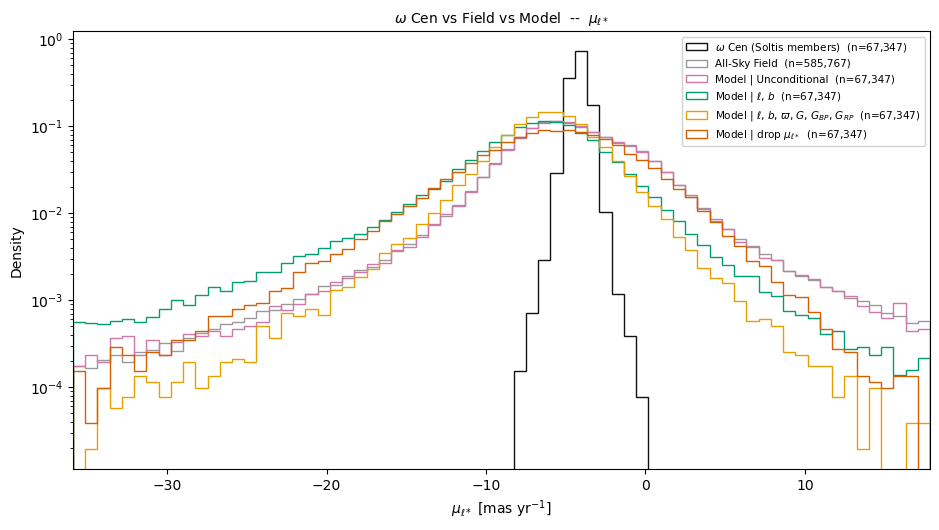

In [17]:
# =====================================================================
# FIGURE 7 -- omega Cen vs field vs model, marginal in pml
# =====================================================================
_fig7_traces = list(FIG7_TRACES) + auto_model_traces(
    FIG7_FEATURE, n_middle=2, extra=[pattern_index('l', 'b')])
print('model traces chosen by the rubric:')
for _t in _fig7_traces[len(FIG7_TRACES):]:
    print(f'  {_t["label"]}')

_ = plot_traces(FIG7_FEATURE, _fig7_traces, bins=FIG7_BINS,
                figsize=FIG7_FIGSIZE,
                title=f'$\\omega$ Cen vs Field vs Model  --  '
                      f'{tex(canon(FIG7_FEATURE), unit=False)}',
                save_name=f'fig07_omegacen_marginal_'
                          f'{file_tag(canon(FIG7_FEATURE))}')

---

# Section C -- imputing radial velocity

Figures 8, 9 and 10. All three read one imputation run: a JSON manifest plus,
for each (target, conditioning pattern, flavour), a samples file and a
row-aligned truth file, already in physical units.

**Flavours.** `have` are sources with a Gaia-measured $v_r$, so an error and a
skill can be formed for them; `missing` are sources without one, where only the
imputed *distribution* can be compared. A difference between the two means
either the model behaves differently on those sources or the two populations
differ -- which is what Figure 10 is for, and why it should be read first.

This section is independent of A, B and D. It defines its own feature index
(`IMP_FEATURES`, `IMP_F`) from the manifest.

In [18]:
# =====================================================================
# C1. Manifest, feature index, pattern index for the target
# =====================================================================
if IMP_MANIFEST is None:
    _cands = sorted(IMP_SAMPLE_DIR.glob('imputation_manifest_*.json'))
    if not _cands:                      # tolerate a hand-renamed manifest
        _cands = sorted(p for p in IMP_SAMPLE_DIR.glob('*manifest*.json'))
    if not _cands:
        raise FileNotFoundError(f'no imputation_manifest_*.json in '
                                f'{IMP_SAMPLE_DIR}')
    IMP_MANIFEST = _cands[-1]
IMP_MANIFEST = Path(IMP_MANIFEST)

with open(IMP_MANIFEST) as _fh:
    manifest = json.load(_fh)

# Guard rail: the sampler denormalizes before saving. If a future run goes back
# to writing model space, fail here rather than silently plotting normalized
# units.
if manifest.get('sample_space') != 'physical':
    raise RuntimeError(f"manifest says sample_space="
                       f"{manifest.get('sample_space')!r}; this notebook "
                       f"assumes 'physical'.")

IMP_FEATURES = list(manifest['feature_names'])
IMP_DIM = len(IMP_FEATURES)
IMP_F = {n: i for i, n in enumerate(IMP_FEATURES)}
IMP_MODEL_NAME = manifest.get('model_name', '?')
IMP_TARGET = canon(IMP_TARGET)
if IMP_TARGET not in IMP_F:
    raise KeyError(f'IMP_TARGET {IMP_TARGET!r} not in {IMP_FEATURES}')
if FIG9_N_EXPECTED is None:
    FIG9_N_EXPECTED = int(manifest.get('n_per_subset', 1000))

print(f'manifest : {IMP_MANIFEST.name}')
print(f'model    : {IMP_MODEL_NAME}')
print(f'features : {IMP_DIM}  {IMP_FEATURES}')
print(f'n_draws  : {manifest["n_draws"]}   rk4_steps={manifest["rk4_steps"]}'
      f'   n_per_subset={manifest.get("n_per_subset", "?")}')

# --- index every (pattern, flavour) for this target -------------------
ENTRIES = [e for e in manifest['entries'] if e['target'] == IMP_TARGET]
USABLE = [e for e in ENTRIES
          if e.get('status') in ('ok', 'short') and e.get('samples_file')]
if not USABLE:
    raise SystemExit(f'every entry for target {IMP_TARGET!r} is empty')
N_EMPTY = len(ENTRIES) - len(USABLE)

BY = {(e['pattern_digits'], e['flavour']): e for e in USABLE}


def _any_entry(t):
    return BY.get((t, 'have')) or BY.get((t, 'missing'))


def cond_features_of(tag):
    e = _any_entry(tag)
    return list(e['cond_features']) if e else []


# Secondary sort on the tag itself: without it, ties in n_cond are ordered by
# set iteration, which is hash-randomized per process.
TAGS = sorted({e['pattern_digits'] for e in USABLE},
              key=lambda t: (-len(_any_entry(t)['cond_features']), t))
NCOND = {t: len(cond_features_of(t)) for t in TAGS}


def imp_label(cond, symbols=False):
    """Short label for a conditioning pattern, in symbols or plain text."""
    name = (lambda f: tex(f, unit=False)) if symbols else short
    if not cond:
        return 'unconditional'
    if len(cond) == IMP_DIM - 1:
        miss = [f for f in IMP_FEATURES if f not in cond]
        return f'drop {name(miss[0])}'
    if len(cond) == 1:
        return f'only {name(cond[0])}'
    return ', '.join(name(f) for f in cond)


LABEL = {t: imp_label(cond_features_of(t)) for t in TAGS}
LABEL_TEX = {t: imp_label(cond_features_of(t), symbols=True) for t in TAGS}


def imp_tag(spec):
    """Resolve a config pattern spec to a v3 pattern_digits tag.

    Accepted: 'unconditional' | 'drop:<feature>' | a list of features.
    """
    if spec in (None, 'unconditional', 'uncond') or spec == []:
        want = set()
    elif isinstance(spec, str) and spec.startswith('drop:'):
        d = canon(spec.split(':', 1)[1])
        want = {f for f in IMP_FEATURES if f != d}
    elif isinstance(spec, str):
        want = {canon(spec)}
    else:
        want = {canon(f) for f in spec}
    hits = [t for t in TAGS if set(cond_features_of(t)) == want]
    if not hits:
        raise KeyError(f'no pattern for target {IMP_TARGET!r} conditions on '
                       f'exactly {sorted(want)}.\n'
                       f'available: {[(t, LABEL[t]) for t in TAGS]}')
    return hits[0]


print(f'\ntarget = {IMP_TARGET}   ({len(TAGS)} patterns withheld it, '
      f'{N_EMPTY} entries structurally empty and skipped)')
_W = max(14, min(40, max(len(v) for v in LABEL.values()) + 1))
print(f"  {'tag':<12}{'n_cond':>7}  {'label':<{_W}}{'have':>7}{'missing':>9}")
for _t in TAGS:
    _h, _m = BY.get((_t, 'have')), BY.get((_t, 'missing'))
    print(f"  {_t:<12}{NCOND[_t]:>7}  {LABEL[_t][:_W]:<{_W}}"
          f"{(_h['n_used'] if _h else 0):>6}{'*' if _h and _h['status'] == 'short' else ' '}"
          f"{(_m['n_used'] if _m else 0):>8}{'*' if _m and _m['status'] == 'short' else ' '}")
print('  (* = short: fewer eligible sources than n_per_subset)')

manifest : imputation_manifest_POS_PM_setA_0710_RK50_2026-09-05_12-46.json
model    : POS_PM_mask_set_setA_CUSTOM_2026-07-10_15-01-16_mask_train_mask_val_MSE_vHD512_SIGMA1_0e-08_GELU_lr1_0e-04_wd0_0e+00_layers8_MP85_ADD_SET_VALACUMVAL_10
features : 9  ['l', 'b', 'parallax', 'pml', 'pmb', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity']
n_draws  : 100   rk4_steps=50   n_per_subset=1000

target = radial_velocity   (18 patterns withheld it, 0 entries structurally empty and skipped)
  tag          n_cond  label                  have  missing
  01234567          8  drop RV               1000     1000 
  01234             5  l, b, plx, pml, pmb   1000     1000 
  01567             5  l, b, G, BP, RP       1000     1000 
  0134              4  l, b, pml, pmb        1000     1000 
  012               3  l, b, plx             1000     1000 
  015               3  l, b, G               1000     1000 
  234               3  plx, pml, pmb         1000     1000 
  567  

In [19]:
# =====================================================================
# C2. Loaders  (Figures 8 and 10)
# =====================================================================
_DIAG_CACHE = {}


def load_block(tag, flavour):
    """
    -> dict(samples_phys (n, n_draws, dim), truth (n, dim) NaN where absent,
            valid (n, dim) bool, ...) or None.

    None is legitimate: correlated missingness makes some patterns unusable on
    the 'missing' subset -- a source with no parallax is a 2-parameter
    solution, so it has no proper motion either.
    """
    key = (tag, flavour)
    if key in _DIAG_CACHE:
        return _DIAG_CACHE[key]
    e = BY.get(key)
    if e is None:
        _DIAG_CACHE[key] = None
        return None

    # The manifest records bare filenames and was written on the cluster, so
    # always resolve against the local IMP_SAMPLE_DIR.
    s_path = IMP_SAMPLE_DIR / Path(e['samples_file']).name
    t_path = IMP_SAMPLE_DIR / Path(e['truth_file']).name
    absent = [p.name for p in (s_path, t_path) if not p.exists()]
    if absent:
        print(f'  [{tag}/{flavour}] missing file(s): {absent}')
        _DIAG_CACHE[key] = None
        return None

    ds = np.load(s_path, allow_pickle=True).item()
    dt = np.load(t_path, allow_pickle=True).item()

    sid_s, sid_t = np.asarray(ds['source_id']), np.asarray(dt['source_id'])
    if sid_s.shape != sid_t.shape or not np.array_equal(sid_s, sid_t):
        raise RuntimeError(f'[{tag}/{flavour}] samples and truth are not '
                           f'row-aligned on source_id')

    samples = np.asarray(ds['samples'], dtype=np.float64)
    truth = np.asarray(dt['truth'], dtype=np.float64)
    valid = np.asarray(dt['valid']) > 0.5
    if samples.shape[0] != truth.shape[0] or samples.shape[2] != IMP_DIM:
        raise RuntimeError(f'[{tag}/{flavour}] shape mismatch: '
                           f'samples {samples.shape}, truth {truth.shape}')
    truth[~valid] = np.nan

    # The input mask must be exactly the pattern, identically for every source.
    in_mask = np.asarray(ds['input_mask_phys']) > 0.5
    want = np.zeros(IMP_DIM, dtype=bool)
    for f in ds['cond_features']:
        want[IMP_F[f]] = True
    if not (in_mask == want).all():
        raise RuntimeError(f'[{tag}/{flavour}] input mask does not match '
                           f'cond_features {list(ds["cond_features"])}')

    out = dict(samples_phys=samples, truth=truth, valid=valid,
               n_eligible=int(e.get('n_eligible', samples.shape[0])),
               n_used=int(samples.shape[0]), n_draws=int(samples.shape[1]))
    _DIAG_CACHE[key] = out
    return out


def target_arrays(tag, flavour, feature=None):
    """
    -> (draws (n, n_draws), truth (n,) or None, block)
    for the target column, keeping only sources with a finite truth in the
    'have' flavour. Non-finite draws are dropped per source: the sampler saves
    integrator output verbatim, so a few cells can be inf or NaN.
    """
    feature = canon(feature or IMP_TARGET)
    blk = load_block(tag, flavour)
    if blk is None:
        return None, None, None
    j = IMP_F[feature]
    dr = blk['samples_phys'][:, :, j]
    tr = blk['truth'][:, j]
    if flavour == 'have':
        keep = np.isfinite(tr) & (np.isfinite(dr).all(axis=1)
                                  if DROP_NONFINITE else True)
        return dr[keep], tr[keep], blk
    keep = np.isfinite(dr).all(axis=1) if DROP_NONFINITE else slice(None)
    return dr[keep], None, blk


def hist_kw(density=None):
    """density=True/False overrides HIST_COUNTS for one call."""
    return dict(density=(not HIST_COUNTS) if density is None else density)


def count_ylabel(unit_word='Sources'):
    return f'Number of {unit_word}' if HIST_COUNTS else 'density'

### Figure 8

Six `have` sources on the top row and six `missing` sources on the bottom,
drawn at random from the subset with a fixed seed. Each panel is 100 model
draws of $v_r$ for one source: the solid black line is the Gaia measurement
where it exists, the dashed line the median of the draws.

The bottom row has no solid line by construction -- those sources have no
measured $v_r$, which is the whole point of imputing one.

  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig08_persource_RV_01234567.png


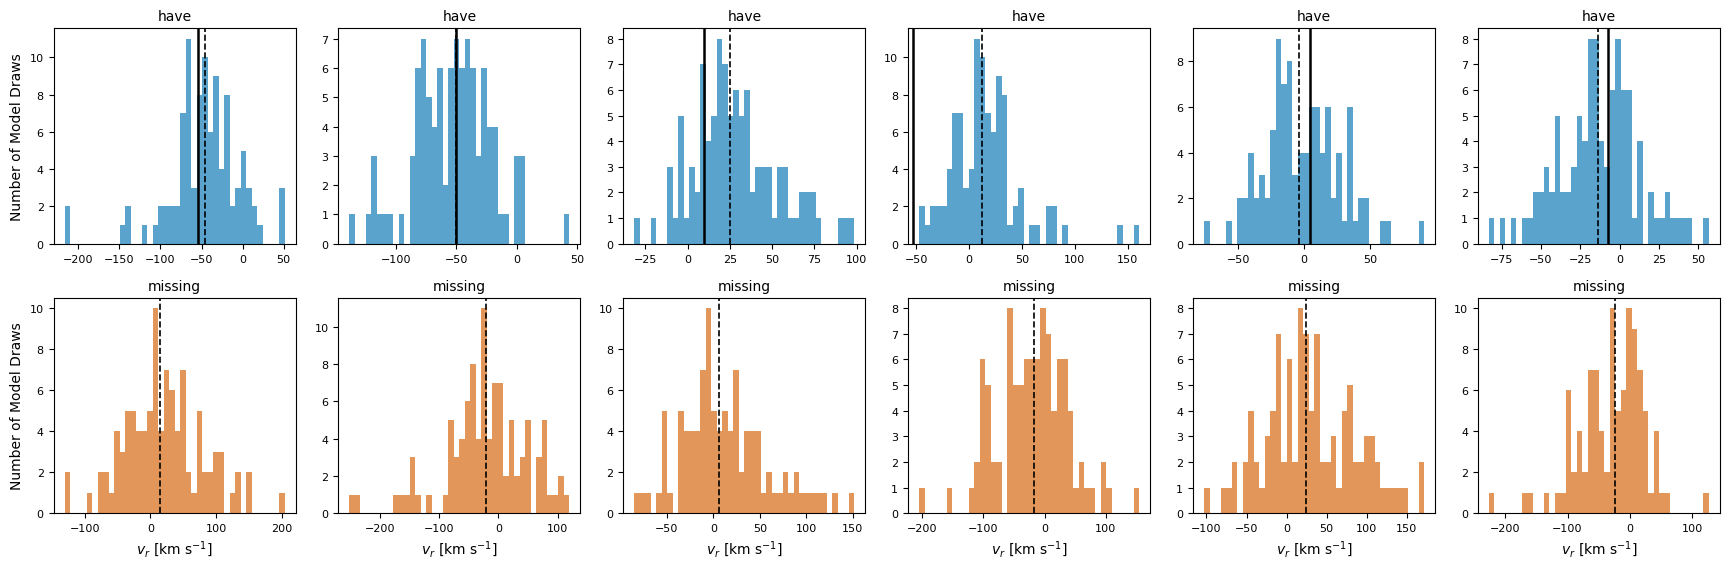

In [20]:
# =====================================================================
# FIGURE 8 -- per-source imputed v_r posteriors, have and missing
# =====================================================================
@with_fonts('fig8')
def figure_8(pattern=None, n_examples=None, bins=None, seed=None, save=True):
    tag = imp_tag(FIG8_PATTERN if pattern is None else pattern)
    n_examples = FIG8_N_EXAMPLES if n_examples is None else n_examples
    bins = FIG8_BINS if bins is None else bins
    seed = FIG8_SEED if seed is None else seed

    blocks = {fl: target_arrays(tag, fl) for fl in ('have', 'missing')}
    avail = [fl for fl in ('have', 'missing')
             if blocks[fl][0] is not None and blocks[fl][0].shape[0] > 0]
    if not avail:
        raise RuntimeError(f'[{tag}] no data for either flavour')

    rng = np.random.default_rng(seed)
    nr = len(avail)
    fig, axes = plt.subplots(nr, n_examples, squeeze=False,
                             figsize=(2.9 * n_examples, 2.9 * nr))
    for r, fl in enumerate(avail):
        dr, tr, _ = blocks[fl]
        idx = rng.permutation(dr.shape[0])[:n_examples]
        for k, i in enumerate(idx):
            ax = axes[r][k]
            ax.hist(dr[i], bins=bins, histtype='stepfilled',
                    color='#0072B2' if fl == 'have' else '#D55E00',
                    alpha=0.65, **hist_kw())
            if tr is not None:
                ax.axvline(tr[i], color='k', lw=1.8)          # Gaia measurement
            ax.axvline(np.median(dr[i]), color='k', lw=1.2, ls='--')
            if SHOW_PANEL_TITLES:
                ax.set_title(f'{fl}', **fkw('panel_title'))
            tick_fontsize(ax)
            if k == 0:
                ax.set_ylabel(count_ylabel('Model Draws'), **fkw('axis_label'))
            if r == nr - 1:
                ax.set_xlabel(tex(IMP_TARGET), **fkw('axis_label'))
        for k in range(len(idx), n_examples):
            axes[r][k].axis('off')

    _suptitle(fig, f'{short(IMP_TARGET)} | {LABEL[tag]} | per-source posteriors '
                   f'(solid = truth where it exists, dashed = median)', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, f'fig08_persource_{file_tag(IMP_TARGET)}_{tag}')
    else:
        plt.show()
    return fig


_ = figure_8()

In [21]:
# =====================================================================
# C3. Skill sweep  (Figure 9)
# =====================================================================
# skill = 1 - RMS(estimate - truth) / RMS(c - truth), where c is the best
# constant guess. Skill = 0 means the conditioning bought nothing over a
# constant; < 0 means the model does worse than a constant.
#
# The baseline is PER PATTERN: the subsets are pattern-exact, so each pattern
# selects a different set of sources and c is recomputed from that subset's own
# truth. Skill is therefore comparable across patterns as a fraction of the
# achievable; the raw RMS values are not.
#
# Only the `have` flavour appears here -- `missing` sources have no truth, so
# no error and no skill can be formed for them.
SKILL_RNG = np.random.default_rng(FIG9_RNG_SEED)


def _wrap180(d):
    return (np.asarray(d, dtype=np.float64) + 180.0) % 360.0 - 180.0


def _best_constant_angle(tr, p, n_grid=1440):
    """The constant angle minimising sum |wrap(c - t)|^p.

    On a line the p=1 minimiser is the median and p=2 the mean, both closed
    form. On a circle neither is, and the arithmetic median of angles
    straddling the seam is not even on the right side of the sky, so this
    minimises directly on a 0.25 deg grid with a local refinement.
    """
    tr = np.asarray(tr, dtype=np.float64)
    g = np.linspace(0.0, 360.0, n_grid, endpoint=False)
    d = _wrap180(g[:, None] - tr[None, :])
    cost = np.abs(d).sum(1) if p == 1 else (d ** 2).sum(1)
    k = int(np.argmin(cost))
    fine = g[k] + np.linspace(-360.0 / n_grid, 360.0 / n_grid, 201)
    d = _wrap180(fine[:, None] - tr[None, :])
    cost = np.abs(d).sum(1) if p == 1 else (d ** 2).sum(1)
    return float(fine[int(np.argmin(cost))] % 360.0)


def _rms(e):
    e = np.asarray(e, dtype=np.float64).ravel()
    return float(np.sqrt(np.mean(e ** 2))) if e.size else np.nan


def case_metrics(draws, truth, circular=False):
    if truth.size == 0:
        return {}
    if circular:
        d = _wrap180(draws - truth[:, None])
        e_med, e_mean = np.median(d, axis=1), d.mean(axis=1)
        c_med, c_mean = _best_constant_angle(truth, 1), _best_constant_angle(truth, 2)
        b_med, b_mean = _wrap180(c_med - truth), _wrap180(c_mean - truth)
    else:
        e_med = np.median(draws, axis=1) - truth
        e_mean = draws.mean(axis=1) - truth
        c_med, c_mean = float(np.median(truth)), float(np.mean(truth))
        b_med, b_mean = c_med - truth, c_mean - truth

    r_med, r_mean = _rms(e_med), _rms(e_mean)
    r_bmed, r_bmean = _rms(b_med), _rms(b_mean)
    return dict(rms_median=r_med, rms_mean=r_mean,
                rms_base_median=r_bmed, rms_base_mean=r_bmean,
                skill_median=1.0 - r_med / r_bmed if r_bmed else np.nan,
                skill_mean=1.0 - r_mean / r_bmean if r_bmean else np.nan,
                circular=bool(circular))

def bootstrap_skill(draws, truth, n_boot=None, ci=None, seed=None):
    """Percentile interval on skill = 1 - RMS(mean draw - truth) / RMS(mean(truth) - truth),
    resampling SOURCES with replacement. Model RMS and baseline are recomputed
    on the same resample, so their correlation is respected. Linear features only."""
    n_boot = FIG9_N_BOOT if n_boot is None else n_boot
    ci = FIG9_CI if ci is None else ci
    rng = np.random.default_rng(FIG9_RNG_SEED if seed is None else seed)
    est = draws.mean(axis=1)                        # per-source posterior mean
    idx = rng.integers(0, truth.size, size=(n_boot, truth.size))
    t, e = truth[idx], est[idx]                     # (n_boot, n)
    rms_model = np.sqrt(((e - t) ** 2).mean(axis=1))
    rms_base = t.std(axis=1)                        # RMS about the resample's own mean
    skill = 1.0 - rms_model / rms_base
    return tuple(np.percentile(skill, [50 - ci / 2, 50 + ci / 2]))

def build_skill_results(target=None):
    """One row per pattern, for the `have` flavour of one target."""
    target = canon(target or IMP_TARGET)
    circ = WRAP_CIRCULAR and target in CIRCULAR_FEATURES
    rows = []
    for tag in TAGS:
        e = BY.get((tag, 'have'))
        if e is None:
            continue
        dr, tr, blk = target_arrays(tag, 'have', target)
        if dr is None or tr is None or tr.size == 0:
            continue
        cond = cond_features_of(tag)
        row = dict(target=target, tag=tag, n_cond=len(cond),
                   label=imp_label(cond), label_tex=imp_label(cond, symbols=True),
                   status=e.get('status', '?'), n=int(tr.size))
        row.update(case_metrics(dr, tr, circular=circ))
        if FIG9_N_BOOT and not circ:
            row['skill_lo'], row['skill_hi'] = bootstrap_skill(dr, tr)
        row['is_full'] = row['n'] >= FIG9_N_EXPECTED
        rows.append(row)
        gc.collect()
    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit('no usable cases -- check IMP_SAMPLE_DIR')
    return df.sort_values(['n_cond', 'tag']).reset_index(drop=True)


SKILL = build_skill_results()
print(f'{len(SKILL)} patterns with a usable "have" block')
_inc = SKILL.loc[~SKILL['is_full']]
if len(_inc):
    print(f'{len(_inc)} subset(s) hold fewer than {FIG9_N_EXPECTED} sources '
          f'(drawn in orange):')
    for _r in _inc.itertuples():
        print(f'    {_r.label:<32} n={_r.n}   status={_r.status}')

18 patterns with a usable "have" block


In [22]:
# =====================================================================
# C4. Point spreading and label placement  (Figure 9)
# =====================================================================
def _skill_spread(x, y, how=None):
    """Offsets separating points that share an x. 'even' is deterministic:
    within each n_cond, points are ordered by y and spread over a width that
    grows with the count. Cosmetic; it carries no information."""
    how = FIG9_X_SPREAD if how is None else how
    x = np.asarray(x, dtype=np.float64)
    if how == 'none' or x.size == 0:
        return np.zeros_like(x)
    if how == 'jitter':
        return (SKILL_RNG.random(x.size) - 0.5) * 0.18
    off = np.zeros_like(x)
    for v in np.unique(x):
        idx = np.nonzero(x == v)[0]
        if idx.size == 1:
            continue
        order = idx[np.argsort(y[idx])]
        w = min(0.74, 0.16 * idx.size)
        off[order] = np.linspace(-w / 2, w / 2, idx.size)
    return off


def _skill_place_labels(ax, xs, ys, texts, fontsize=6.5):
    """Greedy label placement in axes-fraction space.

    matplotlib has no collision handling and adjustText is not a dependency
    here, so this tries a short list of offsets per label and takes the first
    that does not overlap one already placed. If every candidate collides the
    first is used, exactly as an un-decluttered plot would have done.
    """
    tf = ax.transLimits.transform
    placed = []
    ch_w, ch_h = 0.0092 * fontsize / 6.5, 0.038
    for i in np.argsort(-np.asarray(ys, dtype=float)):
        fx, fy = tf((xs[i], ys[i]))
        # Width from the RENDERED length: '$G_{BP}$' is eight characters of
        # source and four of ink, and using the source length reserves so much
        # room that every candidate collides.
        vis = re.sub(r'\\[a-zA-Z]+|[${}\\^_]', '', texts[i])
        w, h = ch_w * max(len(vis), 1) * 1.15, ch_h
        # Right of the point first, then left, at a growing vertical offset.
        # Anything leaving the axes is rejected: a label half off the figure is
        # worse than an overlapping one.
        cands = [(sx, dy) for dy in (-h / 2, 0.012, -h - 0.012, 0.034,
                                     -h - 0.034, 0.058, -h - 0.058, 0.082,
                                     -h - 0.082, 0.108, -h - 0.108)
                 for sx in (0.012, -w - 0.012)]
        box = None
        for dx, dy in cands:
            b = (fx + dx, fy + dy, fx + dx + w, fy + dy + h)
            if not (0.004 < b[0] and b[2] < 0.996
                    and 0.004 < b[1] and b[3] < 0.996):
                continue
            if not any(b[0] < p[2] and p[0] < b[2] and
                       b[1] < p[3] and p[1] < b[3] for p in placed):
                box = b
                break
        if box is None:
            dx, dy = 0.012, -h / 2
            x0 = min(fx + dx, 0.996 - w)
            y0 = min(max(fy + dy, 0.004), 0.996 - h)
            box = (x0, y0, x0 + w, y0 + h)
        placed.append(box)
        far = abs(box[0] - fx) > 0.05 or abs(box[1] + h / 2 - fy) > 0.05
        ax.annotate(texts[i], xy=(xs[i], ys[i]), xycoords='data',
                    xytext=(box[0], box[1] + h / 2 - 0.004),
                    textcoords='axes fraction', fontsize=fontsize,
                    va='center', ha='left', zorder=5,
                    arrowprops=dict(arrowstyle='-', lw=0.4, color='0.55',
                                    shrinkA=0, shrinkB=2) if far else None)

### Figure 9

Skill against the number of conditioning features, one point per pattern. The
question a reader actually has is not "did this one pattern beat a constant
guess" but "does conditioning on more help, and which features do the work" --
a flat trend with one or two high outliers says the model leans on a couple of
informative features and ignores the rest.

Color is completeness, not sample size: with `n_per_subset` fixed, a
`log10 n` colorbar would span a range too small to see. Teal means the subset
holds the full `n`, orange that it does not; the cell above names the orange
ones.

The horizontal spread within an `n_cond` is cosmetic -- it exists so the
labels can be read.

  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig09_skill_vs_conditioning_RV_95.png


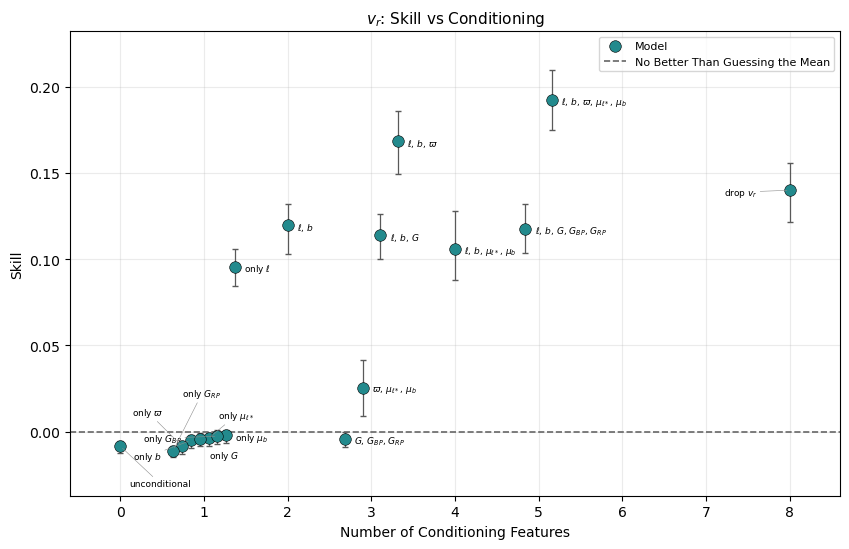

In [23]:
# =====================================================================
# FIGURE 9 -- v_r skill vs number of conditioning features
# =====================================================================
def figure_9(metric=None, annotate=None, save=True):
    metric = FIG9_METRIC if metric is None else metric
    annotate = FIG9_ANNOTATE if annotate is None else annotate
    d = SKILL.loc[SKILL[metric].notna()]
    if d.empty:
        raise RuntimeError(f'no pattern has a usable {metric}')

    fig, ax = plt.subplots(figsize=FIG9_FIGSIZE)
    x = d['n_cond'].to_numpy(float)
    y = d[metric].to_numpy(float)
    full = d['is_full'].to_numpy(bool)
    xs = x + _skill_spread(x, y)
    if metric == 'skill_mean' and {'skill_lo', 'skill_hi'} <= set(d.columns):
        yerr = np.clip(np.vstack([y - d['skill_lo'].to_numpy(float),
                                  d['skill_hi'].to_numpy(float) - y]), 0, None)
        ax.errorbar(xs, y, yerr=yerr, fmt='none', ecolor='0.35',
                    elinewidth=0.9, capsize=2, zorder=2)
    for m, col, lab in ((full, FIG9_COLOR_FULL, f'$n = {FIG9_N_EXPECTED}$'),
                        (~full, FIG9_COLOR_SHORT, f'$n < {FIG9_N_EXPECTED}$')):
        if m.any():
            ax.scatter(xs[m], y[m], s=70, color=col, zorder=3,
                       edgecolor='k', lw=0.4, label='Model')
    ax.axhline(0.0, color='0.4', ls='--', lw=1.2,
               label='No Better Than Guessing the Mean')

    # Limits before decluttering: the label placer works in axes fractions and
    # rejects any box that would leave the axes, so a point sitting exactly on
    # an edge could never be labelled.
    ax.set_xlim(-0.6, IMP_DIM - 0.4)
    pad = 0.10 * (np.ptp(y) or 1.0)
    has_ci = metric == 'skill_mean' and {'skill_lo', 'skill_hi'} <= set(d.columns)
    y_lo = d['skill_lo'].to_numpy(float) if has_ci else y
    y_hi = d['skill_hi'].to_numpy(float) if has_ci else y
    pad = 0.10 * ((np.nanmax(y_hi) - np.nanmin(y_lo)) or 1.0)
    ax.set_ylim(min(np.nanmin(y_lo) - pad, -pad / 2),
                max(np.nanmax(y_hi) + pad, pad / 2))    
    ax.set_xticks(range(0, IMP_DIM))
    if annotate and FIG9_DECLUTTER:
        _skill_place_labels(ax, xs, y, list(d['label_tex']))
    elif annotate:
        for xi, yi, t in zip(xs, y, d['label_tex']):
            ax.annotate(t, (xi, yi), fontsize=6.5, xytext=(4, 3),
                        textcoords='offset points')

    ax.set_xlabel('Number of Conditioning Features')
    ax.set_ylabel({'skill_median': r'skill $= 1 -$ RMS / RMS$_{\rm baseline}$',
                   'skill_mean': 'Skill'}.get(metric, metric))
    if SHOW_PANEL_TITLES:
        ttl = f'{tex(IMP_TARGET, unit=False)}: Skill vs Conditioning'
        if bool(d['circular'].iloc[0]):
            ttl += '  (wrapped)'
        ax.set_title(ttl, fontsize=11)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.25)
    fig.tight_layout()

    if save:
        save_fig(fig, f'fig09_skill_vs_conditioning_{file_tag(IMP_TARGET)}_95')
    else:
        plt.show()
    return fig


_ = figure_9()

### Figure 10

The `have` and `missing` populations by **truth**: no model output enters, so
this bounds how much of any later difference can be attributed to the model
rather than to the two populations simply being different.

The subsets are pattern-exact, so the sources selected depend on the pattern.
This uses the least-conditioned one -- the unconditional pattern -- whose
eligibility cut is the weakest and whose population is therefore closest to the
split as a whole.

  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig10_corner_have_vs_missing_RV_NONE.png


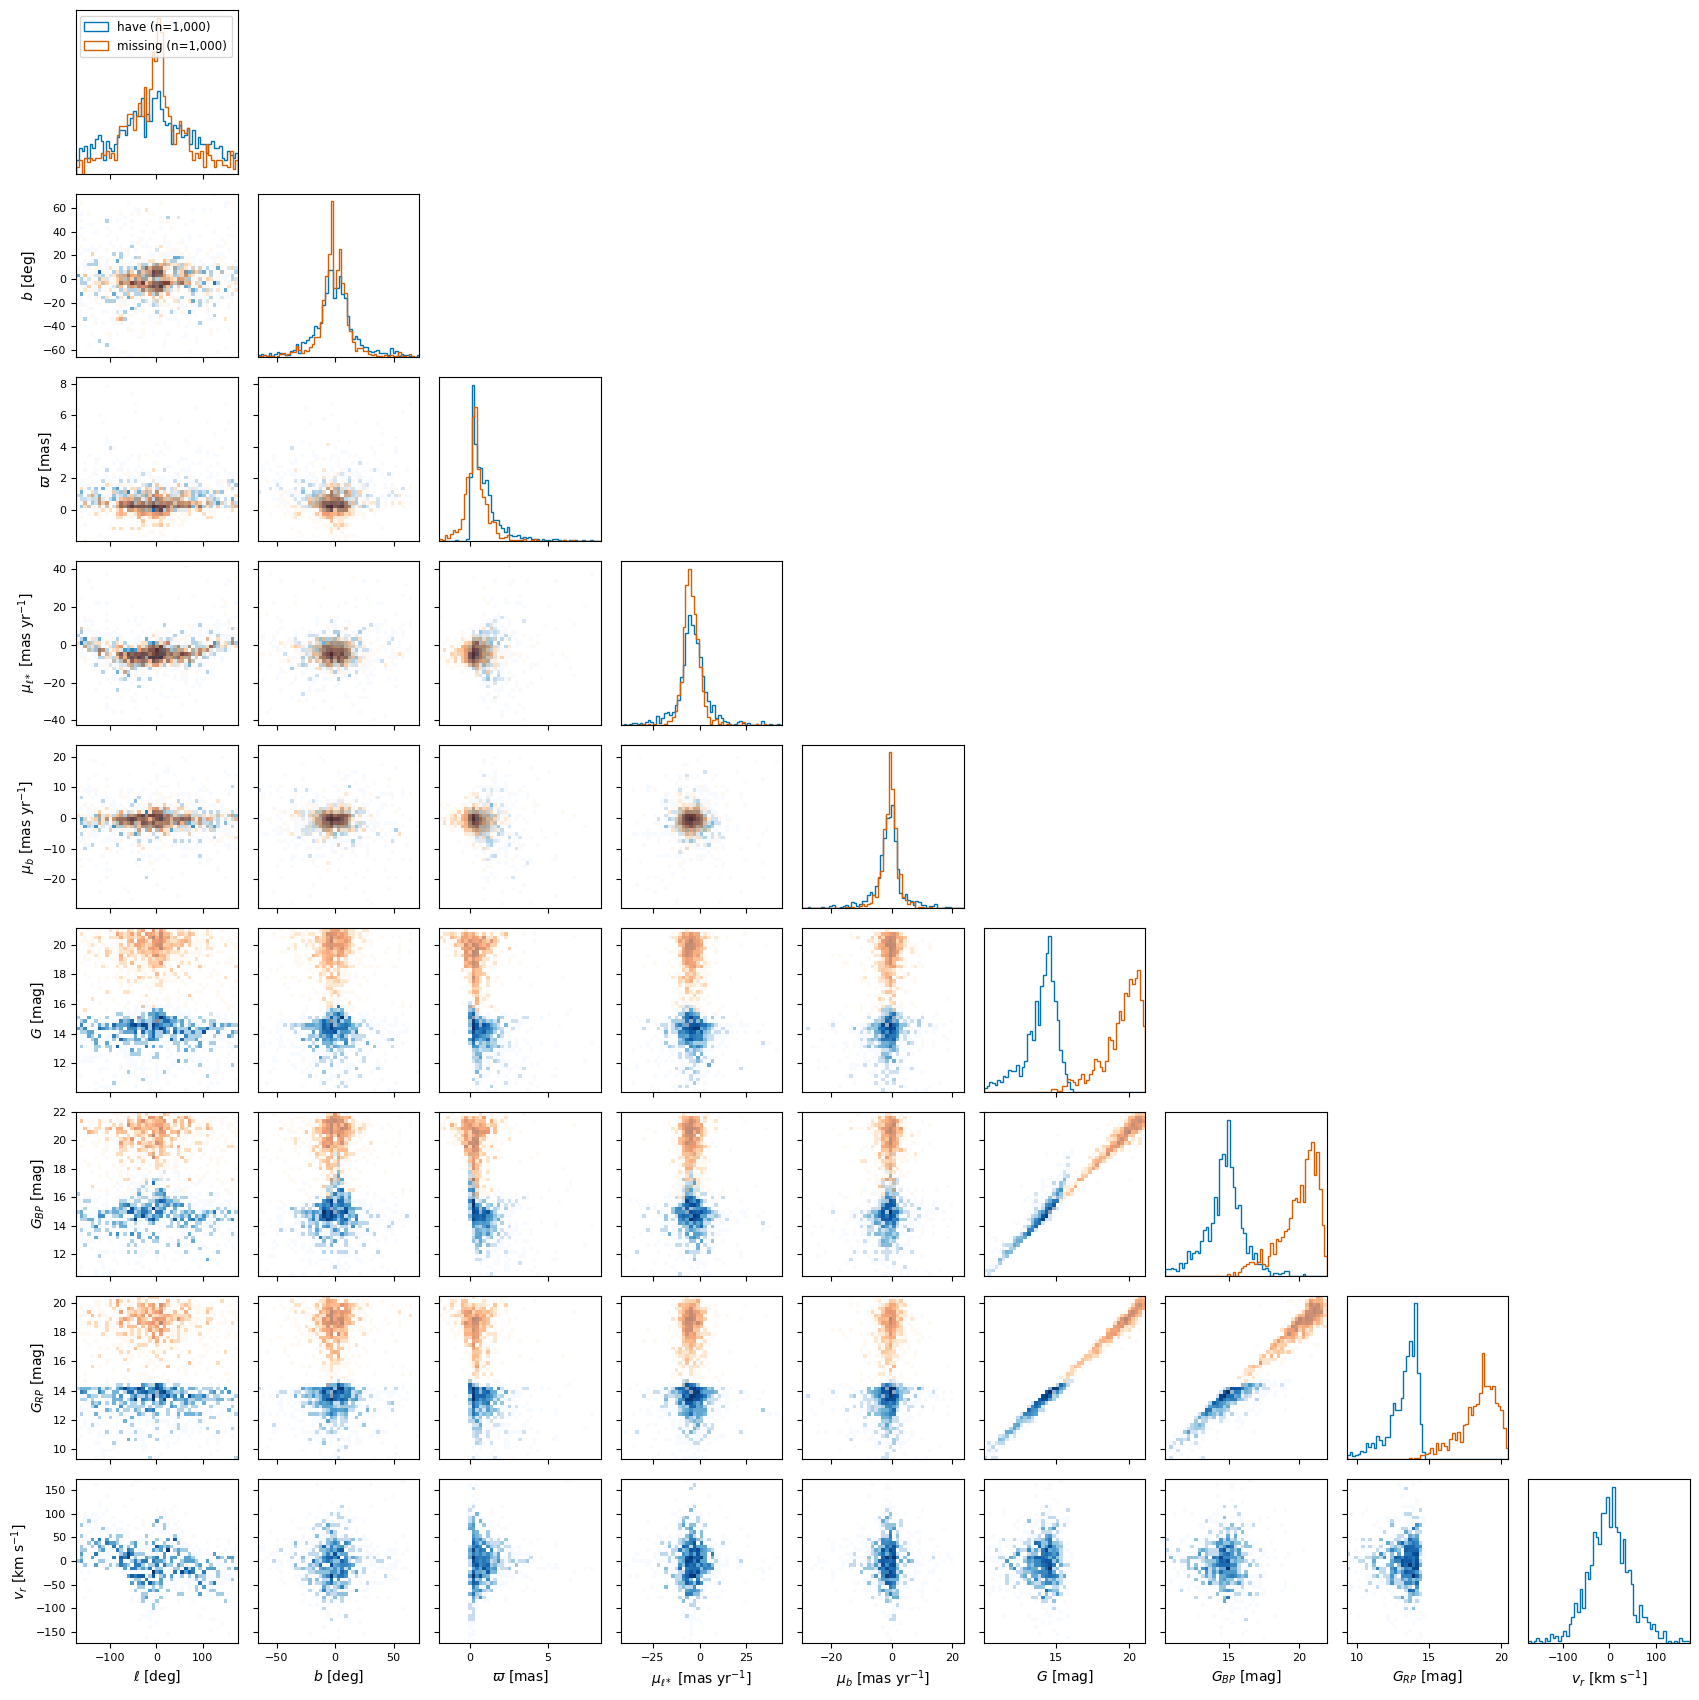

In [24]:
# =====================================================================
# FIGURE 10 -- have vs missing, truth values, corner plot
# =====================================================================
@with_fonts('fig10')
def figure_10(pattern=None, bins=None, save=True):
    tag = imp_tag(FIG10_PATTERN if pattern is None else pattern)
    bins = FIG10_BINS if bins is None else bins
    bh, bm = load_block(tag, 'have'), load_block(tag, 'missing')
    if bh is None or bm is None:
        raise RuntimeError(f'[{tag}] need both flavours; have='
                           f'{bh is not None}, missing={bm is not None}')
    # Galactic longitude is wrapped to (-180, 180] so the bulge sits in the
    # middle of the l panels rather than split across both edges, matching
    # Figures 2, 3 and 4. Section C is independent of Section A, so it does not
    # inherit l_display() and reproduces it here. Copy first: load_block()
    # caches its blocks and wrapping in place would mutate the cache.
    data = {'have': bh['truth'].copy(), 'missing': bm['truth'].copy()}
    if WRAP_L_TO_CENTER_ZERO and 'l' in IMP_F:
        _lj = IMP_F['l']
        for _arr in data.values():
            _arr[:, _lj] = (_arr[:, _lj] + 180.0) % 360.0 - 180.0
    # Drop features that are entirely absent in EVERY population, and say so.
    keep, dropped = [], []
    for f in IMP_FEATURES:
        j = IMP_F[f]
        if any(np.isfinite(a[:, j]).sum() > 10 for a in data.values()):
            keep.append(f)
        else:
            dropped.append(short(f))
    if dropped:
        print(f'  skipping all-absent features {dropped}')
    n = len(keep)

    lims = {}
    for f in keep:
        pool = np.concatenate([a[np.isfinite(a[:, IMP_F[f]]), IMP_F[f]]
                               for a in data.values()])
        lo, hi = np.percentile(pool, [0.5, 99.5])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = lo - 1, hi + 1
        lims[f] = (lo, hi)

    fig, axes = plt.subplots(n, n, squeeze=False,
                             figsize=(FIG10_SCALE * n, FIG10_SCALE * n))
    for r, fy in enumerate(keep):
        for c, fx in enumerate(keep):
            ax = axes[r][c]
            if c > r:
                ax.axis('off')
                continue
            for k, (lab, arr) in enumerate(data.items()):
                col = FIG10_COLORS[k % len(FIG10_COLORS)]
                if r == c:
                    v = arr[np.isfinite(arr[:, IMP_F[fx]]), IMP_F[fx]]
                    if v.size > 5:
                        ax.hist(v, bins=bins, range=lims[fx], histtype='step',
                                density=True, color=col, lw=1.7,
                                label=f'{lab} (n={v.size:,})')
                    ax.set_yticks([])
                    if r == 0:
                        ax.legend(**fkw('legend'))
                else:
                    m = (np.isfinite(arr[:, IMP_F[fx]])
                         & np.isfinite(arr[:, IMP_F[fy]]))
                    if m.sum() > 20:
                        ax.hist2d(arr[m, IMP_F[fx]], arr[m, IMP_F[fy]], bins=45,
                                  range=[lims[fx], lims[fy]], norm=LogNorm(),
                                  cmap='Blues' if k == 0 else 'Oranges',
                                  alpha=1.0 if k == 0 else 0.55)
                    ax.set_ylim(*lims[fy])
            ax.set_xlim(*lims[fx])
            if r == n - 1:
                ax.set_xlabel(tex(fx), **fkw('axis_label'))
            else:
                ax.set_xticklabels([])
            if c == 0 and r > 0:
                ax.set_ylabel(tex(fy), **fkw('axis_label'))
            elif c != 0:
                ax.set_yticklabels([])
            tick_fontsize(ax)

    _suptitle(fig, f'{short(IMP_TARGET)} | {LABEL[tag]}: the two populations '
                   f'overlaid (blue = have, orange = missing)', y=1.005)
    fig.tight_layout()
    if save:
        save_fig(fig, f'fig10_corner_have_vs_missing_'
                      f'{file_tag(IMP_TARGET)}_{tag}')
    else:
        plt.show()
    return fig


_ = figure_10()

In [25]:
# =====================================================================
# FIGURE 10b -- imputed v_r, have vs missing, all draws, over the have data
# =====================================================================
def _vr_summary(name, x, n_src):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    print(f'  {name:<16s}{n_src:>8,d}{x.size:>10,d}{x.mean():>9.2f}'
          f'{x.std():>9.2f}{q50:>9.2f}{q16:>9.2f}{q84:>9.2f}')


@with_fonts('fig10b')
def figure_10b(pattern=None, bins=None, clip_percentiles=None, save=True):
    tag = imp_tag(FIG10B_PATTERN if pattern is None else pattern)
    bins = FIG10B_BINS if bins is None else bins
    clip = (FIG10B_CLIP_PERCENTILES if clip_percentiles is None
            else clip_percentiles)

    dr_h, tr_h, _ = target_arrays(tag, 'have')
    dr_m, _, _ = target_arrays(tag, 'missing')
    if dr_h is None or dr_m is None:
        raise RuntimeError(f'[{tag}] need both flavours; have='
                           f'{dr_h is not None}, missing={dr_m is not None}')

    # target_arrays has already dropped any source with a non-finite draw (and,
    # for 'have', a non-finite truth), so data and 'have' model are the same
    # sources, row for row.
    samples = {'data':    tr_h,
               'have':    dr_h.ravel(),
               'missing': dr_m.ravel()}
    n_src = {'data': tr_h.size, 'have': dr_h.shape[0], 'missing': dr_m.shape[0]}
    n_draws = {'have': dr_h.shape[1], 'missing': dr_m.shape[1]}

    # One set of edges for all three: the union of each sample's own range.
    rng_lo, rng_hi = zip(*(np.percentile(v, clip) for v in samples.values()))
    edges = np.linspace(min(rng_lo), max(rng_hi), bins + 1)

    fig, ax = plt.subplots(figsize=FIG10B_FIGSIZE, constrained_layout=True)
    ax.hist(samples['data'], bins=edges, color=FIG10B_COLORS['data'],
            label=FIG10B_LABELS['data'])
    for fl in ('have', 'missing'):
        v = samples[fl]
        # Divide by n_draws so the curve is in sources, not draws.
        ax.hist(v, bins=edges, weights=np.full(v.size, 1.0 / n_draws[fl]),
                histtype='step', lw=FIG10B_LW, color=FIG10B_COLORS[fl],
                label=FIG10B_LABELS[fl])
    ax.set_xlim(edges[0], edges[-1])
    ax.set_xlabel(FIG10B_XLABEL, **fkw('axis_label'))
    ax.set_ylabel(FIG10B_YLABEL, **fkw('axis_label'))
    tick_fontsize(ax)
    ax.legend(frameon=False, **fkw('legend'))

    # --- numbers for the text ---------------------------------------------
    print(f'Figure 10b  |  target {IMP_TARGET}  |  pattern {tag} ({LABEL[tag]})')
    print(f'  draws per source: have {n_draws["have"]}, '
          f'missing {n_draws["missing"]}')
    print(f'  bins: {bins} on [{edges[0]:.1f}, {edges[-1]:.1f}] '
          f'{PLAIN_UNITS[IMP_TARGET]}')
    print(f"  {'':<16s}{'sources':>8s}{'values':>10s}{'mean':>9s}{'std':>9s}"
          f"{'median':>9s}{'p16':>9s}{'p84':>9s}")
    for k in ('data', 'have', 'missing'):
        _vr_summary(k if k == 'data' else f'{k} model', samples[k], n_src[k])
    for k, v in samples.items():
        out = int(((v < edges[0]) | (v > edges[-1])).sum())
        if out:
            print(f'  {k}: {out:,} of {v.size:,} values ({100 * out / v.size:.2f}%)'
                  f' fall outside the plotted range')

    if save:
        save_fig(fig, f'fig10b_draws_have_vs_missing_{file_tag(IMP_TARGET)}_{tag}')
    else:
        plt.show()
    return fig


#_ = figure_10b()

---

# Section D -- TARP and RMSE

Figures 11 through 17. All seven read the HDF5 output of the TARP/RMSE eval
script, one file per dataset: `<RUN_TAG>_TARP_RMSE_<dataset>_<timestamp>.h5`.

**Datasets.** `test` is the held-out split; `omega_cen_all` is every $\omega$
Cen member; `omega_cen_not_A` is the subset that was in neither the training
nor the validation partition, so it carries no train/val contamination.

**Classes.** A TARP curve needs sources that have every feature it is asking
about, so the curves are split by what a source actually has measured: (a)
$\ell, b, G$ only, (b) those plus $G_{BP}, G_{RP}$, (c) those plus the
astrometry, (d) everything including $v_r$. A pattern conditioning on something
outside a class cannot use it, so a heavily-conditioned pattern shows only the
later classes.

This section is the only part of the paper drawn on a grid, so its rcParams are
applied with `plt.rc_context` rather than globally -- Figures 2 to 10 have no
grid and a framed legend, and a global `rcParams.update` would silently change
them if the notebook is re-run out of order.

It is independent of A, B and C: it defines its own `FEATURES` from the HDF5.

In [26]:
# =====================================================================
# D1. Find one HDF5 file per dataset and read everything in
# =====================================================================
# The files are small (one TARP curve is N_draws + 2 points), so everything is
# read once into
# plain dicts and a DataFrame, and the handles are closed.
RESULT_DIR = Path(RESULT_DIR).expanduser()
if not RESULT_DIR.is_dir():
    raise FileNotFoundError(f'RESULT_DIR does not exist: {RESULT_DIR}')

_found = {}                       # dataset -> (timestamp, path)
_glob = (f'{TARP_RUN_TAG}_TARP_RMSE_*.h5' if TARP_RUN_TAG
         else '*_TARP_RMSE_*.h5')
for _p in sorted(RESULT_DIR.glob(_glob)):
    _stem = _p.name[:-3].split('_TARP_RMSE_', 1)[1]      # <dataset>_<timestamp>
    for _ds in DATASETS:
        if _stem.startswith(_ds + '_'):
            _ts = _stem[len(_ds) + 1:]
            if TARP_TIMESTAMP in (None, _ts):
                if _ds not in _found or _ts > _found[_ds][0]:
                    _found[_ds] = (_ts, _p)

if not _found:
    raise FileNotFoundError(
        f'no {_glob} for {DATASETS} in {RESULT_DIR}'
        + (f' at TARP_TIMESTAMP={TARP_TIMESTAMP}' if TARP_TIMESTAMP else ''))

print(f'{RESULT_DIR}\n')
for _ds in DATASETS:
    print(f'  {_ds:<16s} '
          + (_found[_ds][1].name if _ds in _found
             else 'MISSING -- its panels will be left blank'))
DATASETS = [d for d in DATASETS if d in _found]

TARP = {}       # (dataset, pattern, class) -> dict(ecp, cred, n, status, ...)
RMSE_ROWS = []  # one row per (dataset, pattern, feature)
META = {}       # dataset -> file-level attributes


def _attr(obj, key, default=None):
    """Attribute, JSON-decoded when it was stored as a JSON string."""
    if key not in obj.attrs:
        return default
    v = obj.attrs[key]
    if isinstance(v, bytes):
        v = v.decode()
    if isinstance(v, str):
        try:
            return json.loads(v)
        except (ValueError, TypeError):
            return v
    return v


for _ds in DATASETS:
    _ts, _path = _found[_ds]
    with h5py.File(_path, 'r') as h5:
        meta = dict(timestamp=_ts, path=_path, status=_attr(h5, 'status'),
                    model=_attr(h5, 'model_name'),
                    features=_attr(h5, 'feature_names'),
                    model_columns=_attr(h5, 'model_columns'),
                    classes=_attr(h5, 'classes'),
                    patterns=_attr(h5, 'pattern_names'),
                    n_draws=int(_attr(h5, 'n_draws', 0)),
                    rk4_steps=int(_attr(h5, 'rk4_steps', 0)),
                    n_sources_target=int(_attr(h5, 'n_sources_target', 0)),
                    min_sources=int(_attr(h5, 'min_sources', 0)),
                    n_in_dataset=int(_attr(h5, 'n_sources_in_dataset', 0)),
                    reference_rule=_attr(h5, 'reference_rule'))
        META[_ds] = meta
        if meta['status'] != 'complete':
            print(f'WARNING: {_ds} has status={meta["status"]!r}; the run may '
                  f'have been interrupted.')

        feats, mcols = meta['features'], meta['model_columns']
        if RMSE_CLASSES is None:
            tables = {None: h5['rmse_table']}
        elif 'rmse_class_table' not in h5:
            raise KeyError(f'{_path.name} has no rmse_class_table/ -- it was '
                           'written before the class-pool RMSE update. '
                           'Re-run the eval or set RMSE_CLASSES = None.')
        else:
            tables = {c: h5[f'rmse_class_table/{c}'] for c in RMSE_CLASSES}
        for i, pname in enumerate(meta['patterns']):
            grp = h5[f'patterns/{pname}']
            cond = _attr(grp, 'cond_features', [])
            for cls in meta['classes']:
                tg = grp[f'tarp/{cls}']
                rec = dict(status=_attr(tg, 'status'),
                           n=int(_attr(tg, 'n_sources', 0)),
                           n_draws=int(_attr(tg, 'n_draws', 0)))
                if rec['status'] == 'ok':
                    rec['cred'] = np.asarray(tg['credibility'][()], float)
                    rec['ecp'] = np.asarray(tg['ecp'][()], float)
                TARP[(_ds, pname, cls)] = rec

            # RMSE: the nine physical features, then the two normalized l
            # components, once per class. NaN where the feature is
            # conditioned on, outside the class, or the curve was skipped.
            for cls_r, tbl in tables.items():
                for j, f in enumerate(feats):
                    RMSE_ROWS.append(dict(
                        dataset=_ds, pattern=pname, cls=cls_r, feature=f,
                        space='phys', n_cond=len(cond), cond=','.join(cond),
                        rmse=float(tbl['rmse_phys_model'][i, j]),
                        baseline=float(tbl['rmse_phys_baseline'][i, j]),
                        n=int(tbl['n_phys'][i, j])))
                for k, c in enumerate(mcols):
                    if c not in ('cos_l', 'sin_l'):
                        continue
                    RMSE_ROWS.append(dict(
                        dataset=_ds, pattern=pname, cls=cls_r, feature=c,
                        space='norm', n_cond=len(cond), cond=','.join(cond),
                        rmse=float(tbl['rmse_norm_model'][i, k]),
                        baseline=float(tbl['rmse_norm_baseline'][i, k]),
                        n=int(tbl['n_norm'][i, k])))

RMSE = pd.DataFrame(RMSE_ROWS)
RMSE['skill'] = 1.0 - RMSE['rmse'] / RMSE['baseline']

_m = META[DATASETS[0]]
FEATURES = list(_m['features'])
CLASSES = list(_m['classes'])
PATTERN_NAMES = list(_m['patterns'])
COND_OF = {r.pattern: (r.cond.split(',') if r.cond else [])
           for r in RMSE.drop_duplicates('pattern').itertuples()}

# Class labels are built from SYMBOL, so the \ell convention reaches them too.
def _cls_label(prefix, feats, plus=False):
    body = r',\,'.join(sym(f) for f in feats)
    return f'{prefix} $' + (r'+\,' if plus else '') + body + '$'


CLASS_LABEL = {
    'a_pos_G':          _cls_label('(a)', ['l', 'b', 'phot_g_mean_mag']),
    'b_pos_G_BP_RP':    _cls_label('(b)', ['phot_bp_mean_mag',
                                           'phot_rp_mean_mag'], plus=True),
    'c_pos_phot_astro': _cls_label('(c)', ['parallax', 'pml', 'pmb'], plus=True),
    'd_all_with_RV':    _cls_label('(d)', ['radial_velocity'], plus=True),
}

print(f'\nmodel     : {_m["model"]}')
for _ds in DATASETS:                  # runs can differ, e.g. in n_draws
    _mm = META[_ds]
    print(f'run size  : {_ds:<16s} {_mm["n_sources_target"]} sources x '
          f'{_mm["n_draws"]} draws, {_mm["rk4_steps"]} RK4 steps, '
          f'min {_mm["min_sources"]}   ({_mm["timestamp"]})')
print('RMSE pool : ' + (f'classes {RMSE_CLASSES}' if RMSE_CLASSES
                        else 'pattern (general / RV pool)'))
print(f'{len(PATTERN_NAMES)} patterns, {len(CLASSES)} classes, '
      f'{len(DATASETS)} datasets')
print(f'RMSE rows : {len(RMSE)} ({int(RMSE["rmse"].notna().sum())} finite)')

for _name in (FIG11_PATTERN, FIG12_PATTERN, FIG13_PATTERN, *FIG14_PATTERNS):
    if _name not in PATTERN_NAMES:
        raise KeyError(f'pattern {_name!r} is not in this run.\n'
                       f'available: {PATTERN_NAMES}')

/Users/John/Documents/Gaia_CFM_Code/tarp_rmse_results

  test             RMSE_ON_CLASSES_TARP_RMSE_test_2026-09-24_12-01.h5
  omega_cen_all    RMSE_ON_CLASSES_TARP_RMSE_omega_cen_all_2026-09-24_12-01.h5
  omega_cen_not_A  RMSE_ON_CLASSES_TARP_RMSE_omega_cen_not_A_2026-09-24_12-01.h5

model     : POS_PM_mask_set_setA_CUSTOM_2026-07-10_15-01-16_mask_train_mask_val_MSE_vHD512_SIGMA1_0e-08_GELU_lr1_0e-04_wd0_0e+00_layers8_MP85_ADD_SET_VALACUMVAL_10
run size  : test             1000 sources x 200 draws, 50 RK4 steps, min 50   (2026-09-24_12-01)
run size  : omega_cen_all    1000 sources x 200 draws, 50 RK4 steps, min 50   (2026-09-24_12-01)
run size  : omega_cen_not_A  1000 sources x 200 draws, 50 RK4 steps, min 50   (2026-09-24_12-01)
RMSE pool : classes ['a_pos_G', 'b_pos_G_BP_RP', 'c_pos_phot_astro', 'd_all_with_RV']
47 patterns, 4 classes, 3 datasets
RMSE rows : 6204 (1398 finite)


In [27]:
# =====================================================================
# D2. TARP machinery  (Figures 11, 12, 13, 14)
# =====================================================================
WHY = {'not_applicable': 'pattern conditions on a\nfeature outside this class',
       'empty': 'every class feature\nis conditioned on',
       'skipped_lt_min': 'too few sources'}


def _band(ax, cred, n, color):
    """+-3 sigma pointwise binomial scatter expected from a correct model."""
    if not SHOW_BAND or cred is None or n < 1:
        return
    sig = np.sqrt(np.clip(cred * (1.0 - cred), 0, None) / n)
    ax.fill_between(cred, -3 * sig, 3 * sig, color=color, alpha=BAND_ALPHA,
                    lw=0, zorder=0)


def _tarp_column(ax_top, ax_bot, pattern, ds):
    """Curves for one (pattern, dataset): coverage on top, deviation below."""
    ax_top.plot([0, 1], [0, 1], color='0.55', lw=0.9, ls='--', zorder=1)
    ax_bot.axhline(0.0, color='0.55', lw=0.9, ls='--', zorder=1)

    drawn, cred, ns = 0, None, []
    for cls in CLASSES:
        rec = TARP.get((ds, pattern, cls))
        if rec is None or rec['status'] != 'ok':
            continue
        c, e, col = rec['cred'], rec['ecp'], CLASS_COLOR[cls]
        ax_top.plot(c, e, color=col, lw=1.6, zorder=3,
                    label=f'{CLASS_LABEL[cls]}')
        ax_bot.plot(c, e - c, color=col, lw=1.6, zorder=3)
        cred = c
        ns.append(rec['n'])
        drawn += 1

    # One band for the panel rather than one per class (four overlaid bands
    # just darken). BAND_N = None uses the smallest n drawn in this panel,
    # i.e. the widest band: omega Cen class pools can fall short of 1000.
    _band(ax_bot, cred, BAND_N or (min(ns) if ns else 0), 'black')

    if drawn == 0:
        # Say why, rather than leaving a blank pair of axes.
        reasons = {TARP[(ds, pattern, cls)]['status'] for cls in CLASSES
                   if (ds, pattern, cls) in TARP}
        why = '; '.join(sorted(WHY.get(r, r) for r in reasons - {'ok'}))
        for ax in (ax_top, ax_bot):
            ax.text(0.5, 0.5, why or 'no curves', transform=ax.transAxes,
                    ha='center', va='center', color='0.45', **fkw('note'))

    ax_top.set_xlim(0, 1)
    ax_top.set_ylim(0, 1)
    ax_top.set_aspect('equal')
    ax_top.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax_top.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax_bot.set_xlim(0, 1)
    return drawn


def _pattern_subtitle(pattern):
    cond = COND_OF.get(pattern, [])
    return 'Unconditional' if not cond else f'{len(cond)}: ' + math(cond)


def short_pattern(p, symbols=True):
    """'uncond', 'drop $\\varpi$', 'only $G$', or the set itself."""
    cond = COND_OF.get(p, [])
    if not cond:
        return 'uncond'
    if len(cond) == len(FEATURES) - 1:
        missing = [f for f in FEATURES if f not in cond][0]
        return 'drop ' + (math(missing) if symbols else short(missing))
    if len(cond) == 1:
        return 'only ' + (math(cond[0]) if symbols else short(cond[0]))
    return math(cond) if symbols else ','.join(short(f) for f in cond)


def _shared_legend(fig, axes_row, ncol_max=4):
    """One entry per class, taking the first n each class appears with."""
    handles, labels = [], []
    for ax in axes_row:
        h, l = ax.get_legend_handles_labels()
        for hi, li in zip(h, l):
            if li not in labels:#if li.split('$n=')[0] not in [x.split('$n=')[0] for x in labels]:
                handles.append(hi)
                labels.append(li)
                print(li)
    if handles:
        fig.legend(handles, labels, loc='lower center',
                   ncol=min(ncol_max, len(handles)),
                   bbox_to_anchor=(0.5, -0.02), **fkw('legend'))

def tarp_n_table(patterns, datasets):
    """Print n for every TARP curve a figure draws, per dataset and class,
    plus a caption-ready line. Returns {pattern: DataFrame}."""
    patterns = [patterns] if isinstance(patterns, str) else list(patterns)
    out = {}
    for pat in patterns:
        tab = pd.DataFrame(
            {f'({c[0]})': [TARP[(ds, pat, c)]['n']
                           if TARP.get((ds, pat, c), {}).get('status') == 'ok'
                           else None for ds in datasets]
             for c in CLASSES},
            index=list(datasets), dtype='Int64').dropna(axis=1, how='all')
        print(f'\nn per TARP curve -- {pat}  ({short_pattern(pat, symbols=False)})')
        print(tab.to_string(na_rep='--'))
        for ds, row in tab.iterrows():
            parts = [f'{c} $n = {int(v)}$' for c, v in row.items() if pd.notna(v)]
            print(f'  {DS_LABEL.get(ds, ds)}: ' + (', '.join(parts) or 'no curves'))
        out[pat] = tab
    return out
@with_fonts('fig11')         # Figures 12 and 13 pass their own key
def plot_tarp_pattern(pattern, save_name=None):
    """2 x 3 grid for ONE pattern: three datasets across, coverage above
    deviation. Figures 11, 12 and 13."""
    fig, axes = plt.subplots(2, 3, figsize=TARP_FIGSIZE, squeeze=False,
                             gridspec_kw=dict(height_ratios=[1.35, 1.0]))
    for k, ds in enumerate(DATASETS):
        _tarp_column(axes[0][k], axes[1][k], pattern, ds)
        axes[0][k].set_title(f'{DS_LABEL.get(ds, ds)}\n',
                             **fkw('panel_title'))
        axes[1][k].set_xlabel('Credibility Level')
    for k in range(len(DATASETS), 3):        # a dataset that was not produced
        for r in (0, 1):
            axes[r][k].axis('off')

    axes[0][0].set_ylabel('Expected Coverage')
    axes[1][0].set_ylabel(r'ECP $-$ Credibility')

    _shared_legend(fig, [axes[0][k] for k in range(len(DATASETS))])
    fig.suptitle(f'TARP -- {_pattern_subtitle(pattern)}',
                 y=0.99, **fkw('suptitle'))
    fig.tight_layout(rect=(0, 0.02, 1, 0.97))
    tarp_n_table(pattern, DATASETS)
    if save_name:
        save_fig(fig, save_name)
    else:
        plt.show()
    return fig


@with_fonts('fig14')
def plot_tarp_compare(patterns, dataset, titles=None, suptitle=None,
                      figsize=None, share_dev=True, save_name=None):
    """Same 2 x n shape, but the columns are PATTERNS rather than datasets.
    Figure 14."""
    if dataset not in DATASETS:
        raise ValueError(f'{dataset!r} not loaded; available: {DATASETS}')
    missing = [p for p in patterns if p not in PATTERN_NAMES]
    if missing:
        raise ValueError(f'not in this run: {missing}')

    n = len(patterns)
    fig, axes = plt.subplots(2, n, figsize=figsize or FIG14_FIGSIZE,
                             squeeze=False,
                             gridspec_kw=dict(height_ratios=[1.35, 1.0]))
    for k, pat in enumerate(patterns):
        _tarp_column(axes[0][k], axes[1][k], pat, dataset)
        axes[0][k].set_title(titles[k] if titles else
                             f'{short_pattern(pat)} ({_pattern_subtitle(pat)})',
                             **fkw('panel_title'))
        axes[1][k].set_xlabel('Credibility Level')

    axes[0][0].set_ylabel('Expected Coverage')
    axes[1][0].set_ylabel(r'ECP $-$ Credibility')

    if share_dev:
        devs = [np.abs(TARP[(dataset, p, c)]['ecp']
                       - TARP[(dataset, p, c)]['cred']).max()
                for p in patterns for c in CLASSES
                if TARP.get((dataset, p, c), {}).get('status') == 'ok']
        lim = (max(devs) * 1.25 if devs else 0.1) or 0.1
        for k in range(n):
            axes[1][k].set_ylim(-lim, lim)

    _shared_legend(fig, [axes[0][k] for k in range(n)])
    band = ''
    tarp_n_table(patterns, DATASETS)
    #fig.suptitle(suptitle or f'TARP -- {DS_LABEL.get(dataset, dataset)}{band}',
    #             fontsize=12, y=0.99)
    fig.tight_layout(rect=(0, 0.02, 1, 0.97))

    if save_name:
        save_fig(fig, save_name)
    else:
        plt.show()
    return fig

### Figures 11, 12 and 13

One conditioning pattern each, three datasets across. The top row is expected
coverage against credibility; the bottom row is the deviation from the
diagonal, with the grey band showing $\pm 3\sqrt{c(1-c)/n}$ at the panel's
own $n$ (or at `BAND_N` when that is set).
A curve on the diagonal means the model is an accurate posterior estimator for
that population.

(a) $\ell,\,b,\,G$
(b) $+\,G_{BP},\,G_{RP}$
(c) $+\,\varpi,\,\mu_{\ell*},\,\mu_b$
(d) $+\,v_r$

n per TARP curve -- unconditional  (uncond)
                  (a)   (b)   (c)   (d)
test             1000  1000  1000  1000
omega_cen_all    <NA>  <NA>  1000  1000
omega_cen_not_A  <NA>  <NA>  1000   781
  Test Set: (a) $n = 1000$, (b) $n = 1000$, (c) $n = 1000$, (d) $n = 1000$
  $\omega$ Cen, All Members: (c) $n = 1000$, (d) $n = 1000$
  $\omega$ Cen, Outside Train/Val: (c) $n = 1000$, (d) $n = 781$
  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig11_tarp_unconditional.png


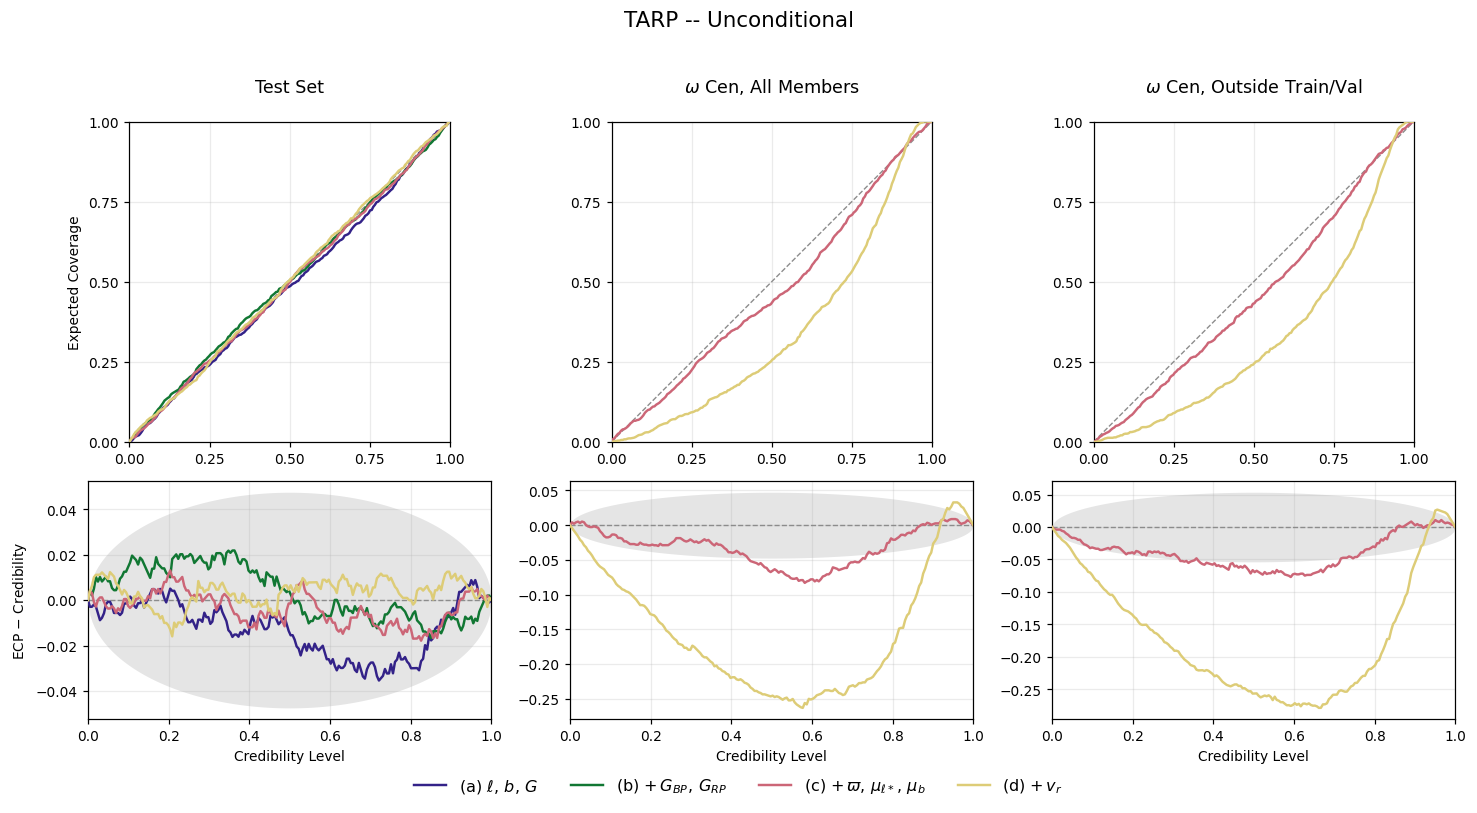

In [28]:
# =====================================================================
# FIGURE 11 -- TARP, unconditional
# =====================================================================
with plt.rc_context(TARP_RC):
    _ = plot_tarp_pattern(FIG11_PATTERN, fonts='fig11',
                          save_name=f'fig11_tarp_{FIG11_PATTERN}')

(a) $\ell,\,b,\,G$
(b) $+\,G_{BP},\,G_{RP}$
(c) $+\,\varpi,\,\mu_{\ell*},\,\mu_b$
(d) $+\,v_r$

n per TARP curve -- sky_position_only  (l,b)
                  (a)   (b)   (c)   (d)
test             1000  1000  1000  1000
omega_cen_all    <NA>  <NA>  1000  1000
omega_cen_not_A  <NA>  <NA>  1000   781
  Test Set: (a) $n = 1000$, (b) $n = 1000$, (c) $n = 1000$, (d) $n = 1000$
  $\omega$ Cen, All Members: (c) $n = 1000$, (d) $n = 1000$
  $\omega$ Cen, Outside Train/Val: (c) $n = 1000$, (d) $n = 781$
  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig12_tarp_sky_position_only.png


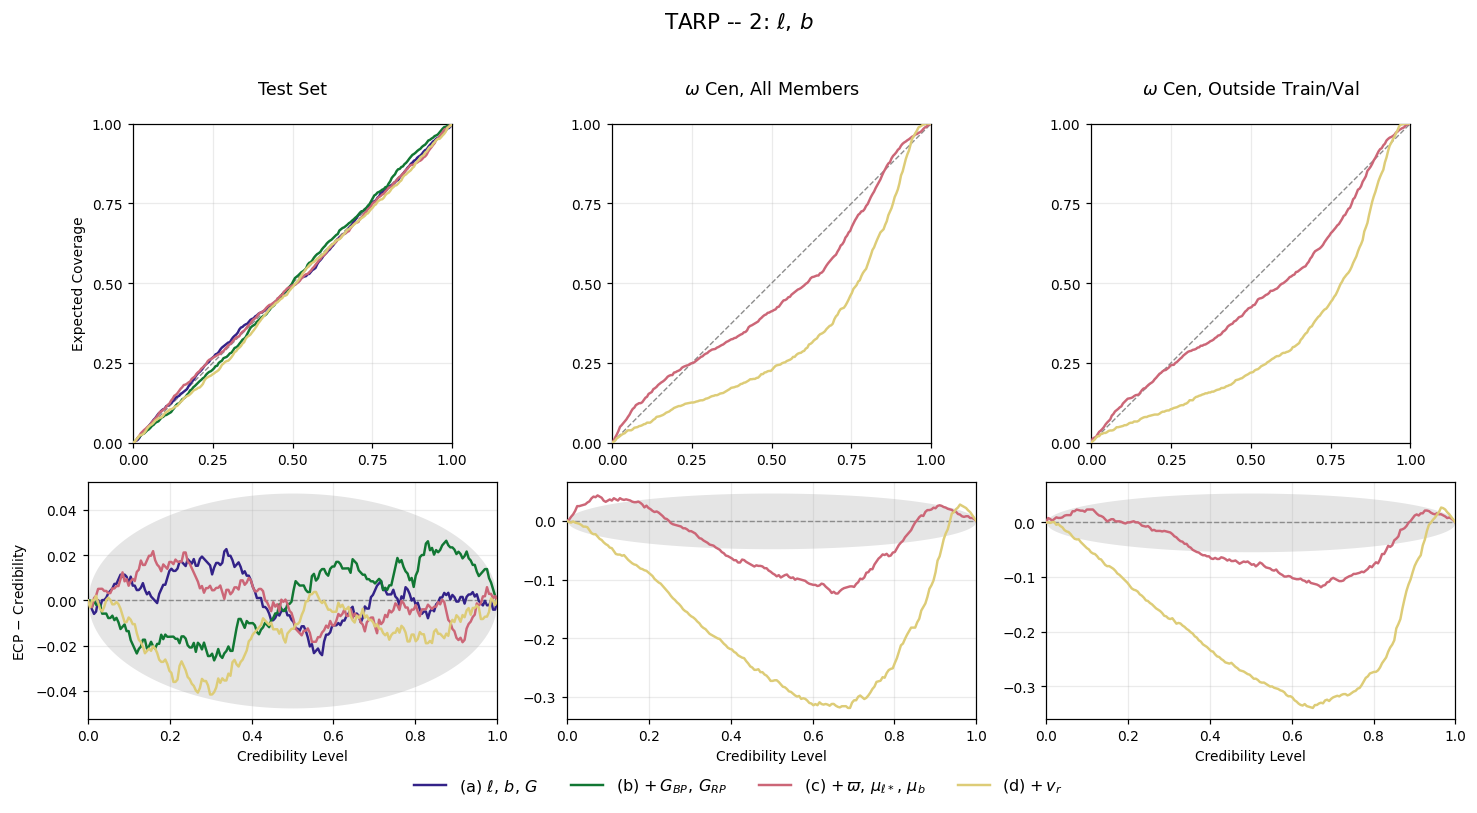

In [29]:
# =====================================================================
# FIGURE 12 -- TARP, conditioned on sky position
# =====================================================================
with plt.rc_context(TARP_RC):
    _ = plot_tarp_pattern(FIG12_PATTERN, fonts='fig12',
                          save_name=f'fig12_tarp_{FIG12_PATTERN}')

(d) $+\,v_r$

n per TARP curve -- drop_radial_velocity  (drop RV)
                  (d)
test             1000
omega_cen_all    1000
omega_cen_not_A   781
  Test Set: (d) $n = 1000$
  $\omega$ Cen, All Members: (d) $n = 1000$
  $\omega$ Cen, Outside Train/Val: (d) $n = 781$
  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig13_tarp_drop_radial_velocity.png


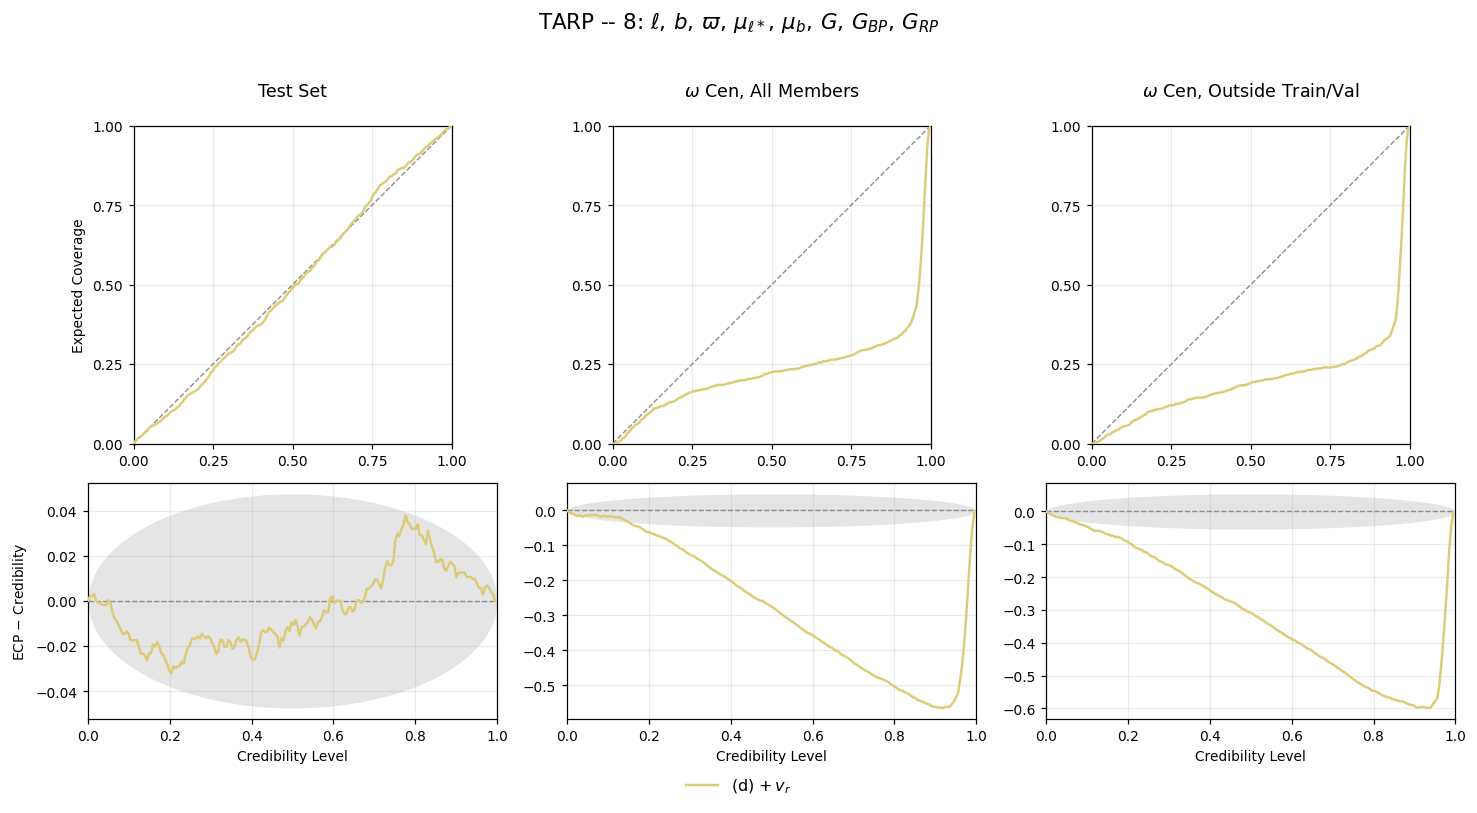

In [30]:
# =====================================================================
# FIGURE 13 -- TARP, conditioned on everything but radial velocity
# =====================================================================
with plt.rc_context(TARP_RC):
    _ = plot_tarp_pattern(FIG13_PATTERN, fonts='fig13',
                          save_name=f'fig13_tarp_{FIG13_PATTERN}')

### Figure 14

The three drop-photometry patterns side by side on the test set: how well does
the model reconstruct one band given everything else?

Each conditions on 8 of the 9 features, so only class (d) -- sources with all
nine measured -- can satisfy them; the other classes lack a conditioned feature
and are skipped. The deviation scale is shared across the three columns so they
are comparable by eye.

(d) $+\,v_r$

n per TARP curve -- drop_phot_g_mean_mag  (drop G)
                  (d)
test             1000
omega_cen_all    1000
omega_cen_not_A   781
  Test Set: (d) $n = 1000$
  $\omega$ Cen, All Members: (d) $n = 1000$
  $\omega$ Cen, Outside Train/Val: (d) $n = 781$

n per TARP curve -- drop_phot_bp_mean_mag  (drop BP)
                  (d)
test             1000
omega_cen_all    1000
omega_cen_not_A   781
  Test Set: (d) $n = 1000$
  $\omega$ Cen, All Members: (d) $n = 1000$
  $\omega$ Cen, Outside Train/Val: (d) $n = 781$

n per TARP curve -- drop_phot_rp_mean_mag  (drop RP)
                  (d)
test             1000
omega_cen_all    1000
omega_cen_not_A   781
  Test Set: (d) $n = 1000$
  $\omega$ Cen, All Members: (d) $n = 1000$
  $\omega$ Cen, Outside Train/Val: (d) $n = 781$
  wrote /Users/John/Desktop/Gaia Diffusion Model Work/paper_figs_w_classes/fig14_tarp_drop_photometry.png


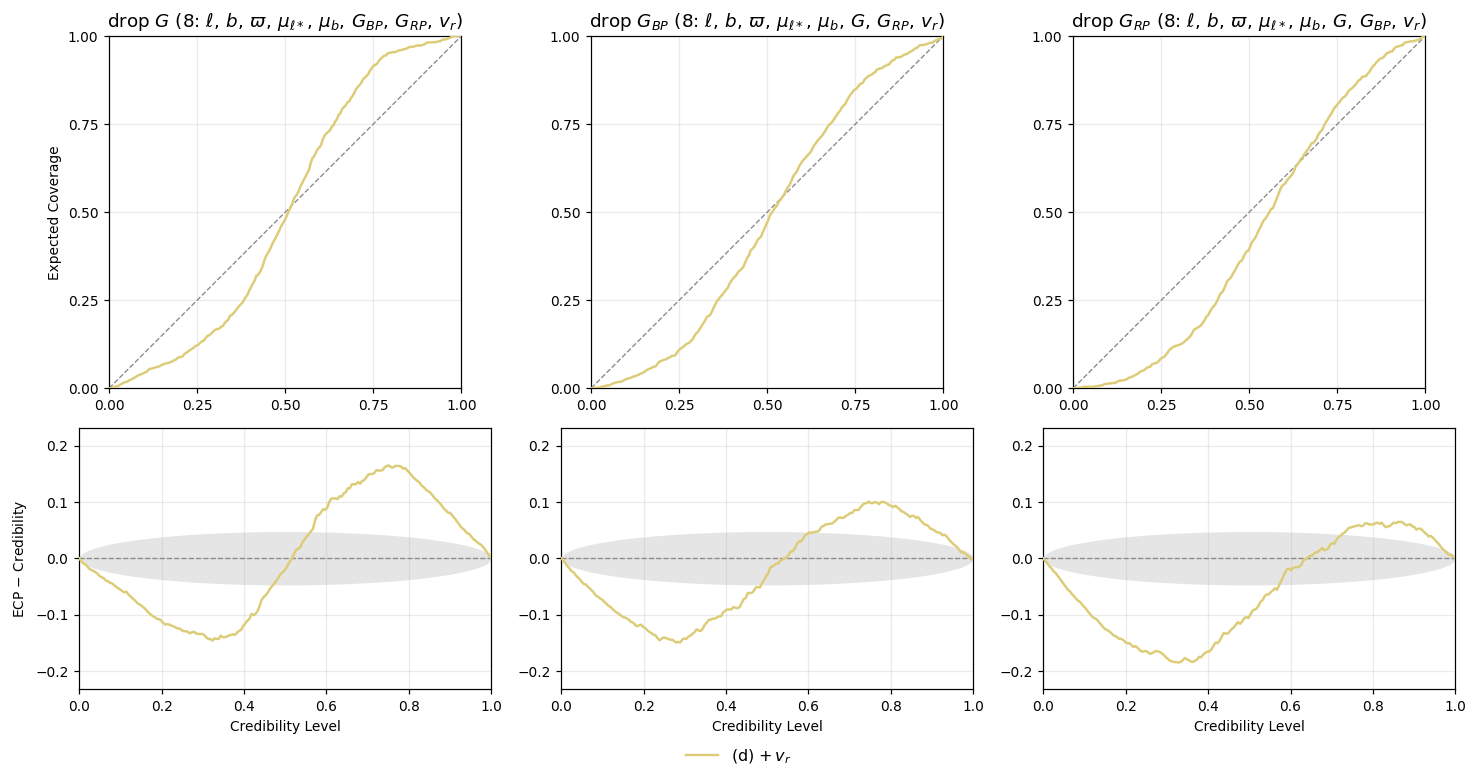

In [31]:
# =====================================================================
# FIGURE 14 -- TARP, the three drop-photometry patterns
# =====================================================================
with plt.rc_context(TARP_RC):
    _ = plot_tarp_compare(FIG14_PATTERNS, FIG14_DATASET,
                          share_dev=FIG14_SHARE_DEV, fonts='fig14',
                          save_name='fig14_tarp_drop_photometry')

In [32]:
# =====================================================================
# D3. RMSE machinery  (Figures 15, 16, 17)
# =====================================================================
# Row 1 = test set, row 2 = both omega Cen datasets.
# Columns = skill, model RMSE, baseline RMSE, all against n_cond.
RMSE_RNG = np.random.default_rng(RMSE_RNG_SEED)

ROW_DATASETS = [[d for d in DATASETS if d == 'test'],
                [d for d in DATASETS if d.startswith('omega_cen')]]
ROW_TITLE = ['test set', r'$\omega$ Cen']
COLUMNS = [('skill', r'Skill  $= 1 -$ RMSE / RMSE$_{\rm baseline}$'),
           ('rmse', 'Model RMSE'),
           ('baseline', 'Baseline RMSE  (Guess the Mean)')]


def _rmse_spread(x, y, how=None):
    """Deterministic offsets separating points that share an x. Cosmetic."""
    how = X_SPREAD if how is None else how
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if how == 'none' or x.size == 0:
        return np.zeros_like(x)
    if how == 'jitter':
        return (RMSE_RNG.random(x.size) - 0.5) * 0.18
    off = np.zeros_like(x)
    for v in np.unique(x):
        idx = np.nonzero(x == v)[0]
        if idx.size == 1:
            continue
        order = idx[np.argsort(y[idx])]
        w = min(0.74, 0.16 * idx.size)
        off[order] = np.linspace(-w / 2, w / 2, idx.size)
    return off


def _rmse_place_labels(ax, xs, ys, texts, fontsize=6.0):
    """Greedy label placement, as in Section C, with one difference: with
    40-odd patterns the candidate list runs out, and a label that cannot be
    placed is DROPPED rather than clamped to the axes edge. Clamping stacks
    every leftover label on the boundary into an unreadable smear, and the
    tables in the appendix carry the numbers anyway. Returns how many were
    dropped.

    Both sides of the reserved box scale with fontsize, so raising the
    'annotation' knob reserves proportionally more room; at the default
    6.0 the box is the one this placer has always used."""
    tf = ax.transLimits.transform
    placed, n_dropped = [], 0
    ch_w, ch_h = 0.0092 * fontsize / 6.5, 0.038 * fontsize / 6.0
    for i in np.argsort(-np.asarray(ys, dtype=float)):
        if not np.isfinite(xs[i]) or not np.isfinite(ys[i]):
            continue
        fx, fy = tf((xs[i], ys[i]))
        vis = re.sub(r'\\[a-zA-Z]+|[${}\\^_]', '', texts[i])
        w, h = ch_w * max(len(vis), 1) * 1.15, ch_h
        dys = [-h / 2]
        for k in range(1, 11):                 # grow the search both ways
            dys += [0.012 + 0.022 * (k - 1), -h - 0.012 - 0.022 * (k - 1)]
        box = None
        for dx, dy in [(sx, dy) for dy in dys for sx in (0.012, -w - 0.012)]:
            b = (fx + dx, fy + dy, fx + dx + w, fy + dy + h)
            if not (0.004 < b[0] and b[2] < 0.996
                    and 0.004 < b[1] and b[3] < 0.996):
                continue
            if not any(b[0] < p[2] and p[0] < b[2] and
                       b[1] < p[3] and p[1] < b[3] for p in placed):
                box = b
                break
        if box is None:
            n_dropped += 1
            continue
        placed.append(box)
        far = abs(box[0] - fx) > 0.05 or abs(box[1] + h / 2 - fy) > 0.05
        ax.annotate(texts[i], xy=(xs[i], ys[i]), xycoords='data',
                    xytext=(box[0], box[1] + h / 2 - 0.004),
                    textcoords='axes fraction', fontsize=fontsize,
                    va='center', ha='left', zorder=5,
                    arrowprops=dict(arrowstyle='-', lw=0.4, color='0.55',
                                    shrinkA=0, shrinkB=2) if far else None)
    return n_dropped


def _rmse_annotate(ax, xs, ys, texts, enable=True, fontsize=6.0):
    if not enable:
        return 0
    if DECLUTTER_LABELS:
        return _rmse_place_labels(ax, xs, ys, texts, fontsize=fontsize)
    for xi, yi, t in zip(xs, ys, texts):
        ax.annotate(t, (xi, yi), fontsize=fontsize, xytext=(4, 3),
                    textcoords='offset points')
    return 0


def _label_patterns(d, datasets):
    """The patterns to label, chosen ONCE per figure and used in every panel.

    Labelling each panel's own extremes would put a different set of names in
    each one, so a reader could not follow a pattern across the three columns.
    The choice is made on LABEL_BY in the first dataset that has data: the
    interesting patterns sit at the two ends, and the crowd in the middle is
    what the appendix tables are for.
    """
    if RMSE_LABEL_CLASS in set(d['cls']):          # one point per pattern
        d = d.loc[d['cls'] == RMSE_LABEL_CLASS]
    for ds in datasets:
        dd = d.loc[d['dataset'] == ds]
        if dd.empty:
            continue
        y = dd[LABEL_BY].to_numpy(float)
        pats = dd['pattern'].to_numpy()
        if MAX_LABELS is None or len(y) <= MAX_LABELS:
            return set(pats)
        order = np.argsort(y)
        half = MAX_LABELS // 2
        return set(pats[np.concatenate([order[:half],
                                        order[-(MAX_LABELS - half):]])])
    return set()


def _feature_rows(feature):
    d = RMSE.loc[(RMSE['feature'] == feature) & RMSE['rmse'].notna()]
    return d.loc[d['pattern'].isin(PATTERN_NAMES)]


def _panel(ax, d, column, datasets, annotate, label_patterns):
    """One panel: a point per pattern, per dataset, against n_cond."""
    n_ds = max(len(datasets), 1)
    first, ys_all = None, []
    for i, ds in enumerate(datasets):
        dd = d.loc[d['dataset'] == ds]
        if dd.empty:
            continue
        x = dd['n_cond'].to_numpy(float)
        y = dd[column].to_numpy(float)
        # Even spread within an n_cond, plus a fixed offset per dataset so the
        # heavily overlapping omega Cen pair stays legible. Cosmetic only.
        xs = x + _rmse_spread(x, y) + DS_OFFSET * (i - (n_ds - 1) / 2)
        cls = dd['cls'].to_numpy()
        for c in dict.fromkeys(cls):               # classes present, in order
            m = cls == c
            ax.scatter(xs[m], y[m], s=15, marker=DS_MARKER.get(ds, 'o'),
                       color=CLASS_COLOR.get(c, DS_COLOR.get(ds, f'C{i}')),
                       edgecolor='0.25', lw=0.4, zorder=3)
        ys_all.append(y)
        if first is None:
            m = (cls == RMSE_LABEL_CLASS) if RMSE_LABEL_CLASS in cls \
                else np.ones(len(cls), bool)
            first = (xs[m], y[m], dd['pattern'].to_numpy()[m])

    if column == 'skill':
        ax.axhline(0.0, color='0.4', ls='--', lw=1.1, zorder=2)
    elif LOG_RMSE:
        ax.set_yscale('log')
    ax.set_xlim(-0.6, len(FEATURES) - 0.4)
    ax.set_xticks(range(len(FEATURES)))

    # Pad the y limits BEFORE annotating: the label placer works in axes
    # fractions and rejects any box leaving the axes, so a point sitting
    # exactly on the top or bottom edge could never be labelled.
    if ys_all and not (LOG_RMSE and column != 'skill'):
        lo = min(float(y.min()) for y in ys_all)
        hi = max(float(y.max()) for y in ys_all)
        pad = 0.12 * ((hi - lo) or abs(hi) or 1.0)
        if column == 'skill':
            ax.set_ylim(min(lo - pad, -pad / 2), max(hi + pad, pad / 2))
        else:
            ax.set_ylim(lo - pad, hi + pad)

    if annotate and first is not None:
        xs, y, pats = first                    # label one dataset only
        keep = np.flatnonzero([p in label_patterns for p in pats])
        _rmse_annotate(ax, xs[keep], y[keep],
                       [short_pattern(p) for p in pats[keep]],
                       **fkw('annotation'))

from matplotlib.lines import Line2D


def _rmse_legend(ax, d, datasets):
    """Colour = class, marker = dataset (only when a row has two datasets)."""
    present = [c for c in CLASSES if c in set(d['cls'])]
    h = [Line2D([], [], ls='', marker='o', ms=5, mfc=CLASS_COLOR[c],
                mec='0.25', mew=0.4, label=CLASS_LABEL[c]) for c in present]
    if len(datasets) > 1 or not present:
        h += [Line2D([], [], ls='', marker=DS_MARKER.get(ds, 'o'), ms=5,
                     mfc='white' if present else DS_COLOR.get(ds),
                     mec='0.25', mew=0.6, label=DS_LABEL.get(ds, ds))
              for ds in datasets]
    ax.legend(handles=h, loc='best', **fkw('legend'))
    
@with_fonts('fig15')         # Figures 16 and 17 pass their own key
def plot_rmse_feature(feature, annotate=None, save_name=None):
    """2 x 3 grid for one feature: skill, RMSE, baseline; test over omega Cen."""
    feature = canon(feature)
    d_all = _feature_rows(feature)
    if d_all.empty:
        raise RuntimeError(f'{feature}: predicted by no pattern in any dataset')
    annotate = ANNOTATE if annotate is None else annotate

    fig, axes = plt.subplots(2, 3, figsize=RMSE_FIGSIZE, squeeze=False)
    for r, datasets in enumerate(ROW_DATASETS):
        d = d_all.loc[d_all['dataset'].isin(datasets)]
        label_patterns = _label_patterns(d, datasets)
        for c, (column, ylabel) in enumerate(COLUMNS):
            ax = axes[r][c]
            if c == 0:
                # Row identity as a left-aligned title: a rotated label outside
                # the axes collides with the y-axis label at this figure size.
                q=0
                #ax.set_title(ROW_TITLE[r], loc='left', fontsize=11)
            if d.empty:
                ax.text(0.5, 0.5, f'no {ROW_TITLE[r]} results',
                        transform=ax.transAxes, ha='center', va='center',
                        color='0.45', **fkw('note'))
                continue
            _panel(ax, d, column, datasets,
                   annotate and column in ANNOTATE_COLUMNS, label_patterns)
            u = unit(feature)
            ax.set_ylabel(ylabel if c == 0 else
                          (f'{ylabel}  [{u}]' if u else ylabel),
                          **fkw('axis_label'))
            if r == 1:
                ax.set_xlabel('Number of Conditioning Features',
                              **fkw('axis_label'))
            if c == 0:
                _rmse_legend(ax, d, datasets)

    u = f'  [{unit(feature)}]' if unit(feature) else ''
    space = ' (normalized)' if feature in ('cos_l', 'sin_l') else ''
    fig.suptitle(f'{tex(feature, unit=False)}{u}{space}: '
                 f'Skill and RMSE vs Conditioning Pattern',
                 y=1.0, **fkw('suptitle'))
    fig.tight_layout(rect=(0, 0, 1, 0.975))

    if save_name:
        save_fig(fig, save_name)
    else:
        plt.show()
    return fig

---

## Notes

* **Symbols.** Everything reads from `SYMBOL` in the shared-conventions cell.
  Changing `SYMBOL['pml']` there changes it in Figures 6, 7, 8, 9, 10, 15, 16
  and 17 at once. The source notebooks disagreed about this ($\mu_{\ell*}$ in
  two of them, $\mu_{l*}$ in three); they now cannot.

* **Section independence.** A and B share the model metadata, the pattern list
  and `load_dataset`, so B needs A's cells A1-A3. C and D are self-contained
  and build their own feature index from their own metadata (`IMP_FEATURES`
  from the manifest, `FEATURES` from the HDF5).

* **Pattern indices.** Sections A and B address conditioning patterns by the
  features they condition on, never by a bare integer. `pattern_index` and
  `drop_one_index` raise rather than returning `None`, so a typo fails loudly
  instead of silently drawing the wrong panel. If `MASK_SETS` is set on the
  model, the drop-one block groups masked features together and the indices
  shift -- `PERMUTATION_BUILDER` selects which construction to use and the
  pattern list is printed when it is built, so it can be checked against the
  sampling run.

* **Two different all-sky runs.** Figures 2-5 use `ALLSKY_TIMESTAMP`; the field
  in Figures 6-7 uses `FIELD_TIMESTAMP`. They were different runs in the draft,
  and the config keeps them separate. Set them equal if that is what you want.

* **Unconditional draws are not row-aligned.** They are i.i.d. from $p(x)$ with
  an all-zero input mask, so they carry no source identity. Figure 2 pairs them
  with true rows by index deliberately -- it is comparing distributions, not
  sources -- and `load_dataset` asserts the counts match for that reason. A
  per-source error against an unconditional draw is undefined, which is why the
  unconditional residual panel in Figures 3 and 4 measures the width of the
  distribution rather than an error.

* **Font sizes.** `FONT_SIZES` in the configuration cell holds one table
  per figure for Figures 3, 4, 8, 10 and 11-17, with an independent knob for
  axis labels, tick labels, panel titles, the figure title, legends,
  annotations, in-axes notes and the two colorbar components. `None` means
  inherit, so the table as shipped reproduces the sizes those figures were
  already drawn at. `@with_fonts` opens the table around each figure function
  and gives it a `fonts=` keyword, which is how `plot_tarp_pattern` draws
  Figures 11, 12 and 13 at three independent sets of sizes. Figures 2, 5, 6,
  7 and 9 never enter a font context and are unaffected.

* **Grids.** Section D draws on a grid, Sections A-C do not. That is handled by
  `plt.rc_context(TARP_RC)` around each Section D figure rather than a global
  `rcParams.update`, so running the notebook out of order cannot leak a grid
  into Figure 2.